<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chapter 5: Decision Trees

# Task
Chapter 5 : Decision Trees
topics
1. Decision Tree
2. Tree Terminology
3. Entropy
4. Information Gain
5. Gini Impurity
6. ID3
7. CART
8. Regression Tree
9. Pruning
10. Hyperparameters
11. Python (Titanic)


## 1. Decision Tree

### 1. Definition
A Decision Tree is a supervised machine learning algorithm that can be used for both classification and regression tasks. It models decisions in a tree-like structure, where each internal node represents a 'test' on an attribute (e.g., whether a coin flip is heads or tails), each branch represents the outcome of the test, and each leaf node represents a class label (for classification) or a numerical value (for regression).

Essentially, it breaks down a dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed. The final result is a tree with decision nodes and leaf nodes.

### 2. Why do we need it?
Decision Trees are powerful and popular for several reasons:

*   **Interpretability:** They are easy to understand and visualize, making them highly interpretable compared to 'black box' models like neural networks.
*   **Handling Mixed Data:** They can handle both numerical and categorical data without extensive pre-processing like scaling or normalization.
*   **Non-linearity:** They can capture non-linear relationships between features and target variables.
*   **Feature Selection:** The construction process implicitly performs feature selection by prioritizing the most informative features at higher nodes in the tree.
*   **Foundation for Ensembles:** They serve as the base learners for highly effective ensemble methods like Random Forests and Gradient Boosting.

### 3. Intuition
Imagine you want to decide whether to play tennis. You might consider factors like the weather, temperature, humidity, and wind. A decision tree mimics this human decision-making process.

It starts with a root node (the primary decision point, e.g., 'Outlook'). Based on the outcome (e.g., 'Sunny', 'Overcast', 'Rain'), you move down a branch. Each branch leads to another decision node (e.g., 'Humidity') or a leaf node, which gives you the final decision (e.g., 'Play Tennis' or 'Don't Play Tennis').

The core idea is to find the 'best' question (feature) at each step that most effectively splits the data into purer subsets, meaning subsets where most samples belong to the same class.

### 4. Mathematical Foundation
The mathematical foundation of Decision Trees lies in information theory and impurity measures. The goal is to recursively partition the data based on features such that each partition (node) becomes as 'pure' as possible with respect to the target variable.

Two primary metrics are used to measure impurity and guide the splitting process:

1.  **Entropy:** A measure of disorder or unpredictability. A perfectly pure node (all samples belong to the same class) has zero entropy. A node with an equal mix of classes has maximum entropy.
2.  **Gini Impurity:** Measures how often a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset. Like entropy, zero Gini impurity means a pure node.

These measures are used to calculate **Information Gain** (for entropy) or **Gini Gain** (for Gini impurity), which quantify how much the impurity decreases after a split. The algorithm selects the feature and split point that maximize this gain.

### 5. Formula
Let's briefly introduce the formulas for Entropy and Gini Impurity, which are central to Decision Tree construction.

**Entropy (H)** for a dataset $S$ with $C$ classes:

$H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)$

Where $p_i$ is the proportion of samples belonging to class $i$ in the set $S$.

**Information Gain (IG)** for a split on attribute $A$:

$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$

Where $Values(A)$ are the possible values for attribute $A$, $S_v$ is the subset of $S$ for which attribute $A$ has value $v$, and $|S|$ is the number of samples in set $S$.

**Gini Impurity (G)** for a dataset $S$ with $C$ classes:

$G(S) = 1 - \sum_{i=1}^{C} p_i^2$

Where $p_i$ is the proportion of samples belonging to class $i$ in the set $S$.

**Gini Gain (or decrease in Gini impurity)** for a split on attribute $A$:

$GiniGain(S, A) = G(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} G(S_v)$

The algorithm greedily chooses the split that results in the highest Information Gain or Gini Gain.

### 6. Numerical Example (Conceptual)
Let's consider a very simple example to illustrate the concept of splitting. Suppose we have a dataset with 10 samples, and we want to predict if a customer will buy a product (Yes/No) based on their Age (Young/Middle/Old).

**Initial State (Root Node):**
Total Samples = 10
Buys Product = 5 (Yes)
Doesn't Buy Product = 5 (No)

Let's assume we are using Gini Impurity.
Initial Gini = $1 - (0.5^2 + 0.5^2) = 1 - (0.25 + 0.25) = 1 - 0.5 = 0.5$

**Consider a Split by Age:**

*   **Age = Young (4 samples):** 4 Yes, 0 No
    Gini(Young) = $1 - (1^2 + 0^2) = 0$ (Perfectly pure)

*   **Age = Middle (3 samples):** 1 Yes, 2 No
    Gini(Middle) = $1 - ((1/3)^2 + (2/3)^2) = 1 - (1/9 + 4/9) = 1 - 5/9 = 4/9 \approx 0.444$

*   **Age = Old (3 samples):** 0 Yes, 3 No
    Gini(Old) = $1 - (0^2 + 1^2) = 0$ (Perfectly pure)

**Weighted Average Gini after split:**
$(4/10) * 0 + (3/10) * (4/9) + (3/10) * 0 = 0 + 12/90 + 0 = 2/15 \approx 0.133$

**Gini Gain = Initial Gini - Weighted Average Gini**
$0.5 - 0.133 = 0.367$

This positive Gini Gain indicates that splitting by 'Age' improves the purity of our nodes, making it a good candidate for the first split. The algorithm would then recursively apply this process to the 'Middle' node (since 'Young' and 'Old' are pure). This example simplifies the process, as in reality, the algorithm would evaluate all possible features and split points.

### 7. Working (Step-by-Step)
Here's a step-by-step breakdown of how a Decision Tree is typically constructed:

1.  **Start at the Root Node:** The entire dataset is considered the root node.

2.  **Calculate Impurity:** Calculate the impurity (e.g., Gini Impurity or Entropy) of the current node.

3.  **Find the Best Split:**
    *   For each feature in the dataset:
        *   For each possible split point within that feature (e.g., unique values for categorical, midpoints for numerical):
            *   Divide the dataset into two (or more) subsets based on the split point.
            *   Calculate the impurity of each child node.
            *   Calculate the Information Gain or Gini Gain for this split.
    *   Select the feature and split point that yields the highest Information Gain (or Gini Gain).

4.  **Create Child Nodes:** Split the current node into child nodes based on the best split found.

5.  **Recursion:** Repeat steps 2-4 for each child node. This recursive process continues until one of the stopping conditions is met:
    *   The node becomes pure (all samples belong to the same class).
    *   A pre-defined maximum depth for the tree is reached (`max_depth`).
    *   The number of samples in a node falls below a minimum threshold (`min_samples_split`, `min_samples_leaf`).
    *   The impurity gain from further splitting falls below a minimum threshold (`min_impurity_decrease`).

6.  **Assign Class Labels:** Once the tree building stops, the leaf nodes are assigned a class label (for classification, the majority class of the samples in that leaf) or a numerical value (for regression, the average value of the samples in that leaf).

### 8. Visualization
Visualizing a Decision Tree is one of its strongest advantages. A typical decision tree plot shows:

*   **Nodes:** Represent decisions or leaf outcomes.
*   **Branches:** Represent the paths taken based on the decision outcome.
*   **Internal Nodes:** Contain the feature and split condition (e.g., `Age <= 30`). They might also show the impurity (Gini/Entropy), the number of samples at that node, and the distribution of classes.
*   **Leaf Nodes:** Terminal nodes that provide the final prediction. They show the predicted class/value, the number of samples, and the class distribution.

Conceptually, it looks like an inverted tree structure, with the root at the top and leaves at the bottom.

```text
                         [Outlook]
                              │
          ┌───────────────────┼────────────────────┐
          │                   │                    │
      Sunny              Overcast               Rain
          │                   │                    │
          ▼                   ▼                    ▼
  Humidity ≤ 75?         Play Tennis      Wind = Strong?
      /      \                                 /      \
    Yes      No                             Yes        No
     │        │                              │          │
     ▼        ▼                              ▼          ▼
 Play      Don't Play                  Don't Play    Play
 Tennis      Tennis                      Tennis      Tennis
```
*(This is a conceptual diagram using Mermaid syntax, actual Python libraries like `graphviz` or `plot_tree` from `sklearn` are used for plotting decision trees.)*

### 9. Hyperparameters
Decision trees have several important hyperparameters that control their complexity and prevent overfitting:

*   **`criterion`**: The function to measure the quality of a split. Common choices are 'gini' for Gini impurity and 'entropy' for Information Gain.
*   **`max_depth`**: The maximum depth of the tree. Limiting the depth helps prevent overfitting by simplifying the model.
*   **`min_samples_split`**: The minimum number of samples required to split an internal node. If a node has fewer samples than this, it will not be split further.
*   **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node. Any split that would result in a leaf with fewer samples than this will be disallowed.
*   **`max_features`**: The number of features to consider when looking for the best split. This is particularly useful in ensemble methods like Random Forests.
*   **`random_state`**: Controls the randomness of the estimator. Important for reproducibility.
*   **`splitter`**: The strategy used to choose the split at each node. 'best' for the best split, 'random' for the best random split.

### 10. Advantages
*   **Simple to Understand and Interpret:** The model structure can be visualized and understood by humans, making it valuable for explaining predictions.
*   **Handles Numerical and Categorical Data:** No need for extensive data preprocessing like one-hot encoding or scaling for all features.
*   **Handles Multiclass Problems:** Can naturally extend to problems with more than two target classes.
*   **Implicit Feature Selection:** Features that are important for classification will appear closer to the root of the tree.
*   **No Linear Assumption:** Can model non-linear relationships, unlike linear models.
*   **Foundation for Ensembles:** They are the building blocks for more powerful algorithms like Random Forests and Gradient Boosting Machines.

### 11. Limitations
*   **Prone to Overfitting:** Without proper pruning or setting hyperparameters (`max_depth`, `min_samples_leaf`), decision trees can easily overfit the training data, leading to poor generalization on unseen data.
*   **Instability:** Small variations in the data can lead to a completely different tree structure. This can be mitigated using ensemble methods.
*   **Bias towards Dominant Classes:** If there's an imbalance in the dataset, the tree might be biased towards the majority class.
*   **Computational Complexity:** Building optimal decision trees is an NP-hard problem. Heuristic algorithms are used, which do not guarantee globally optimal trees.
*   **Greedy Approach:** The algorithm makes locally optimal decisions at each split, which may not always lead to a globally optimal tree.
*   **Difficulty with Continuous Variables:** For continuous features, many split points might need to be evaluated, increasing computational cost and potentially leading to overfitting if not handled well.

### 12. Time Complexity
*   **Training:** For a dataset with $N$ samples and $M$ features, the time complexity to build a single decision tree is approximately $O(M \cdot N \cdot \log N)$. In the worst case, for continuous features, finding the best split point can involve sorting, which adds complexity. If pre-sorting is enabled (e.g., `presort=True` in older scikit-learn versions, now often handled efficiently), it's closer to $O(M \cdot N \log N)$.
*   **Prediction:** Once the tree is built, predicting the class for a new sample involves traversing the tree from the root to a leaf node. The time complexity for prediction is $O(\text{depth of tree})$, which is often logarithmic, $O(\log N)$ in a balanced tree, or $O(N)$ in the worst case (a degenerate tree).

However, in practice, due to optimizations and specific hyperparameters (`max_features`, `max_depth`), the complexity is often lower and manageable for many datasets.

### 13. Python Implementation (Brief Overview)

In Python, the `scikit-learn` library provides excellent implementations of Decision Trees for both classification (`DecisionTreeClassifier`) and regression (`DecisionTreeRegressor`).


We will delve into a full end-to-end implementation using the Titanic dataset in a later section.

Accuracy: 0.7933


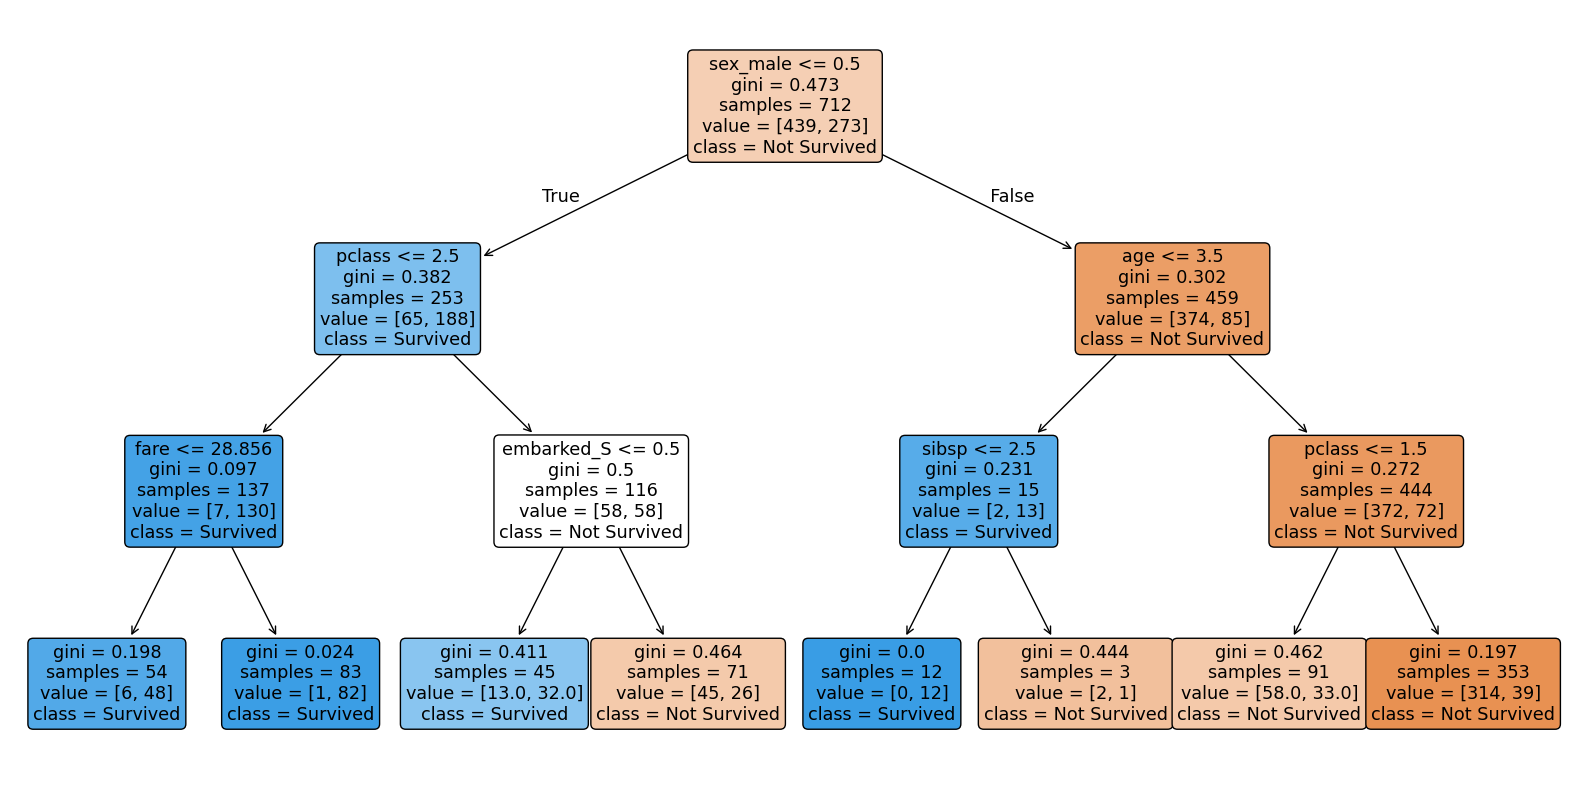

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming X_train, X_test, y_train, y_test are already defined
# (We will use the Titanic dataset for a full example later)

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# We can also visualize the tree (requires graphviz)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(dtc, filled=True, feature_names=X_train.columns, class_names=['Not Survived', 'Survived'], rounded=True)
plt.show()

### 14. Questions
*   What is the primary difference between a Decision Tree for classification and one for regression?
*   How does setting `max_depth` help in preventing overfitting?
*   Can Decision Trees handle missing values automatically, or is preprocessing required?
*   Why are Decision Trees considered 'white box' models?

### 15. Summary
Decision Trees are versatile, interpretable, non-parametric supervised learning algorithms used for both classification and regression. They operate by recursively partitioning data based on feature values to create a tree-like model of decisions. Key concepts include impurity measures (Entropy, Gini Impurity) and gain metrics (Information Gain, Gini Gain) to guide optimal splitting. While prone to overfitting, their simplicity, handling of mixed data types, and role as foundational elements for ensemble methods make them a valuable tool in machine learning.

### 16. Comparison with Previous Algorithms
*(Note: As no previous algorithms were explicitly covered before Decision Trees in this context, this section will discuss general comparisons assuming typical ML course progression.)*

Compared to simpler models like **Linear Regression** or **Logistic Regression**, Decision Trees offer:

*   **Non-linearity:** Decision Trees can capture complex non-linear relationships in data, whereas linear models are restricted to linear boundaries.
*   **No Feature Scaling Needed:** Linear models often require feature scaling (e.g., standardization) for optimal performance, while Decision Trees are invariant to the scale of features.
*   **Interpretability:** Both are relatively interpretable, but Decision Trees provide a visual flow of decisions, which can be more intuitive for non-technical audiences.

Compared to **K-Nearest Neighbors (KNN)**:

*   **Training Time:** Decision Trees have a training phase to build the tree, whereas KNN is a lazy learner with no explicit training phase (all computation happens during prediction).
*   **Prediction Time:** For a large dataset, prediction with a well-pruned Decision Tree can be faster than KNN, which needs to calculate distances to all training samples.
*   **Interpretability:** Decision Trees are much more interpretable than KNN.
*   **Dimensionality:** Decision Trees are less affected by high dimensionality than KNN, as they implicitly perform feature selection.

Decision Trees serve as a bridge, offering more complexity than basic linear models while maintaining a level of interpretability often lost in more advanced 'black box' models.

## 2. Tree Terminology

### 1. Definition
Tree Terminology refers to the specific vocabulary used to describe the components, structure, and relationships within a decision tree. Understanding these terms is fundamental to comprehending how decision trees work, how they are constructed, and how to interpret their output.

### 2. Why do we need it?
Precisely defined terminology allows for clear and unambiguous communication about decision trees. It helps in:

*   **Understanding Algorithms:** When learning about ID3, C4.5, or CART algorithms, these terms are frequently used.
*   **Interpreting Models:** When a decision tree is visualized, knowing the terminology helps in understanding what each part represents.
*   **Hyperparameter Tuning:** Many hyperparameters directly refer to tree components (e.g., `max_depth`, `min_samples_leaf`).
*   **Troubleshooting and Debugging:** Identifying issues like overfitting often relies on understanding the tree's structure (e.g., deep trees with many nodes).

### 3. Intuition
Think of a family tree or a real tree. A family tree has a root (ancestor), branches (lineage), parents, children, and leaves (individuals). Similarly, a decision tree has a starting point, splits, connections, and end points. The intuition is to map these natural tree concepts to the components of a decision-making model.

### 4. Mathematical Foundation
While tree terminology itself isn't directly mathematical, the concepts it describes are built upon mathematical foundations (e.g., 'node' is where impurity is calculated, 'split' is determined by optimizing information gain, 'depth' relates to the number of decisions). The terms provide labels for the elements that are mathematically defined and processed during tree construction.

### 5. Key Terms and Definitions (Formula is not directly applicable here as this is definition-based)

Here are the most common terms:

*   **Root Node:** The topmost node in a decision tree. It represents the entire dataset and is the starting point for the decision-making process. There are no incoming branches to the root node.

*   **Internal Node (Decision Node):** A node that has child nodes. It represents a test on an attribute (feature) and has branches corresponding to the possible outcomes of that test. These are the nodes where decisions are made to split the data further.

*   **Leaf Node (Terminal Node):** A node that does not have any child nodes. It represents the final outcome or class label (for classification) or a predicted value (for regression). All decision paths end in a leaf node.

*   **Branch (Edge):** A connection between two nodes. Each branch represents the outcome of the test performed at the parent node.

*   **Splitting:** The process of dividing a node into two or more sub-nodes based on a chosen attribute and split-point (or condition).

*   **Parent Node:** A node that is split into child nodes.

*   **Child Node:** A node that results from the splitting of a parent node.

*   **Subtree:** A portion of the decision tree that can be considered a tree by itself, originating from a specific node and including all its descendants.

*   **Pruning:** The process of removing subtrees from a decision tree that are less relevant or are likely to lead to overfitting. It simplifies the tree and improves its generalization ability.

*   **Depth of a Tree:** The longest path from the root node to a leaf node. It represents the maximum number of decisions or tests performed to reach a final outcome.

*   **Impurity:** A measure of the homogeneity of the target variable within a node. Common measures include Gini Impurity and Entropy. A pure node contains samples predominantly belonging to a single class.

*   **Information Gain:** The reduction in entropy (or impurity) achieved by splitting a node based on a particular attribute. The algorithm typically chooses splits that maximize information gain.

*   **Gini Impurity (or Gini Index):** A measure of the likelihood of an incorrect classification of a new instance of a random variable if that instance were randomly classified according to the distribution of class labels in the dataset.

*   **Decision Rule:** A set of conditions (paths from the root to a leaf) that leads to a specific prediction. Each path in the tree represents a decision rule.

### 6. Numerical Example (Not directly applicable to terminology, but how terms relate to a numerical example)

Consider the example of predicting whether to play tennis based on 'Outlook', 'Temperature', 'Humidity', and 'Wind'.

*   **Root Node:** The initial question about 'Outlook'. It contains all training samples.
*   **Internal Nodes:** If 'Outlook' is 'Sunny', the next test might be 'Humidity'. 'Humidity' becomes an internal node.
*   **Branches:** The paths 'Outlook = Sunny', 'Outlook = Overcast', 'Outlook = Rain' are branches from the root node.
*   **Leaf Node:** If 'Outlook' is 'Overcast', the decision might immediately be 'Play Tennis'. 'Play Tennis' would be a leaf node.
*   **Splitting:** The process of dividing the data based on 'Outlook' is a split.
*   **Parent/Child:** The 'Outlook' node is the parent of the 'Sunny', 'Overcast', 'Rain' nodes (which would be children).
*   **Depth:** If it takes 3 decisions (e.g., Outlook -> Humidity -> Wind) to reach a 'Don't Play' decision, that path has a depth of 3.
*   **Impurity:** The 'Outlook' root node would have a certain impurity (mix of 'Play' and 'Don't Play' samples). A leaf node like 'Play Tennis' (after 'Outlook = Overcast') would have zero impurity.
*   **Decision Rule Example:** "IF Outlook = Sunny AND Humidity > 75 THEN Don't Play Tennis" is a decision rule.

### 7. Working (Step-by-Step - how terminology is used in the process)
When a decision tree algorithm works step-by-step:

1.  It begins with the **Root Node** containing the entire dataset.
2.  It performs **Splitting** at the root, evaluating different **features** to find the one that maximizes **Information Gain** (or minimizes **Impurity**).
3.  This creates **Child Nodes** from the **Parent Node** (the root).
4.  The process recursively continues at each **Internal Node**, performing further **Splits**.
5.  This continues until a **Leaf Node** is formed (either due to purity or stopping criteria like **max_depth** or **min_samples_leaf**).
6.  The collection of all nodes and **branches** forms the complete **tree**, with a certain **depth**.

### 8. Visualization
Visualizations of decision trees directly map to the defined terms. The Python code in the previous cell generated an example decision tree plot, which we can use to illustrate the terminology.

Looking at the generated plot above (`Decision Tree Visualization - Terminology Example`):

## Anatomy of a Decision Tree

```text
                                    Root Node
                                      Node #0
                          Outlook_Sunny <= 0.5 ?
                         (samples=10, entropy=0.971)
                                       │
                    ┌──────────────────┴──────────────────┐
                 True                                   False
                  │                                        │
                  ▼                                        ▼
            Node #1                                 Node #6
       Wind_Weak <= 0.5 ?                  Humidity_Normal <= 0.5 ?
            │                                        │
        ┌───┴───┐                              ┌─────┴─────┐
      True     False                        True         False
       │         │                            │             │
       ▼         ▼                            ▼             ▼
    Node #2    Node #5                    Node #7       Play Tennis
Outlook_Rain?   (Leaf)                     (Leaf)         (Leaf)
       │      Play Tennis               Don't Play
   ┌───┴───┐
 True     False
  │          │
  ▼          ▼
Node #3    Node #4
 (Leaf)     (Leaf)
Play      Don't Play
Tennis      Tennis
```

### Components of the Tree

**1. Root Node**
- The top-most node (`Node #0`).
- Contains all training samples.
- Represents the first and most important split.
- Example:
  - **Node #0**
  - Test: `Outlook_Sunny <= 0.5`
  - Samples = 10
  - Entropy = 0.971

---

**2. Internal (Decision) Nodes**
- Nodes that split further into child nodes.
- They perform feature-based decision tests.
- Examples:
  - **Node #1** → `Wind_Weak <= 0.5`
  - **Node #2** → `Outlook_Rain <= 0.5`
  - **Node #6** → `Humidity_Normal <= 0.5`

---

**3. Leaf (Terminal) Nodes**
- Final nodes with no further splits.
- Represent the model's prediction.
- Examples:
  - Node #3
  - Node #4
  - Node #5
  - Node #7

Characteristics:
- No outgoing branches
- Usually have **Entropy = 0**
- Contain the final predicted class

---

**4. Branches (Edges)**

Branches connect parent nodes to child nodes.

Example:

```text
             Outlook_Sunny <= 0.5
                    │
            ┌───────┴────────┐
          True             False
            │                 │
         Node #1          Node #6
```

Each branch corresponds to the outcome (**True** or **False**) of the decision test.

---

**5. Splitting**

A split occurs whenever one node is divided into child nodes based on a feature.

Example:

```text
             Node #0
       Outlook_Sunny <= 0.5
              │
      ┌───────┴────────┐
   Node #1          Node #6
```

Here, the dataset is divided into two smaller subsets.

---

**6. Parent and Child Nodes**

```text
          Parent
         Node #0
            │
     ┌──────┴──────┐
     │             │
 Child         Child
Node #1      Node #6
```

- Node #0 is the **parent**
- Node #1 and Node #6 are its **children**

---

**7. Tree Depth**

Depth measures how far a node is from the root.

```text
Depth 0          Node #0
                   │
Depth 1         Node #1
                   │
Depth 2         Node #2
                   │
Depth 3         Node #3
```

The deepest leaf determines the maximum depth of the tree.

---

**8. Impurity (Entropy)**

Notice how entropy decreases as we move downward.

```text
Root
Entropy = 0.971
      │
      ▼
Entropy = 0.61
      │
      ▼
Entropy = 0.32
      │
      ▼
Entropy = 0.00
```

Lower entropy means the node becomes purer, containing mostly one class.

---

**9. Example Decision Rule**

One rule extracted from the tree is:

```text
IF Outlook is NOT Sunny
        ↓
AND Wind is Weak
        ↓
AND Outlook is Rain
        ↓
THEN Predict = Play Tennis
```

Another rule:

```text
IF Outlook is Sunny
        ↓
THEN Predict = Play Tennis
```

A decision tree is simply a collection of such IF–THEN rules learned automatically from the training data.

### 9. Hyperparameters (Relation to Terminology)
Many hyperparameters directly control the tree's structure and thus relate to these terms:

*   `max_depth`: Directly limits the **depth of a tree**.
*   `min_samples_split`: Controls the minimum number of samples a **node** must have to be considered for **splitting** (i.e., to become an **internal node**).
*   `min_samples_leaf`: Sets the minimum number of samples required to be present at a **leaf node**.
*   `ccp_alpha` (for cost-complexity pruning): Relates to **pruning** by controlling the complexity parameter used to select the optimal **subtree**.
*   `criterion`: Specifies the **impurity** measure (e.g., Gini or Entropy) used at each **node** during **splitting**.

### 10. Advantages
Clear terminology simplifies the learning and application of decision trees, leading to:
*   **Improved Communication:** Facilitates discussion and collaboration among data scientists and stakeholders.
*   **Enhanced Interpretability:** Makes it easier to explain how a model works to non-technical audiences.
*   **Better Model Design:** Helps in consciously designing and tuning tree structures using hyperparameters.
*   **Easier Debugging:** Pinpointing issues like overfitting or underfitting becomes more straightforward when specific components can be identified and discussed.

### 11. Limitations
The terminology itself doesn't have limitations, but misunderstanding or misusing it can lead to:
*   **Confusion:** Incorrect use of terms can lead to misinterpretations of model behavior.
*   **Ineffective Hyperparameter Tuning:** Without understanding what `max_depth` or `min_samples_leaf` refer to, tuning becomes guesswork.
*   **Poor Explanations:** Inability to effectively communicate model logic to others.

### 12. Time Complexity
Understanding terminology doesn't have a direct time complexity, but the operations defined by the terms (e.g., 'splitting' a node) contribute to the overall time complexity of building and using the decision tree, as discussed in the previous section.

### 13. Python Implementation (Example demonstrating terms)
While there's no direct Python code for 'terminology', we can use comments within a code example to highlight these terms.



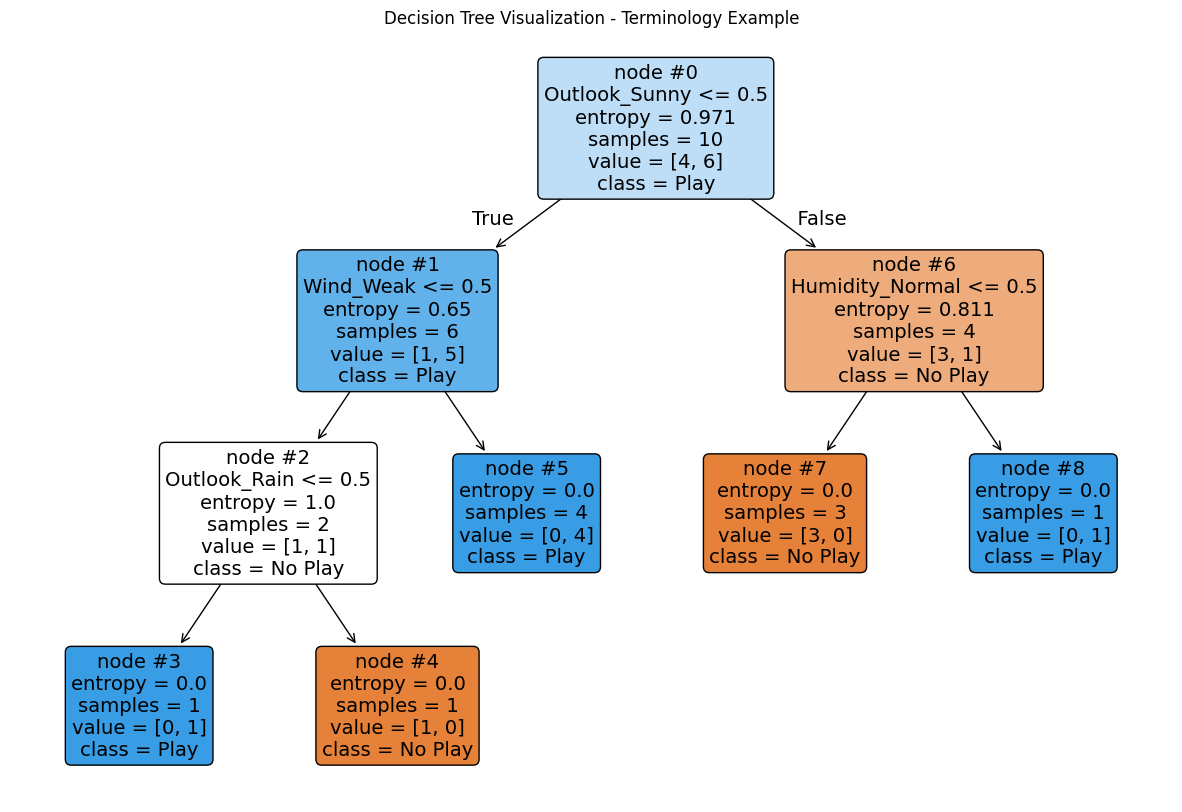

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

# Sample data (simplified for demonstration)
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)

# Convert categorical features to numerical (one-hot encoding)
df_encoded = pd.get_dummies(df[['Outlook', 'Humidity', 'Wind']], drop_first=True)
X = df_encoded
y = df['PlayTennis'].apply(lambda x: 1 if x == 'Yes' else 0) # Target variable

# Initialize a Decision Tree Classifier (Hyperparameters like max_depth control tree structure)
# The 'criterion' (gini or entropy) measures impurity at nodes
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

# Train the model (builds the tree)
dtc.fit(X, y)

# Plot the decision tree to visualize its components
plt.figure(figsize=(15, 10))
plot_tree(dtc,
          feature_names=X.columns.tolist(),
          class_names=['No Play', 'Play'],
          filled=True,
          rounded=True,
          impurity=True, # Shows impurity at each node
          node_ids=True # Shows node IDs, useful for tracing paths
         )
plt.title("Decision Tree Visualization - Terminology Example")
plt.show()

# Interpretation of the plot:
# - The top node is the 'Root Node'.
# - Nodes with conditions (e.g., 'Outlook_Sunny <= 0.5') are 'Internal (Decision) Nodes'.
# - Nodes without conditions, showing only 'class' and 'samples', are 'Leaf Nodes'.
# - The lines connecting nodes are 'Branches'.
# - The 'depth' of the tree is max 3 as specified by max_depth.
# - 'samples' count shows the number of instances at each node.
# - 'value' shows the distribution of classes at that node.
# - 'entropy' (or 'gini' if criterion='gini') shows the impurity of the node.

### 14. Questions
*   What is the difference between an Internal Node and a Leaf Node?
*   How does the `max_depth` hyperparameter relate to the 'depth of a tree'?
*   If a node has zero Gini Impurity, what does that tell you about its classification? Is it a Leaf Node?
*   Provide an example of a 'Decision Rule' from a simple decision tree you can imagine.

### 15. Summary
Tree Terminology provides a standardized vocabulary for describing the components and structure of decision trees. Key terms include Root Node, Internal Node, Leaf Node, Branch, Splitting, Parent/Child Nodes, Subtree, Pruning, and Depth. These terms are essential for understanding the algorithm's mechanics, interpreting visualizations, and effectively applying hyperparameters to control tree complexity and prevent overfitting. Clear communication using this terminology is vital for successful machine learning projects involving decision trees.

### 16. Comparison with Previous Algorithms
In contrast to algorithms like Linear Regression or KNN, where the model structure might be described by coefficients or data points, Decision Trees introduce a hierarchical, graph-like structure that requires a specific set of terms to describe its components and behavior. While other models have their own terminology (e.g., 'weights' and 'bias' in linear models, 'neighbors' in KNN), decision tree terminology is unique in its focus on nodes, branches, and the hierarchical decision-making process. Understanding this terminology is crucial for appreciating the unique 'white box' nature and interpretability of decision trees.

## 3. Entropy

### 1. Definition
In the context of Decision Trees and Information Theory, **Entropy** is a measure of the disorder, randomness, or unpredictability within a set of data. It quantifies the amount of uncertainty in a probability distribution. In simpler terms, if a dataset is perfectly uniform (all samples belong to the same class), its entropy is zero (no uncertainty). If a dataset is perfectly mixed (e.g., an equal number of samples for each class in a binary classification problem), its entropy is maximal (highest uncertainty).

### 2. Why do we need it?
Decision trees aim to make accurate classifications or predictions by recursively splitting the dataset into purer and purer subsets. Entropy serves as a critical metric to:

*   **Measure Impurity:** It quantifies how 'mixed' a set of data is with respect to its target variable. A higher entropy indicates a more mixed, less predictable set.
*   **Guide Splits:** By calculating entropy before and after a potential split, we can determine how much a split reduces uncertainty. This reduction in uncertainty is known as Information Gain, which is a key criterion for selecting the best splitting feature and threshold at each node.
*   **Optimize Tree Structure:** The ultimate goal is to build a tree where leaf nodes have low (ideally zero) entropy, meaning they are as pure as possible and provide a clear classification.

### 3. Intuition
Imagine two bags of marbles:

*   **Bag A:** Contains 10 red marbles and 0 blue marbles. If you pick a marble, you are 100% certain it will be red. There is no surprise, no disorder, no uncertainty. The entropy is **zero**.

*   **Bag B:** Contains 5 red marbles and 5 blue marbles. If you pick a marble, you have a 50/50 chance of it being red or blue. There is maximum surprise, maximum disorder, maximum uncertainty. The entropy is **maximal**.

*   **Bag C:** Contains 8 red marbles and 2 blue marbles. There's some certainty (likely red), but also some uncertainty (could be blue). The entropy is somewhere between zero and maximum.

Decision trees intuitively try to find splits that transform 'Bag B' or 'Bag C' into 'Bag A' (or as close to it as possible) in the child nodes. Entropy provides the mathematical way to measure this 'disorder' or 'mixedness'.

### 4. Mathematical Foundation
Entropy originates from information theory, developed by Claude Shannon. It quantifies the expected value of the information contained in a message, or in our case, the uncertainty of a random variable's outcome. The concept is based on probabilities of different outcomes within a given set. The logarithm base (usually base 2) determines the unit of information (bits).

If we have a set of data (a node in a decision tree) and we want to classify it into $C$ different classes, and $p_i$ is the proportion of data points belonging to class $i$, then entropy is calculated using the formula below.

### 5. Formula
The formula for Entropy $H(S)$ for a dataset $S$ with $C$ distinct classes is given by:

$$ H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i) $$

Where:
*   $S$ is the dataset (or a node in the decision tree).
*   $C$ is the number of unique classes in the target variable within $S$.
*   $p_i$ is the proportion (or probability) of samples in $S$ that belong to class $i$.
*   $\log_2$ is the base-2 logarithm, which means entropy is measured in "bits".

**Important Notes:**
*   If $p_i = 0$, then $p_i \log_2(p_i)$ is taken as 0 (as $0 \times \log_2(0)$ is undefined, but its limit as $p_i \to 0$ is 0).
*   Entropy is always non-negative ($H(S) \ge 0$).
*   Entropy is 0 when the dataset $S$ is perfectly pure (all samples belong to a single class, so one $p_i = 1$ and all others are 0).
*   Entropy is maximum when all classes are equally represented in $S$ (maximum disorder/uncertainty). For a binary classification ($C=2$), maximum entropy occurs when $p_1 = p_2 = 0.5$, resulting in $H(S) = - (0.5 \log_2(0.5) + 0.5 \log_2(0.5)) = - (0.5 \times -1 + 0.5 \times -1) = - (-0.5 - 0.5) = 1$ bit.

### 6. Numerical Example
Let's consider a small dataset for classifying whether to `Play Tennis` based on `Outlook`.

**Dataset:**
| Outlook   | Play Tennis |
|-----------|-------------|
| Sunny     | No          |
| Sunny     | No          |
| Overcast  | Yes         |
| Rain      | Yes         |
| Rain      | Yes         |
| Rain      | No          |
| Overcast  | Yes         |
| Sunny     | No          |
| Sunny     | Yes         |
| Rain      | Yes         |

Total samples = 10
`Play Tennis = Yes`: 6 samples
`Play Tennis = No`: 4 samples

**Step 1: Calculate the Entropy of the Root Node (entire dataset).**

Proportion of 'Yes' ($p_{Yes}$) = $6/10 = 0.6$
Proportion of 'No' ($p_{No}$) = $4/10 = 0.4$

$H(S) = - (p_{Yes} \log_2(p_{Yes}) + p_{No} \log_2(p_{No}))$
$H(S) = - (0.6 \log_2(0.6) + 0.4 \log_2(0.4))$

Using $\log_2(0.6) \approx -0.73696$ and $\log_2(0.4) \approx -1.32193$:

$H(S) = - (0.6 \times -0.73696 + 0.4 \times -1.32193)$
$H(S) = - (-0.442176 - 0.528772)$
$H(S) = - (-0.970948)$
$H(S) \approx 0.971$ bits

This value represents the initial uncertainty in our dataset before any splits. A value close to 1 for binary classification indicates significant disorder.

### 7. Working (Step-by-Step)

In the context of building a decision tree, Entropy is calculated repeatedly at each potential node.

1.  **Initial Entropy Calculation:** Calculate the entropy of the entire dataset (the root node). This sets a baseline for the total disorder.

2.  **For Each Feature and Split Point:**
    *   For a given feature (e.g., 'Outlook') and a potential split (e.g., 'Outlook = Sunny'):
    *   Divide the current dataset (node) into subsets based on the split's outcomes. For 'Outlook = Sunny', we get a subset where Outlook is Sunny, and another where Outlook is not Sunny.
    *   Calculate the entropy for each of these child subsets individually. Each child node's entropy reflects the disorder *within that specific subset*.

3.  **Weighted Average Child Entropy:** Calculate a weighted average of the entropies of the child nodes. The weights are typically the proportion of samples that went into each child node.

4.  **Calculate Information Gain:** Subtract the weighted average child entropy from the parent node's entropy. The result is the Information Gain. This value tells us how much the disorder was reduced by that particular split.

5.  **Select Best Split:** The algorithm iterates through all possible features and split points, calculates the Information Gain for each, and then selects the split that yields the maximum Information Gain. This chosen split becomes the decision rule for the current node.

6.  **Recursion:** This process is repeated recursively for each new child node until a stopping condition is met (e.g., node is pure, max depth reached).

### 8. Visualization
Visualizing entropy itself isn't straightforward as it's a single numerical value. However, we can visualize the *effect* of entropy and its reduction on data distribution. Consider a scatter plot where points are colored by their class:

*   **High Entropy Node (Mixed):** A node where blue and red points are intermingled.
*   **Low Entropy Node (Pure):** A node where points are predominantly one color (e.g., mostly blue or mostly red).

The decision tree splitting process can be visualized as drawing lines (decisions) that separate these mixed regions into purer regions.

Let's illustrate the concept of high vs. low entropy with simple representations:

**High Entropy (Mixed Node):**
```
+-----+       +-----+       +-----+
|  O  |       |  X  |       |  O  |
+-----+-------+-----+-------+-----+
|  X  |       |  O  |       |  X  |
+-----+       +-----+       +-----+
  (Many 'X' and 'O' are mixed, high uncertainty)
```

**Low Entropy (Pure Node):**
```
+-----+       +-----+       +-----+
|  O  |       |  O  |       |  O  |
+-----+-------+-----+-------+-----+
|  O  |       |  O  |       |  O  |
+-----+       +-----+       +-----+
  (Mostly 'O', low uncertainty)
```


**Decision Tree Conceptual Split based on Entropy:**
## Entropy Reduction After Splitting

```text
                 Root Node
         Mixed Classes (High Entropy)
             Entropy = High
                    │
         ┌──────────┴──────────┐
         │                     │
 Split Condition X      Split Condition Y
         │                     │
         ▼                     ▼
 ┌────────────────┐   ┌────────────────┐
 │ Child Node 1   │   │ Child Node 2   │
 │ Less Mixed     │   │ More Pure      │
 │ Lower Entropy  │   │ Lower Entropy  │
 └────────────────┘   └────────────────┘
```

### Interpretation

- **Root Node**
  - Contains a mixture of different classes.
  - Has **high entropy**, meaning high uncertainty.

- **Split Condition**
  - The decision tree selects the feature that best separates the classes.
  - The objective is to maximize **Information Gain**, which reduces entropy.

- **Child Node 1**
  - Classes are less mixed than the root.
  - Entropy decreases.

- **Child Node 2**
  - Samples are more homogeneous.
  - Entropy decreases even further.

As the tree grows, entropy generally decreases until leaf nodes become completely pure.

---

## Entropy Reduction

```text
High
Entropy
  ^
1.0 ┤ ● Root (Mixed Classes)
    │
0.8 ┤
    │
0.6 ┤      ● Child 1
    │
0.4 ┤
    │
0.2 ┤               ● Child 2
    │
0.0 ┼──────────────────────────────────► Splits
       Root      First Split     Pure Leaf
```

**Key Idea:**  
Each split should move the dataset from **higher entropy (more uncertainty)** to **lower entropy (greater purity)**. A perfect leaf node has **Entropy = 0**, meaning all samples belong to the same class.

**Diagram: Entropy Function Plot**

The following Python code directly generates a **diagram** of the **Entropy Function**, illustrating how entropy varies with the probability of one class in a binary classification problem. This plot visually confirms that entropy is highest at a 50/50 split (maximum uncertainty) and drops to zero when one class dominates (a perfectly pure state).


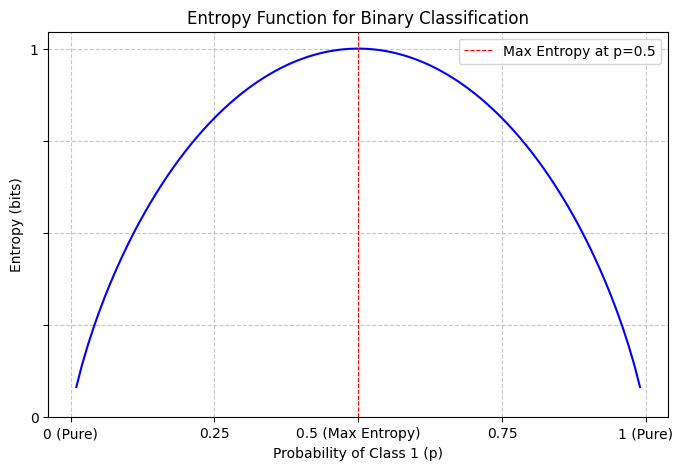

In [39]:

import numpy as np
import matplotlib.pyplot as plt

def entropy_function(p):
    if p == 0 or p == 1:
        return 0
    return - (p * np.log2(p) + (1 - p) * np.log2(1 - p))

p_values = np.linspace(0.01, 0.99, 100)
entropies = [entropy_function(p) for p in p_values]

plt.figure(figsize=(8, 5))
plt.plot(p_values, entropies, color='blue')
plt.title('Entropy Function for Binary Classification')
plt.xlabel('Probability of Class 1 (p)')
plt.ylabel('Entropy (bits)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([0, 0.25, 0.5, 0.75, 1], ['0 (Pure)', '0.25', '0.5 (Max Entropy)', '0.75', '1 (Pure)'])
plt.yticks([0, 0.25, 0.5, 0.75, 1], ['0', '', '', '', '1'])
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=0.8, label='Max Entropy at p=0.5')
plt.legend()
plt.show()

### 9. Hyperparameters (Relation to Entropy)

The primary hyperparameter directly related to entropy in `scikit-learn`'s Decision Tree implementations is:

*   **`criterion`**: This parameter determines the function to measure the quality of a split. If `criterion='entropy'`, the decision tree algorithm will use entropy (and consequently, information gain) to evaluate potential splits at each node. The other common option is `criterion='gini'`, which uses Gini Impurity. The choice of criterion often has a minor impact on model performance in practice, but `entropy` tends to produce slightly more balanced trees, while `gini` is computationally faster as it avoids logarithmic calculations.

### 10. Advantages
*   **Robust Measure of Disorder:** Entropy provides a theoretically sound and intuitive measure of impurity in a dataset.
*   **Foundation for Information Gain:** It directly leads to Information Gain, which is a powerful metric for feature selection and guiding splits.
*   **Bias Towards Balanced Splits (Sometimes):** When used as a splitting criterion, entropy (via Information Gain) can sometimes favor splits that produce more balanced child nodes compared to Gini impurity, which might lead to a more symmetrical tree structure.
*   **Widely Understood:** As a concept from information theory, entropy is well-established and universally recognized for quantifying uncertainty.

### 11. Limitations
*   **Computational Cost:** Calculating logarithms for entropy can be computationally more expensive than calculating Gini impurity, especially for very large datasets or during hyperparameter tuning (though this difference is often negligible with modern computing power).
*   **Bias Towards More Classes:** Information Gain, which uses entropy, has a tendency to favor attributes with a larger number of unique values. This is because attributes with more outcomes can create more (and potentially smaller) child nodes, artificially appearing to reduce entropy more significantly simply due to a finer partitioning of the data, even if those splits are not truly more informative. This can lead to overfitting by creating overly complex trees.
*   **Sensitive to Noise:** Like any impurity measure, entropy can be sensitive to noisy data, potentially leading to splits on irrelevant features if they happen to create locally pure subsets by chance.

### 12. Time Complexity

Calculating entropy for a node with $N$ samples and $C$ classes involves:

1.  Counting the occurrences of each class: $O(N)$.
2.  Calculating proportions $p_i$: $O(C)$.
3.  Calculating $C$ logarithms and $C$ multiplications/additions: $O(C)$.

So, for a single node, the time complexity of calculating entropy is $O(N + C)$. Since $C$ is usually small, this is often dominated by $O(N)$.

When considering a split, we calculate parent entropy once, then iterate through child nodes, calculating their entropies and then a weighted average. This adds up, contributing to the overall $O(M \cdot N \log N)$ complexity for tree building, as discussed previously. The logarithmic calculations do make it slightly slower than Gini Impurity, which only involves multiplications and subtractions.

### 13. Python Implementation (Calculating Entropy)

Let's implement a simple function to calculate entropy and test it with our numerical example.

In [40]:
import numpy as np
from collections import Counter

def calculate_entropy(labels):
    # Count the occurrences of each class
    class_counts = Counter(labels)
    total_samples = len(labels)

    entropy = 0.0
    for count in class_counts.values():
        # Calculate the proportion of each class
        p_i = count / total_samples
        # Add the term to entropy (handle log2(0) case)
        if p_i > 0:
            entropy -= p_i * np.log2(p_i)
    return entropy

# Example from our numerical section
play_tennis_labels = ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']

initial_entropy = calculate_entropy(play_tennis_labels)
print(f"Initial Entropy of 'Play Tennis' dataset: {initial_entropy:.3f} bits")

# Let's consider splitting by 'Outlook' for 'Sunny'
# Samples where Outlook is Sunny:
# Sunny -> No
# Sunny -> No
# Sunny -> No
# Sunny -> Yes

sunny_labels = ['No', 'No', 'No', 'Yes']
entropy_sunny = calculate_entropy(sunny_labels)
print(f"Entropy for 'Sunny' subset: {entropy_sunny:.3f} bits")

# Samples where Outlook is Overcast:
# Overcast -> Yes
# Overcast -> Yes

overcast_labels = ['Yes', 'Yes']
entropy_overcast = calculate_entropy(overcast_labels)
print(f"Entropy for 'Overcast' subset: {entropy_overcast:.3f} bits")

# Samples where Outlook is Rain:
# Rain -> Yes
# Rain -> Yes
# Rain -> No
# Rain -> Yes

rain_labels = ['Yes', 'Yes', 'No', 'Yes']
entropy_rain = calculate_entropy(rain_labels)
print(f"Entropy for 'Rain' subset: {entropy_rain:.3f} bits")

# We will use these entropy values to calculate Information Gain in the next section.
# Note: The `np.log2` function is used for base-2 logarithm.

Initial Entropy of 'Play Tennis' dataset: 0.971 bits
Entropy for 'Sunny' subset: 0.811 bits
Entropy for 'Overcast' subset: 0.000 bits
Entropy for 'Rain' subset: 0.811 bits


### 14. Questions
*   What does an entropy value of 0 signify in a decision tree node?
*   How does entropy change as a dataset becomes more mixed or less mixed?
*   Why is base-2 logarithm typically used in the entropy formula for information theory?
*   Can entropy be a negative value? Why or why not?

### 15. Summary
Entropy is a fundamental concept in information theory, adopted by decision tree algorithms to quantify the level of disorder or uncertainty within a set of data. It plays a crucial role as an impurity measure, guiding the tree's splitting process. A higher entropy indicates a more heterogeneous mix of classes, while zero entropy signifies perfect purity. By calculating entropy before and after a potential split, decision trees use the resulting Information Gain to determine the most effective features for partitioning the data, aiming to create child nodes with progressively lower entropy and ultimately pure leaf nodes.

### 16. Comparison with Previous Algorithms

Compared to models like Linear Regression or KNN, which do not explicitly quantify 'disorder' or 'uncertainty' in a statistical sense for their core mechanics, Entropy introduces a powerful way for Decision Trees to **evaluate the quality of potential splits**. While linear models might use metrics like Mean Squared Error or cross-entropy loss (distinct from the Information Theory entropy discussed here) for optimization, and KNN relies on distance metrics, Decision Trees leverage entropy (and Gini impurity) directly to determine *how* to construct the model's structure. This makes entropy a unique and central mathematical foundation for tree-based algorithms, driving their ability to recursively learn decision boundaries based on feature information content.

## 4. Information Gain

### 1. Definition

**Information Gain (IG)** is a core concept in the construction of decision trees, particularly for algorithms like ID3 and C4.5. It quantifies the expected reduction in entropy caused by splitting a dataset based on an attribute. In essence, it measures how much 'information' a feature provides about the target variable, or how much uncertainty is reduced after applying a specific split. A higher Information Gain indicates a better split, as it leads to more homogeneous (purer) subsets.

### 2. Why do we need it?

Information Gain is essential because it provides the criterion by which decision tree algorithms select the 'best' attribute to split on at each node. Without it, the tree would not know which feature to use to make decisions. Its primary roles are:

*   **Feature Selection:** It helps in identifying the most relevant features for classification or regression.
*   **Optimal Splitting:** At each internal node, the algorithm evaluates all possible splits and chooses the one that yields the maximum Information Gain, ensuring that each decision effectively reduces uncertainty about the target variable.
*   **Tree Construction:** It drives the greedy, top-down, recursive splitting process that builds the decision tree, aiming to create increasingly pure child nodes.

### 3. Intuition

Imagine you have a mixed bag of fruits (apples and oranges), and you want to separate them. You could use different criteria:

*   **Color:** If you split by 'Red' vs. 'Orange', you might get mostly red apples and some red oranges in one pile, and orange oranges in another. This split reduces some mixing but doesn't fully separate.
*   **Shape:** If you split by 'Round' vs. 'Oval', you might get apples in one pile and oranges in another. This split creates very pure piles.

Information Gain helps a decision tree find the 'Shape' criterion over 'Color' because 'Shape' provides more information, leading to a greater reduction in the mixed-ness (entropy) of the piles. The more the uncertainty is reduced after a split, the more 'information' that split provided, and thus, the higher its Information Gain.

### 4. Mathematical Foundation

Information Gain is rooted in information theory, specifically leveraging the concept of Entropy. It quantifies the change in entropy from before a split to after a split, taking into account the weighted average entropy of the resulting child nodes. The mathematical foundation relies on calculating probabilities of class occurrences within different subsets of data and then applying the logarithmic function of entropy.

### 5. Formula

The Information Gain (IG) for splitting a dataset $S$ on an attribute $A$ is defined as:

$$ IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v) $$

Where:
*   $IG(S, A)$ is the Information Gain of splitting $S$ by attribute $A$.
*   $H(S)$ is the Entropy of the dataset $S$ before the split.
*   $Values(A)$ is the set of all possible values for attribute $A$.
*   $S_v$ is the subset of $S$ where attribute $A$ has the value $v$.
*   $|S_v|$ is the number of samples in the subset $S_v$.
*   $|S|$ is the total number of samples in the dataset $S$.
*   $H(S_v)$ is the Entropy of the subset $S_v$.

In simpler terms:

**Information Gain = (Entropy of Parent Node) - (Weighted Average Entropy of Child Nodes)**

The sum $\sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$ represents the weighted average entropy of the partitions formed by splitting on attribute $A$. The weights $\frac{|S_v|}{|S|}$ ensure that the contribution of each child node's entropy is proportional to its size relative to the parent node.

### 6. Numerical Example

Let's continue with our `Play Tennis` dataset from the Entropy section. We have:

Total samples = 10
`Play Tennis = Yes`: 6 samples
`Play Tennis = No`: 4 samples

We previously calculated the **Initial Entropy of the Root Node**: $H(S) \approx 0.971$ bits.

Now, let's calculate the Information Gain for splitting on the 'Outlook' feature. The 'Outlook' feature has three possible values: 'Sunny', 'Overcast', 'Rain'.

**Subsets after splitting by 'Outlook':**

1.  **Outlook = Sunny (4 samples):**
    *   `Play Tennis = Yes`: 1
    *   `Play Tennis = No`: 3
    *   $p_{Yes} = 1/4 = 0.25$, $p_{No} = 3/4 = 0.75$
    *   $H(S_{Sunny}) = - (0.25 \log_2(0.25) + 0.75 \log_2(0.75)) = - (0.25 \times -2 + 0.75 \times -0.415) = - (-0.5 - 0.311) = 0.811$ bits

2.  **Outlook = Overcast (2 samples):**
    *   `Play Tennis = Yes`: 2
    *   `Play Tennis = No`: 0
    *   $p_{Yes} = 2/2 = 1$, $p_{No} = 0/2 = 0$
    *   $H(S_{Overcast}) = - (1 \log_2(1) + 0 \log_2(0)) = - (1 \times 0 + 0) = 0$ bits (pure node)

3.  **Outlook = Rain (4 samples):**
    *   `Play Tennis = Yes`: 3
    *   `Play Tennis = No`: 1
    *   $p_{Yes} = 3/4 = 0.75$, $p_{No} = 1/4 = 0.25$
    *   $H(S_{Rain}) = - (0.75 \log_2(0.75) + 0.25 \log_2(0.25)) = - (0.75 \times -0.415 + 0.25 \times -2) = - (-0.311 - 0.5) = 0.811$ bits

**Step 2: Calculate the Weighted Average Entropy of Child Nodes.**

Weighted Average Entropy = $\frac{4}{10} H(S_{Sunny}) + \frac{2}{10} H(S_{Overcast}) + \frac{4}{10} H(S_{Rain})$

Weighted Average Entropy = $(0.4 \times 0.811) + (0.2 \times 0) + (0.4 \times 0.811)$
Weighted Average Entropy = $0.3244 + 0 + 0.3244 = 0.6488$ bits

**Step 3: Calculate Information Gain for 'Outlook'.**

$IG(S, Outlook) = H(S) - \text{Weighted Average Entropy}$
$IG(S, Outlook) = 0.971 - 0.6488 = 0.3222$ bits

This value of 0.3222 bits represents the reduction in uncertainty about playing tennis if we know the 'Outlook'. The decision tree algorithm would calculate Information Gain for all other features (e.g., 'Temperature', 'Humidity', 'Wind') and choose the feature with the highest Information Gain as the first split.

### 7. Working (Step-by-Step)

Information Gain is the engine that drives the recursive partitioning process of decision trees:

1.  **Initial Node:** Start with the root node containing the entire dataset.

2.  **Calculate Parent Entropy:** Determine the entropy $H(S)$ of the current node before any split.

3.  **Iterate Through Features:** For each available feature not yet used in the current path:

    a.  **Identify Possible Splits:** For categorical features, each unique value is a potential branch. For continuous features, various thresholds are considered as binary splits.

    b.  **Create Subsets:** Conceptually divide the current node's data into subsets ($S_v$) based on the chosen feature and split point.

    c.  **Calculate Child Entropies:** For each resulting subset $S_v$, calculate its entropy $H(S_v)$.

    d.  **Calculate Weighted Average Child Entropy:** Compute the weighted average of these child entropies, where weights are the proportion of samples in each subset: $\sum \frac{|S_v|}{|S|} H(S_v)$.

    e.  **Calculate Information Gain:** Subtract the weighted average child entropy from the parent entropy to get the Information Gain for that specific feature/split: $IG(S, A) = H(S) - \text{Weighted Average Entropy}$.

4.  **Select Best Split:** Choose the feature and its corresponding split point that yields the *maximum* Information Gain. This is the split that reduces the most uncertainty.

5.  **Create Child Nodes:** Implement the chosen split, creating new child nodes for each outcome.

6.  **Recurse:** Apply steps 2-5 recursively to each new child node. This continues until all nodes are pure, a maximum depth is reached, or the Information Gain from any potential further split falls below a predefined threshold.

### 8. Visualization

Visualizing Information Gain directly is challenging because it's a calculated value. However, we can visualize its *effect* on the data and the tree structure. The goal of high Information Gain is to transform a mixed (high entropy) node into purer (low entropy) child nodes. A visual representation would show:

*   A parent node with a mixture of classes (e.g., red and blue points).
*   A split line (decision boundary) chosen by maximizing Information Gain.
*   Two (or more) child nodes, each containing a more dominant class (e.g., one mostly red, one mostly blue).

The more effective the split, the more clearly separated the classes will be in the child nodes.

## Entropy After Splitting on Outlook

```text
                    Parent Node
          H(S) = 0.971 (Mixed Classes)
                     │
                     ▼
              Split on Outlook
                     │
        ┌────────────┼────────────┐
        │            │            │
        ▼            ▼            ▼
     Sunny      Overcast        Rain
        │            │            │
        ▼            ▼            ▼
 H(S_Sunny)     H(S_Overcast)   H(S_Rain)
    = 0.811          = 0.000        = 0.811
 (Less Pure)      (Pure Node)    (Less Pure)
```

### Interpretation

- **Parent Node**
  - Entropy = **0.971**
  - Contains a mixture of both classes.

- **Split Feature**
  - The dataset is divided using the feature **Outlook**.

- **Sunny**
  - Entropy = **0.811**
  - Samples are still mixed.
  - Additional splits may improve purity.

- **Overcast**
  - Entropy = **0.000**
  - All samples belong to the same class.
  - This is already a **leaf node**.

- **Rain**
  - Entropy = **0.811**
  - Samples remain mixed.
  - More splitting is beneficial.

---

## Entropy Reduction View

```text
Entropy

1.0 ┤ ● Parent
    │  H(S)=0.971
0.8 ┤      ● Sunny
    │      H=0.811
0.6 ┤
0.4 ┤
0.2 ┤
0.0 ┤             ● Overcast
    │             H=0.000
    │                      ● Rain
    │                      H=0.811
    └──────────────────────────────────────► Child Nodes
```

**Observation**

- The **Overcast** branch becomes perfectly pure (**Entropy = 0**), so no further splitting is needed.
- The **Sunny** and **Rain** branches still contain mixed classes (**Entropy = 0.811**) and require additional splits.
- Decision tree algorithms always try to create child nodes with **lower entropy** than the parent node, thereby maximizing **Information Gain**.
This diagram conceptually shows the reduction in entropy from the parent node to the child nodes after a split. The node `D` (Overcast) becoming perfectly pure (Entropy = 0) is a direct result of a good split with high Information Gain.

### 9. Hyperparameters (Relation to Information Gain)

The primary hyperparameter directly linked to Information Gain is `criterion`.

*   **`criterion`**: In `sklearn.tree.DecisionTreeClassifier`, setting `criterion='entropy'` means the algorithm will use Information Gain (calculated from entropy) as its metric for evaluating the quality of a split. If `criterion='gini'` is chosen, it uses Gini Impurity (and Gini Gain) instead. Both serve the same purpose: guiding the greedy search for the best split at each node. The choice between them often yields similar results, but 'entropy' can be computationally slower due to the logarithm calculations.

### 10. Advantages
*   **Effective Split Selection:** Information Gain provides a robust method for choosing the most informative features to split the data, leading to efficient tree construction.
*   **Reduces Uncertainty:** By aiming for maximum gain, it ensures that each split maximally reduces the entropy (uncertainty) about the target variable.
*   **Interpretability:** Since it's based on entropy, it has an intuitive understanding in terms of 'information' and 'disorder reduction'.
*   **Implicit Feature Selection:** Features with high Information Gain are prioritized and placed higher in the tree, effectively performing an implicit feature selection.

### 11. Limitations
*   **Bias Towards Many-Valued Attributes:** Information Gain tends to favor attributes with a large number of distinct values (e.g., unique IDs or continuous features with many unique thresholds). This is because such attributes can create many small, highly pure (low entropy) child nodes, artificially inflating their Information Gain even if they are not truly better predictors. This can lead to overly complex and less generalizable trees.
*   **Computational Cost:** As it relies on entropy calculations (involving logarithms), it can be slightly more computationally intensive than methods based on Gini Impurity, especially for large datasets.
*   **Greedy Approach:** Like all standard decision tree algorithms, the greedy nature of maximizing Information Gain at each step does not guarantee a globally optimal tree.

### 12. Time Complexity

The time complexity for calculating Information Gain for a single split on a feature depends on the number of samples ($N$) in the node and the number of distinct values/categories ($V$) for that feature. This usually involves:

1.  Calculating parent entropy: $O(N)$.
2.  Iterating through each possible split point or category for the feature.
3.  For each split, partitioning the data and calculating child entropies: $O(N)$ for each split.

If a feature has $V$ unique values, evaluating all splits for that feature can be approximately $O(V 	imes N)$. If the feature is continuous, and sorting is required to find optimal split points, it can involve $O(N \log N)$.

Overall, the selection of the best split for a node across all $M$ features contributes significantly to the total tree building time, which is roughly $O(M \cdot N \log N)$ as discussed in the 'Decision Tree' and 'Entropy' sections.

### 13. Python Implementation

Let's implement a function to calculate Information Gain using our previously defined `calculate_entropy` function.


In [41]:
import numpy as np
from collections import Counter
import pandas as pd

# Re-using the calculate_entropy function from previous section
def calculate_entropy(labels):
    class_counts = Counter(labels)
    total_samples = len(labels)
    entropy = 0.0
    for count in class_counts.values():
        p_i = count / total_samples
        if p_i > 0:
            entropy -= p_i * np.log2(p_i)
    return entropy

def calculate_information_gain(data, feature_name, target_name):
    # Extract target labels
    target_labels = data[target_name].tolist()
    # Calculate entropy of the parent node
    parent_entropy = calculate_entropy(target_labels)

    # Get unique values of the feature to split on
    feature_values = data[feature_name].unique()

    weighted_child_entropy = 0.0
    for value in feature_values:
        # Subset of data for each feature value
        subset = data[data[feature_name] == value]
        subset_labels = subset[target_name].tolist()
        # Calculate entropy of the subset
        subset_entropy = calculate_entropy(subset_labels)
        # Calculate weight of the subset
        weight = len(subset) / len(data)
        weighted_child_entropy += weight * subset_entropy

    # Calculate Information Gain
    information_gain = parent_entropy - weighted_child_entropy
    return information_gain

# --- Numerical Example Data ---
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)

# Calculate Information Gain for 'Outlook'
ig_outlook = calculate_information_gain(df, 'Outlook', 'PlayTennis')
print(f"Information Gain for 'Outlook': {ig_outlook:.4f} bits")

# Calculate Information Gain for 'Humidity'
ig_humidity = calculate_information_gain(df, 'Humidity', 'PlayTennis')
print(f"Information Gain for 'Humidity': {ig_humidity:.4f} bits")

# Calculate Information Gain for 'Wind'
ig_wind = calculate_information_gain(df, 'Wind', 'PlayTennis')
print(f"Information Gain for 'Wind': {ig_wind:.4f} bits")

# The feature with the highest Information Gain (in this case, 'Outlook') would be chosen for the split.

Information Gain for 'Outlook': 0.3219 bits
Information Gain for 'Humidity': 0.1245 bits
Information Gain for 'Wind': 0.0913 bits


### 14. Questions
*   How is Information Gain related to Entropy?
*   What would an Information Gain of 0 for a feature imply about that feature's usefulness for splitting?
*   Why might a decision tree algorithm prefer a feature with many unique values when using Information Gain?
*   In a scenario with two features, Feature A (IG=0.3) and Feature B (IG=0.1), which feature would the decision tree typically choose for the next split and why?

### 15. Summary
Information Gain is a crucial metric in decision tree algorithms, particularly those based on entropy. It quantifies the reduction in uncertainty (entropy) that results from splitting a dataset on a particular feature. By selecting the feature and split point that yield the highest Information Gain, decision trees are built in a greedy, top-down fashion, creating increasingly pure child nodes. While powerful for identifying informative features and guiding tree construction, it has a known bias towards features with many unique values, which is an important consideration in model development.

### 16. Comparison with Previous Algorithms

Information Gain provides a distinct mechanism for split selection compared to other algorithms:

*   **Vs. Linear Models (e.g., Logistic Regression):** Linear models use coefficients to determine feature importance, fitting a linear boundary based on minimizing a cost function (like cross-entropy loss). Information Gain, in contrast, directly evaluates a feature's ability to reduce impurity *hierarchically*, without assuming linearity.
*   **Vs. KNN:** KNN makes predictions based on proximity in feature space and does not explicitly evaluate 'feature importance' or 'split quality' during a training phase in the same way. It's a 'lazy' algorithm where computation is deferred to prediction time.
*   **Vs. Support Vector Machines (SVMs):** SVMs seek to find an optimal hyperplane that maximizes the margin between classes. While they identify decision boundaries, they don't involve the recursive, entropy-based splitting inherent to decision trees guided by Information Gain.

Information Gain's role as a greedy splitting criterion makes it unique in how decision trees construct their model, focusing on sequential reduction of uncertainty through data partitioning.

## 5. Gini Impurity

### 1. Definition

**Gini Impurity** (also known as Gini Index) is a measure of the misclassification rate if a given element from a set were randomly labeled according to the class distribution in the set. In the context of decision trees, it quantifies the impurity or 'mixed-ness' of a node. A Gini Impurity of 0 means the node is perfectly pure (all samples belong to a single class), while a Gini Impurity of 0.5 (for a binary classification problem) indicates maximum impurity (an equal distribution of classes). It is the splitting criterion used by the CART (Classification and Regression Tree) algorithm for classification tasks.

### 2. Why do we need it?

Similar to entropy, Gini Impurity is crucial for decision tree algorithms because it provides a quantitative way to:

*   **Measure Node Impurity:** It tells us how homogeneous or heterogeneous the samples within a node are with respect to their target class.
*   **Guide Optimal Splits:** At each node, the decision tree algorithm evaluates all possible splits and selects the one that results in the greatest reduction in Gini Impurity (this reduction is sometimes called **Gini Gain**). This ensures that each split moves the data towards greater purity.
*   **Build the Tree Structure:** It serves as the primary metric for determining the best feature and split point at each step of the recursive tree construction process for algorithms like CART.

### 3. Intuition

Think about the probability of picking two items from a bag and them being different. If a bag contains items of only one type (e.g., all red marbles), the probability of picking two different items is zero. This is a pure state, and its Gini Impurity is 0.

If a bag contains an equal mix of two types of items (e.g., 5 red, 5 blue marbles), the probability of picking two different items is high. This represents a highly impure state, and its Gini Impurity is maximal (0.5 for binary classes).

The Gini Impurity essentially measures the probability of misclassifying a randomly chosen element from the set if it were randomly classified according to the class distribution in the subset. Decision trees try to find splits that minimize this probability of misclassification in the resulting child nodes.

### 4. Mathematical Foundation

Gini Impurity is derived from the concept of probability. For a given node, it calculates the sum of the squared probabilities of each class being present in that node, subtracted from 1. This value represents the total probability of misclassification. The goal is to minimize this value at each split.

### 5. Formula

The formula for Gini Impurity $G(S)$ for a dataset $S$ with $C$ distinct classes is given by:

$$ G(S) = 1 - \sum_{i=1}^{C} p_i^2 $$

Where:
*   $S$ is the dataset (or a node in the decision tree).
*   $C$ is the number of unique classes in the target variable within $S$.
*   $p_i$ is the proportion (or probability) of samples in $S$ that belong to class $i$.

**Key Properties of Gini Impurity:**
*   $0 \le G(S) \le 1 - 1/C$
*   It is 0 when the dataset $S$ is perfectly pure (all samples belong to a single class, so one $p_i = 1$ and all others are 0).
*   It is maximum when all classes are equally represented in $S$. For a binary classification ($C=2$), maximum Gini Impurity occurs when $p_1 = p_2 = 0.5$, resulting in $G(S) = 1 - (0.5^2 + 0.5^2) = 1 - (0.25 + 0.25) = 1 - 0.5 = 0.5$. For $C$ classes, maximum impurity is $1 - C \times (1/C)^2 = 1 - 1/C$.

The reduction in Gini Impurity after a split is called **Gini Gain** (or sometimes just the decrease in Gini impurity) and is calculated as:

$$ GiniGain(S, A) = G(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} G(S_v) $$

Where the terms are analogous to those used for Information Gain, but with Gini Impurity instead of Entropy.

### 6. Numerical Example

Let's reuse our `Play Tennis` dataset to calculate Gini Impurity and Gini Gain. We have:

Total samples = 10
`Play Tennis = Yes`: 6 samples
`Play Tennis = No`: 4 samples

**Step 1: Calculate the Gini Impurity of the Root Node (entire dataset).**

Proportion of 'Yes' ($p_{Yes}$) = $6/10 = 0.6$
Proportion of 'No' ($p_{No}$) = $4/10 = 0.4$

$G(S) = 1 - (p_{Yes}^2 + p_{No}^2)$
$G(S) = 1 - (0.6^2 + 0.4^2)$
$G(S) = 1 - (0.36 + 0.16)$
$G(S) = 1 - 0.52 = 0.48$

This is the initial impurity of our dataset.

**Step 2: Calculate Gini Impurity for splitting on 'Outlook'.**

Recall the subsets after splitting by 'Outlook':

1.  **Outlook = Sunny (4 samples):**
    *   `Play Tennis = Yes`: 1, `Play Tennis = No`: 3
    *   $p_{Yes} = 1/4 = 0.25$, $p_{No} = 3/4 = 0.75$
    *   $G(S_{Sunny}) = 1 - (0.25^2 + 0.75^2) = 1 - (0.0625 + 0.5625) = 1 - 0.625 = 0.375$

2.  **Outlook = Overcast (2 samples):**
    *   `Play Tennis = Yes`: 2, `Play Tennis = No`: 0
    *   $p_{Yes} = 2/2 = 1$, $p_{No} = 0/2 = 0$
    *   $G(S_{Overcast}) = 1 - (1^2 + 0^2) = 1 - 1 = 0$ (pure node)

3.  **Outlook = Rain (4 samples):**
    *   `Play Tennis = Yes`: 3, `Play Tennis = No`: 1
    *   $p_{Yes} = 3/4 = 0.75$, $p_{No} = 1/4 = 0.25$
    *   $G(S_{Rain}) = 1 - (0.75^2 + 0.25^2) = 1 - (0.5625 + 0.0625) = 1 - 0.625 = 0.375$

**Step 3: Calculate the Weighted Average Gini Impurity of Child Nodes.**

Weighted Average Gini = $\frac{4}{10} G(S_{Sunny}) + \frac{2}{10} G(S_{Overcast}) + \frac{4}{10} G(S_{Rain})$

Weighted Average Gini = $(0.4 \times 0.375) + (0.2 \times 0) + (0.4 \times 0.375)$
Weighted Average Gini = $0.15 + 0 + 0.15 = 0.30$

**Step 4: Calculate Gini Gain for 'Outlook'.**

$GiniGain(S, Outlook) = G(S) - \text{Weighted Average Gini}$
$GiniGain(S, Outlook) = 0.48 - 0.30 = 0.18$

This Gini Gain of 0.18 for 'Outlook' indicates how much the impurity is reduced by splitting on this feature. The algorithm would perform this calculation for all features and choose the one with the highest Gini Gain.

### 7. Working (Step-by-Step)

The process of using Gini Impurity to construct a decision tree is very similar to using Information Gain:

1.  **Initial Node:** Begin with the root node, encompassing the entire dataset.

2.  **Calculate Parent Gini Impurity:** Determine the Gini Impurity $G(S)$ of the current node.

3.  **Iterate Through Features:** For each available feature not yet used in the current path:

    a.  **Identify Possible Splits:** Consider all possible thresholds for continuous features or all unique values for categorical features to create potential binary (or multi-way) splits.

    b.  **Create Subsets:** Conceptually divide the current node's data into subsets ($S_v$) based on the chosen feature and split point.

    c.  **Calculate Child Gini Impurities:** For each resulting subset $S_v$, calculate its Gini Impurity $G(S_v)$.

    d.  **Calculate Weighted Average Child Gini Impurity:** Compute the weighted average of these child Gini Impurities: $\sum \frac{|S_v|}{|S|} G(S_v)$.

    e.  **Calculate Gini Gain:** Subtract the weighted average child Gini Impurity from the parent's Gini Impurity: $GiniGain(S, A) = G(S) - \text{Weighted Average Gini Impurity}$.

4.  **Select Best Split:** Choose the feature and its corresponding split point that yields the *maximum* Gini Gain.

5.  **Create Child Nodes:** Implement the chosen split, creating new child nodes.

6.  **Recurse:** Apply steps 2-5 recursively to each new child node. This continues until all nodes are pure, a maximum tree depth is reached, the number of samples in a node is too small, or the Gini Gain from further splitting is negligible.

### 8. Visualization

Similar to entropy, Gini Impurity is a numerical measure, so its direct visualization involves showing its value at nodes or how it changes. The goal is to see a reduction in impurity as the tree branches.

We can visualize the Gini Impurity function, which is a parabolic curve:


In a decision tree plot, the Gini impurity value would be displayed within each node, showing its decrease towards the leaf nodes, just as entropy was shown in the previous examples. A node labeled `gini = 0.0` would visually represent a pure leaf node.

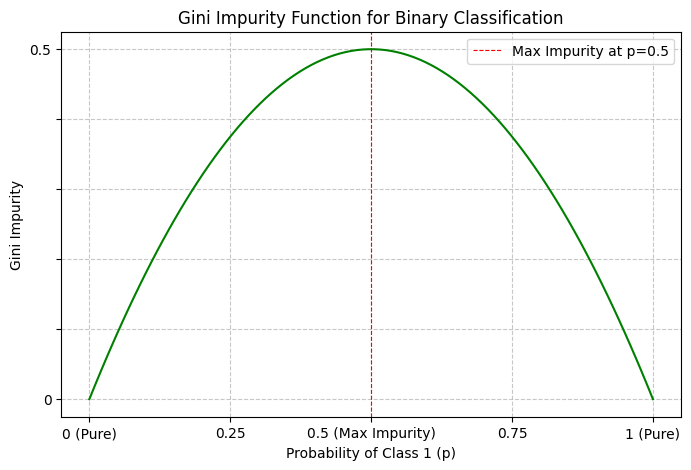

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def gini_impurity_function(p):
    # For a binary classification, p is probability of class 1
    return 1 - (p**2 + (1 - p)**2)

p_values = np.linspace(0, 1, 100)
gini_impurities = [gini_impurity_function(p) for p in p_values]

plt.figure(figsize=(8, 5))
plt.plot(p_values, gini_impurities, color='green')
plt.title('Gini Impurity Function for Binary Classification')
plt.xlabel('Probability of Class 1 (p)')
plt.ylabel('Gini Impurity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([0, 0.25, 0.5, 0.75, 1], ['0 (Pure)', '0.25', '0.5 (Max Impurity)', '0.75', '1 (Pure)'])
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5], ['0', '', '', '', '', '0.5'])
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=0.8, label='Max Impurity at p=0.5')
plt.legend()
plt.show()

### 9. Hyperparameters (Relation to Gini Impurity)

The primary hyperparameter directly related to Gini Impurity is `criterion`.

*   **`criterion`**: In `sklearn.tree.DecisionTreeClassifier`, setting `criterion='gini'` (which is often the default) means the algorithm will use Gini Impurity (and consequently, Gini Gain) as its metric for evaluating the quality of a split. The alternative is `criterion='entropy'`, which uses Information Gain. While both are effective, Gini Impurity is generally preferred for its computational efficiency, as it does not involve logarithmic calculations, making it faster to compute, especially on large datasets. In practice, the choice between Gini and Entropy rarely makes a significant difference to the final model's accuracy.

### 10. Advantages
*   **Computational Efficiency:** Gini Impurity is computationally faster to calculate than entropy because it avoids the use of logarithms, relying instead on simpler squaring and subtraction operations.
*   **Focus on Majority Class:** Gini Impurity tends to isolate the majority class in a node, aiming to create splits where one child node is as pure as possible, often favoring larger partitions.
*   **No Bias Towards Many-Valued Attributes:** Unlike Information Gain, Gini Impurity does not inherently favor attributes with a larger number of unique values, making it a more balanced splitting criterion in some scenarios.
*   **Good Default Choice:** Due to its efficiency and generally good performance, it's often the default splitting criterion in many decision tree implementations (like scikit-learn).

### 11. Limitations
*   **Less Intuitive (for some):** While effective, its interpretation in terms of 'misclassification probability' might be slightly less intuitive than 'information' or 'uncertainty' reduction associated with entropy.
*   **Binary Splits Focus:** Gini Impurity typically works best with binary splits, which is characteristic of the CART algorithm that commonly employs it. While it can be extended for multi-way splits, its common formulation is for binary partitions.
*   **Similar Outcomes to Entropy:** In many real-world scenarios, the choice between Gini Impurity and Entropy as a splitting criterion leads to very similar tree structures and performance, suggesting that its distinct advantages over entropy might not always be substantial.

### 12. Time Complexity

Calculating Gini Impurity for a node with $N$ samples and $C$ classes involves:

1.  Counting the occurrences of each class: $O(N)$.
2.  Calculating proportions $p_i$: $O(C)$.
3.  Calculating $C$ squares and a sum/subtraction: $O(C)$.

So, for a single node, the time complexity of calculating Gini Impurity is $O(N + C)$. Since $C$ is usually small, this is often dominated by $O(N)$.

When evaluating a split, this calculation is done for the parent and all child nodes. Because Gini Impurity avoids logarithmic calculations, it is generally slightly faster than entropy, contributing to a more efficient overall tree-building process. The total time complexity for building a tree using Gini Impurity remains approximately $O(M \cdot N \log N)$, but the constant factor is smaller than with entropy.

### 13. Python Implementation

Let's implement functions to calculate Gini Impurity and Gini Gain using our previous `Play Tennis` dataset.


In [42]:
import numpy as np
from collections import Counter
import pandas as pd

def calculate_gini_impurity(labels):
    # Count the occurrences of each class
    class_counts = Counter(labels)
    total_samples = len(labels)

    gini = 1.0
    for count in class_counts.values():
        p_i = count / total_samples
        gini -= p_i**2
    return gini

def calculate_gini_gain(data, feature_name, target_name):
    # Extract target labels
    target_labels = data[target_name].tolist()
    # Calculate Gini impurity of the parent node
    parent_gini = calculate_gini_impurity(target_labels)

    # Get unique values of the feature to split on
    feature_values = data[feature_name].unique()

    weighted_child_gini = 0.0
    for value in feature_values:
        # Subset of data for each feature value
        subset = data[data[feature_name] == value]
        subset_labels = subset[target_name].tolist()
        # Calculate Gini impurity of the subset
        subset_gini = calculate_gini_impurity(subset_labels)
        # Calculate weight of the subset
        weight = len(subset) / len(data)
        weighted_child_gini += weight * subset_gini

    # Calculate Gini Gain
    gini_gain = parent_gini - weighted_child_gini
    return gini_gain

# --- Numerical Example Data ---
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)

# Calculate Gini Impurity for the root node
root_gini = calculate_gini_impurity(df['PlayTennis'].tolist())
print(f"Initial Gini Impurity of 'Play Tennis' dataset: {root_gini:.3f}")

# Calculate Gini Gain for 'Outlook'
gg_outlook = calculate_gini_gain(df, 'Outlook', 'PlayTennis')
print(f"Gini Gain for 'Outlook': {gg_outlook:.3f}")

# Calculate Gini Gain for 'Humidity'
gg_humidity = calculate_gini_gain(df, 'Humidity', 'PlayTennis')
print(f"Gini Gain for 'Humidity': {gg_humidity:.3f}")

# Calculate Gini Gain for 'Wind'
gg_wind = calculate_gini_gain(df, 'Wind', 'PlayTennis')
print(f"Gini Gain for 'Wind': {gg_wind:.3f}")

# The feature with the highest Gini Gain (in this case, 'Outlook') would be chosen for the split.

Initial Gini Impurity of 'Play Tennis' dataset: 0.480
Gini Gain for 'Outlook': 0.180
Gini Gain for 'Humidity': 0.080
Gini Gain for 'Wind': 0.061


### 14. Questions
*   What is the main conceptual difference between Gini Impurity and Entropy?
*   Under what conditions would Gini Impurity be 0?
*   Why is Gini Impurity generally faster to compute than Entropy?
*   If a feature has a Gini Gain of 0, what does that imply about its ability to separate classes?

### 15. Summary
Gini Impurity is a widely used metric in decision tree algorithms, particularly CART, to measure the homogeneity or purity of a node. It quantifies the probability of misclassifying a randomly chosen element if it were labeled according to the class distribution within the node. A Gini Impurity of 0 signifies perfect purity, while a higher value indicates more mixing. Decision trees utilize Gini Gain (the reduction in Gini Impurity after a split) to identify the most effective features for partitioning data. Its computational efficiency makes it a popular choice over entropy in many implementations, though both often lead to similar model performance.

### 16. Comparison with Previous Algorithms

*   **Vs. Entropy:** Gini Impurity and Entropy are both measures of node impurity used for splitting. The key differences are:
    *   **Formula:** Gini uses squared probabilities ($1 - \sum p_i^2$), while Entropy uses logarithmic probabilities ($-\sum p_i \log_2 p_i$).
    *   **Computational Cost:** Gini is generally faster as it avoids log calculations.
    *   **Bias:** Entropy (via Information Gain) has a slight bias towards features with more unique values, while Gini Impurity does not exhibit this bias as strongly.
    *   **Shape of Function:** The Gini function for binary classification is parabolic, while entropy is logarithmic. Both are maximized at a 50/50 split and 0 at pure nodes.

*   **Vs. Linear Models/KNN/SVMs:** As discussed for Entropy, Gini Impurity provides a unique, hierarchical, and greedy criterion for constructing models that directly partitions the feature space, which fundamentally differs from the optimization, distance-based, or margin-maximizing approaches of other algorithms. It maintains a degree of interpretability due to its direct role in defining decision rules.

## 6. ID3

### 1. Definition

**ID3 (Iterative Dichotomiser 3)** is one of the earliest and most well-known decision tree algorithms, developed by Ross Quinlan in 1986. It is specifically designed for classification tasks and builds decision trees by recursively splitting data based on categorical features. At each node of the tree, ID3 selects the attribute that yields the largest **Information Gain** (or equivalently, the largest reduction in entropy) to make the split. It produces multi-way splits for categorical features.

### 2. Why do we need it?

ID3 was a pioneering algorithm that demonstrated a powerful, intuitive, and interpretable approach to classification. We need to understand ID3 for several reasons:

*   **Foundational Knowledge:** It lays the groundwork for understanding more advanced decision tree algorithms like C4.5 and CART.
*   **Concept Illustration:** It clearly illustrates the core concept of using Information Gain (entropy reduction) to guide tree construction.
*   **Interpretability:** The trees generated by ID3 are generally easy to understand and visualize, which is crucial for explaining model decisions.
*   **Handling Categorical Data:** It naturally handles categorical features, which are common in many datasets.

### 3. Intuition

Imagine you're trying to identify an animal based on a series of questions. You want to ask the question that helps you narrow down the possibilities the most effectively. For example, asking "Does it have feathers?" might dramatically reduce your uncertainty, as it immediately separates birds from most other animals. ID3 works similarly:

At each step, it looks at all available features (e.g., 'Color', 'Size', 'Has Feathers?'). For each feature, it calculates how much 'information' it would give (how much it would reduce uncertainty) if you split the dataset based on that feature. It then picks the feature that provides the most 'information' (highest Information Gain) and uses that to split the data. This process is repeated until all remaining groups of animals (leaf nodes) are pure (i.e., contain only one type of animal, or a predefined stopping condition is met).

### 4. Mathematical Foundation

ID3's mathematical foundation is entirely built upon **Information Theory**, specifically using **Entropy** and **Information Gain**. As we've discussed:

*   **Entropy** quantifies the amount of uncertainty or disorder in a set of data regarding its class labels. A perfectly pure node has zero entropy, while a perfectly mixed node has maximal entropy.
*   **Information Gain** measures the reduction in entropy achieved by splitting a dataset based on a particular feature. It's the difference between the entropy of the parent node and the weighted average entropy of its child nodes.

ID3's greedy strategy is to always choose the attribute that maximizes Information Gain at each step, aiming to create child nodes that are as homogeneous as possible with respect to the target variable.

### 5. Formula

The core formula for ID3 is the **Information Gain** formula, which relies on the **Entropy** formula.

**Entropy (H)** for a dataset $S$ with $C$ classes:

$$ H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i) $$

Where $p_i$ is the proportion of samples belonging to class $i$ in the set $S$.

**Information Gain (IG)** for a split on attribute $A$:

$$ IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v) $$

Where:
*   $IG(S, A)$ is the Information Gain of splitting $S$ by attribute $A$.
*   $H(S)$ is the Entropy of the dataset $S$ before the split.
*   $Values(A)$ is the set of all possible values for attribute $A$.
*   $S_v$ is the subset of $S$ where attribute $A$ has the value $v$.
*   $|S_v|$ is the number of samples in the subset $S_v$.
*   $|S|$ is the total number of samples in the dataset $S$.
*   $H(S_v)$ is the Entropy of the subset $S_v$.

ID3 uses this formula to evaluate each candidate feature and selects the one that produces the highest $IG(S, A)$.

### 6. Numerical Example

Let's use our `Play Tennis` dataset to illustrate how ID3 would choose the first split.

**Dataset:**

| Outlook   | Temperature | Humidity | Wind   | PlayTennis |
|:----------|:------------|:---------|:-------|:-----------|
| Sunny     | Hot         | High     | Weak   | No         |
| Sunny     | Hot         | High     | Strong | No         |
| Overcast  | Hot         | High     | Weak   | Yes        |
| Rain      | Mild        | High     | Weak   | Yes        |
| Rain      | Cool        | Normal   | Weak   | Yes        |
| Rain      | Cool        | Normal   | Strong | No         |
| Overcast  | Cool        | Normal   | Strong | Yes        |
| Sunny     | Mild        | High     | Weak   | No         |
| Sunny     | Cool        | Normal   | Weak   | Yes        |
| Rain      | Mild        | Normal   | Weak   | Yes        |

Total samples = 10
`PlayTennis = Yes`: 6 samples
`PlayTennis = No`: 4 samples

**Step 1: Calculate Initial Entropy of the Root Node.**

We calculated this in the Entropy section:
$H(S) = - (0.6 \log_2(0.6) + 0.4 \log_2(0.4)) \approx 0.971$ bits.

**Step 2: Calculate Information Gain for each feature.**

We calculated Information Gain for 'Outlook', 'Humidity', and 'Wind' in the Information Gain section:

*   **IG(S, Outlook):** $\approx 0.322$ bits (calculated previously)
*   **IG(S, Humidity):** $\approx 0.125$ bits (calculated previously)
*   **IG(S, Wind):** $\approx 0.091$ bits (calculated previously)

Now, let's calculate for **'Temperature'**.

`Temperature` values: Hot (3), Mild (3), Cool (4)

*   **Temperature = Hot (3 samples):**
    *   Yes: 1 (Overcast), No: 2 (Sunny)
    *   $H(S_{Hot}) = - (1/3 \log_2(1/3) + 2/3 \log_2(2/3)) \approx 0.918$ bits

*   **Temperature = Mild (3 samples):**
    *   Yes: 2 (Rain, Rain), No: 1 (Sunny)
    *   $H(S_{Mild}) = - (2/3 \log_2(2/3) + 1/3 \log_2(1/3)) \approx 0.918$ bits

*   **Temperature = Cool (4 samples):**
    *   Yes: 3 (Rain, Overcast, Rain), No: 1 (Rain)
    *   $H(S_{Cool}) = - (3/4 \log_2(3/4) + 1/4 \log_2(1/4)) \approx 0.811$ bits

Weighted Average Entropy for Temperature:
$= (3/10) H(S_{Hot}) + (3/10) H(S_{Mild}) + (4/10) H(S_{Cool})$
$= (0.3 \times 0.918) + (0.3 \times 0.918) + (0.4 \times 0.811)$
$= 0.2754 + 0.2754 + 0.3244 = 0.8752$ bits

**IG(S, Temperature)** = $H(S) - \text{Weighted Average Entropy (Temperature)}$
$= 0.971 - 0.8752 \approx 0.096$ bits

**Step 3: Compare Information Gains and Choose Best Feature.**

*   IG(S, Outlook) $\approx 0.322$
*   IG(S, Humidity) $\approx 0.125$
*   IG(S, Wind) $\approx 0.091$
*   IG(S, Temperature) $\approx 0.096$

Since `Outlook` has the highest Information Gain ($\approx 0.322$), ID3 would choose `Outlook` as the root node to split the dataset first. The process would then recursively apply to the 'Sunny', 'Overcast', and 'Rain' child nodes.

### 7. Working (Step-by-Step)

The ID3 algorithm follows these steps to construct a decision tree:

1.  **Start:** Begin with the entire dataset $S$ as the root node.

2.  **Calculate Impurity:** Calculate the entropy of the current dataset $S$.

3.  **Iterate and Calculate Information Gain:** For every unused attribute $A$ in the dataset:
    *   Calculate the Information Gain $IG(S, A)$ that would result from splitting $S$ by attribute $A$.

4.  **Select Best Attribute:** Choose the attribute $A^*$ that yields the highest Information Gain: $A^* = \arg\max_{A} IG(S, A)$.

5.  **Create Node and Branches:** Create a node for $A^*$ and create a branch for each unique value $v$ that $A^*$ can take. Each branch leads to a new child node containing the subset $S_v$ of data where attribute $A^*$ has value $v$.

6.  **Recursive Tree Building:** For each child node $S_v$:
    *   If $S_v$ is pure (all samples in $S_v$ belong to the same class), mark it as a leaf node and assign the class label.
    *   If $S_v$ is empty, mark it as a leaf node and assign the majority class of the parent node.
    *   If there are no remaining attributes to split on, mark it as a leaf node and assign the majority class of $S_v$.
    *   Otherwise, recursively apply steps 2-6 to the child node $S_v$ using the remaining attributes.

This process continues until all nodes are pure leaf nodes, or other stopping criteria are met.

### 8. Visualization

Visualizing an ID3 tree involves showing the multi-way splits for categorical features and the Information Gain at each decision point. The structure will be similar to our general decision tree visualizations, but explicitly demonstrating the multi-branching from categorical features chosen by Information Gain.

## ID3 Decision Tree Construction

```text
                      Root Node
     PlayTennis (Entropy = 0.971)
                     │
                     ▼
                 Outlook ?
        ┌──────────┼──────────┐
        │          │          │
        ▼          ▼          ▼
     Sunny    Overcast      Rain
 Entropy=0.811 Entropy=0.0 Entropy=0.811
        │          │          │
        ▼          ▼          ▼
   Humidity ?   Leaf Node    Wind ?
                 Play=Yes
```

### Interpretation

- **Root Node**
  - Dataset: **PlayTennis**
  - Initial Entropy = **0.971**
  - The algorithm selects **Outlook** because it provides the highest Information Gain.

---

### Sunny Branch
- Entropy = **0.811**
- Samples are still mixed.
- The algorithm continues splitting using **Humidity**.

```text
Sunny
Entropy = 0.811
      │
      ▼
Humidity ?
```

---

### Overcast Branch
- Entropy = **0.000**
- All samples belong to the same class.
- No further splitting is required.

```text
Overcast
Entropy = 0.000
      │
      ▼
Leaf Node
PlayTennis = Yes
```

---

### Rain Branch
- Entropy = **0.811**
- Samples are still mixed.
- The next best feature is **Wind**.

```text
Rain
Entropy = 0.811
      │
      ▼
Wind ?
```

---

## Entropy Reduction During Tree Construction

```text
                Entropy

0.971 ┤ ● Root (PlayTennis)
      │
0.811 ┤      ● Sunny
      │
      │                     ● Rain
0.400 ┤
      │
0.000 ┤            ● Overcast (Pure)
      └────────────────────────────────► Tree Growth
```

### Key Observations

- The **Root Node** starts with the highest uncertainty (**Entropy = 0.971**).
- Splitting on **Outlook** immediately creates three subsets.
- The **Overcast** subset becomes perfectly pure (**Entropy = 0**), so it is converted into a **leaf node**.
- The **Sunny** and **Rain** subsets still contain mixed classes (**Entropy = 0.811**) and require additional splits using **Humidity** and **Wind**, respectively.
- This process continues recursively until the stopping criterion is reached or all leaf nodes become sufficiently pure.

In this conceptual diagram:
*   The **Root Node** is split by `Outlook` because it had the highest Information Gain.
*   The `Outlook` feature creates three **branches** (`Sunny`, `Overcast`, `Rain`).
*   The `Overcast` branch leads to a **pure leaf node** (Entropy=0.0), directly predicting 'Yes'.
*   The `Sunny` and `Rain` branches lead to further **internal nodes**, where ID3 would recursively find the next best split (e.g., `Humidity` or `Wind`) to further reduce entropy.

### 9. Hyperparameters

The original ID3 algorithm doesn't explicitly define many hyperparameters in the way modern implementations do. Its construction is greedy and continues until purity or no more attributes. However, in practice and in modern adaptations, related concepts include:

*   **`criterion`**: ID3 implicitly uses 'entropy' (for Information Gain). In `scikit-learn`'s `DecisionTreeClassifier`, setting `criterion='entropy'` aligns with the ID3 philosophy.
*   **`max_depth`**: While not native to original ID3, this is a crucial practical hyperparameter to prevent overfitting by limiting the tree's depth.
*   **`min_samples_split`** / **`min_samples_leaf`**: These prevent creating nodes with very few samples, which helps in generalization and prevents overfitting. Also not part of the original ID3 algorithm but essential in practice.
*   **`max_features`**: This controls the number of features considered for the best split at each node. ID3 considers all available features.

It's important to note that `scikit-learn`'s `DecisionTreeClassifier` is an optimized version of CART and does not directly implement ID3. However, setting `criterion='entropy'` and allowing multi-way splits conceptually resembles ID3's splitting logic for categorical variables.

### 10. Advantages

*   **Simplicity and Interpretability:** The resulting decision trees are straightforward to understand, visualize, and explain, making them a 'white-box' model.
*   **Handles Categorical Data Directly:** ID3 was designed for categorical features and handles them naturally by creating multi-way splits.
*   **Feature Selection:** Information Gain inherently performs feature selection, prioritizing the most informative features higher up in the tree.
*   **No Data Preprocessing:** It does not require feature scaling or normalization.

### 11. Limitations

*   **Only Handles Categorical Features:** A major limitation is that ID3 cannot directly handle numerical (continuous) features. Numerical features must be discretized into categorical bins before being used, which can be suboptimal.
*   **Prone to Overfitting:** Without pruning or depth limits, ID3 can grow very deep, complex trees that perfectly fit the training data but perform poorly on unseen data.
*   **Bias Towards Many-Valued Attributes:** Information Gain, the splitting criterion, has a bias towards attributes with a large number of distinct values. These attributes can lead to many small, pure child nodes, artificially inflating their Information Gain.
*   **No Backtracking (Greedy Approach):** ID3 makes locally optimal decisions at each node, meaning it doesn't revisit previous choices. This greedy approach doesn't guarantee a globally optimal decision tree.
*   **Doesn't Handle Missing Values:** The original ID3 algorithm does not have a mechanism to handle missing attribute values.

### 12. Time Complexity

For a dataset with $N$ samples, $M$ features, and a maximum tree depth $D$:

*   **Building the Tree:** At each node, ID3 iterates through all $M$ features. For each feature, it calculates Information Gain. If a feature has $V$ unique values, calculating Information Gain for that feature involves iterating through $N$ samples to count class frequencies for each of $V$ subsets, leading to a complexity roughly proportional to $O(N \cdot M \cdot V)$. The total complexity is approximately $O(M \cdot N^2)$ in the worst case (if all features have many unique values). More precisely, it's about $O(M \cdot N^2 \cdot D)$ for constructing the entire tree (or $O(M \cdot N \cdot D)$ if the number of unique values for each feature is small).
*   **Prediction:** Predicting the class for a new sample involves traversing the tree from the root to a leaf node. The time complexity for prediction is $O(	ext{depth of tree})$, which is at most $O(D)$ and often $O(\log N)$ for a balanced tree.

### 13. Python Implementation

Implementing the full ID3 algorithm from scratch is a significant task. Instead, we'll demonstrate how to use `scikit-learn`'s `DecisionTreeClassifier` with `criterion='entropy'` to mimic the spirit of ID3's splitting mechanism on a categorical dataset. Note that `scikit-learn`'s implementation is based on CART, which primarily handles binary splits and requires numerical features, so we need to preprocess our categorical data using one-hot encoding.

We will define a basic ID3-like function to illustrate its core logic, though not a full recursive implementation.

Calculating Information Gain for all features to find the best split:
  Information Gain for 'Outlook': 0.3219 bits
  Information Gain for 'Temperature': 0.0955 bits
  Information Gain for 'Humidity': 0.1245 bits
  Information Gain for 'Wind': 0.0913 bits

ID3 would choose 'Outlook' for the first split due to the highest Information Gain: 0.3219 bits


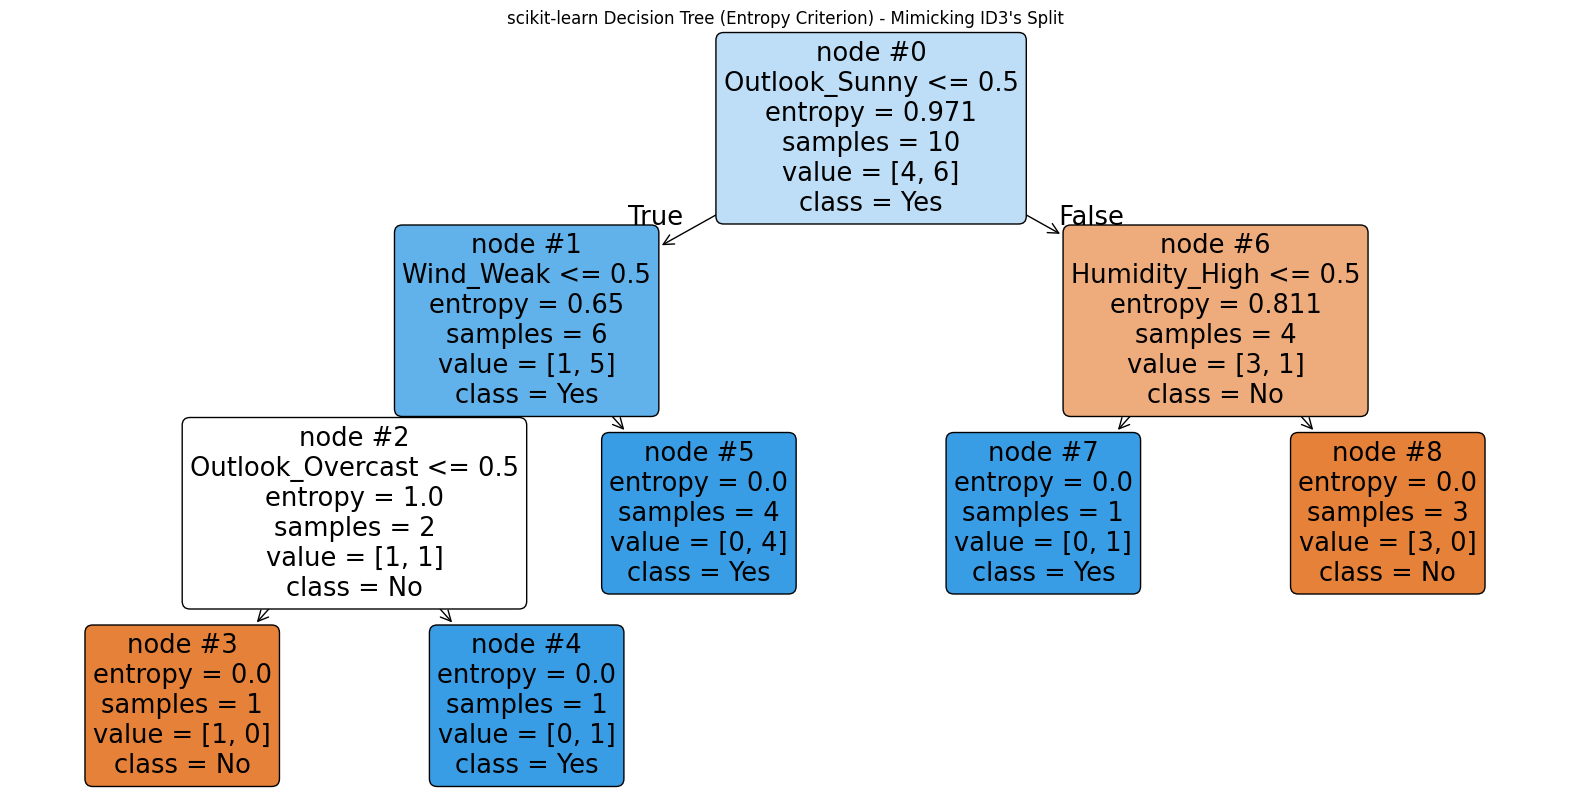


Observation: The scikit-learn tree uses binary splits even for categorical features (due to one-hot encoding) but prioritizes splits based on entropy reduction, conceptually aligned with ID3's core principle. The first split 'Outlook_Sunny <= 0.5' effectively tests if Outlook is Sunny.


In [43]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Re-using the calculate_entropy and calculate_information_gain functions
def calculate_entropy(labels):
    class_counts = Counter(labels)
    total_samples = len(labels)
    entropy = 0.0
    for count in class_counts.values():
        p_i = count / total_samples
        if p_i > 0:
            entropy -= p_i * np.log2(p_i)
    return entropy

def calculate_information_gain(data, feature_name, target_name):
    target_labels = data[target_name].tolist()
    parent_entropy = calculate_entropy(target_labels)

    feature_values = data[feature_name].unique()

    weighted_child_entropy = 0.0
    for value in feature_values:
        subset = data[data[feature_name] == value]
        subset_labels = subset[target_name].tolist()
        subset_entropy = calculate_entropy(subset_labels)
        weight = len(subset) / len(data)
        weighted_child_entropy += weight * subset_entropy

    information_gain = parent_entropy - weighted_child_entropy
    return information_gain

# --- Example Data (Play Tennis) ---
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)

# --- Simulate ID3's initial split logic ---

print("Calculating Information Gain for all features to find the best split:")
features = ['Outlook', 'Temperature', 'Humidity', 'Wind']

information_gains = {}
for feature in features:
    ig = calculate_information_gain(df, feature, 'PlayTennis')
    information_gains[feature] = ig
    print(f"  Information Gain for '{feature}': {ig:.4f} bits")

best_feature = max(information_gains, key=information_gains.get)
print(f"\nID3 would choose '{best_feature}' for the first split due to the highest Information Gain: {information_gains[best_feature]:.4f} bits")

# --- Using scikit-learn to visualize an entropy-based tree (approximating ID3's spirit) ---
# Note: scikit-learn's DecisionTreeClassifier is based on CART, which uses binary splits.
# For categorical features, it will create binary splits on one-hot encoded features.

# Prepare data for scikit-learn (one-hot encoding categorical features)
df_encoded = pd.get_dummies(df[features])
X = df_encoded
y = df['PlayTennis'].apply(lambda x: 1 if x == 'Yes' else 0)

# Train a Decision Tree Classifier with entropy criterion
# Limiting max_depth for better visualization of initial splits
id3_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
id3_tree.fit(X, y)

plt.figure(figsize=(20, 10))
plot_tree(id3_tree,
          feature_names=X.columns.tolist(),
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          impurity=True,
          node_ids=True
         )
plt.title("scikit-learn Decision Tree (Entropy Criterion) - Mimicking ID3's Split")
plt.show()

print("\nObservation: The scikit-learn tree uses binary splits even for categorical features (due to one-hot encoding) but prioritizes splits based on entropy reduction, conceptually aligned with ID3's core principle. The first split 'Outlook_Sunny <= 0.5' effectively tests if Outlook is Sunny.")

### 14. Questions

*   What is the primary splitting criterion used by the ID3 algorithm?
*   What is a major limitation of ID3 regarding feature types, and how is it typically addressed in practice?
*   How does ID3 prevent overfitting, or what measures need to be taken to prevent it?
*   Explain the bias of Information Gain towards features with many unique values in the context of ID3.

### 15. Summary

ID3 (Iterative Dichotomiser 3) is a foundational decision tree algorithm for classification that constructs trees by recursively selecting the categorical attribute with the highest Information Gain to make multi-way splits. Its simplicity and interpretability made it influential, clearly demonstrating the power of information theory in guiding tree construction. However, its limitations, such as handling only categorical features, susceptibility to overfitting, and a bias towards many-valued attributes, led to the development of more robust successors like C4.5 and CART.

### 16. Comparison with Previous Algorithms

*   **Vs. General Decision Tree Concepts (Overview):** ID3 concretely implements the theoretical concepts of Entropy and Information Gain discussed previously. It's the first specific algorithm that puts these mathematical foundations into practice for tree construction.

*   **Vs. Entropy/Information Gain:** ID3 is the *application* of Entropy and Information Gain. It's the algorithm that uses these metrics to make the actual decisions about tree structure. Without ID3 (or similar algorithms), Entropy and Information Gain would just be theoretical measures.

*   **Vs. Gini Impurity:** While Gini Impurity (and Gini Gain) serves the same purpose as Information Gain – to measure split quality – ID3 exclusively uses Information Gain. Algorithms like CART use Gini Impurity. The choice of metric can subtly influence the tree structure, with Information Gain potentially favoring more balanced splits and Gini Impurity being computationally faster.

## 7. CART

### 1. Definition

**CART (Classification and Regression Trees)** is a non-parametric decision tree algorithm introduced by Leo Breiman, Jerome Friedman, Richard Olshen, and Charles Stone in 1984. Unlike ID3, CART can handle both **classification** (where the target variable is categorical) and **regression** (where the target variable is numerical) tasks. A key characteristic of CART is that it produces **binary splits** (each node divides into exactly two child nodes), even for categorical features with multiple values. For classification, it typically uses **Gini Impurity** (or occasionally entropy), and for regression, it uses **Mean Squared Error (MSE)** or **Mean Absolute Error (MAE)** as its splitting criterion.

### 2. Why do we need it?

CART is one of the most widely used and influential decision tree algorithms, forming the basis for many modern ensemble methods (like Random Forests and Gradient Boosting Machines). We need to understand CART for several crucial reasons:

*   **Versatility:** It handles both classification and regression, making it applicable to a broader range of problems.
*   **Robustness:** Its binary splitting nature and ability to handle numerical features directly make it more robust and flexible than ID3.
*   **Foundation for Ensemble Methods:** `scikit-learn`'s `DecisionTreeClassifier` and `DecisionTreeRegressor` implementations are based on optimized versions of CART. Understanding CART is key to understanding how these fundamental `scikit-learn` models operate and how ensemble methods derive their power.
*   **Industry Standard:** It's the go-to algorithm for decision tree implementations in many libraries due to its balance of performance and interpretability.

### 3. Intuition

Imagine you're sorting a pile of diverse items (some big, some small, some red, some blue). Instead of making a multi-way split (e.g., creating a separate pile for each color), CART prefers to make a series of **yes/no questions**.

For example, instead of asking "What color is it?" (which might yield 'Red', 'Blue', 'Green' piles), CART would ask "Is it RED?" (creating a 'Yes, it's red' pile and a 'No, it's not red' pile). Then, for the 'No, it's not red' pile, it might ask "Is it BLUE?". This binary splitting simplifies the decision process at each step. For numerical data, it asks "Is `feature X` less than or equal to `value Y`?" (e.g., "Is `Age <= 30`?").

The algorithm iteratively searches for the binary split (feature and split-point) that best separates the data into more homogeneous groups, whether that homogeneity is measured by class purity (Gini Impurity) or by having similar output values (MSE).

### 4. Mathematical Foundation

CART's mathematical foundation depends on whether it's performing classification or regression:

*   **For Classification:**
    *   It typically uses **Gini Impurity** to measure the 'mixed-ness' of a node. The goal at each split is to maximize the **Gini Gain** (reduction in Gini Impurity). While it can also use entropy, Gini Impurity is generally the default due to computational efficiency.

*   **For Regression:**
    *   It uses metrics like **Mean Squared Error (MSE)** or **Mean Absolute Error (MAE)** to quantify the variability (or impurity) within a node. The goal at each split is to minimize the total squared error (or absolute error) of the child nodes, effectively maximizing the **reduction in variance**.

In both cases, CART employs a greedy search algorithm to find the optimal binary split that best improves the purity or reduces the variance of the resulting child nodes.

### 5. Formula

#### A. For Classification (using Gini Impurity - most common for CART):

**Gini Impurity (G)** for a dataset $S$ with $C$ classes:

$$ G(S) = 1 - \sum_{i=1}^{C} p_i^2 $$

Where $p_i$ is the proportion of samples belonging to class $i$ in the set $S$.

**Gini Gain (or decrease in Gini impurity)** for a split on attribute $A$ (with binary split point $k$):

$$ GiniGain(S, A_k) = G(S) - \left( \frac{|S_{left}|}{|S|} G(S_{left}) + \frac{|S_{right}|}{|S|} G(S_{right}) \right) $$

Where $S_{left}$ and $S_{right}$ are the two subsets created by the binary split $A_k$.

CART selects the $A_k$ that maximizes $GiniGain(S, A_k)$.

#### B. For Regression (using Mean Squared Error - most common for CART):

**Mean Squared Error (MSE)** for a dataset $S$ (at a node):

$$ MSE(S) = \frac{1}{|S|} \sum_{x \in S} (y_x - \bar{y}_S)^2 $$

Where $y_x$ is the target value for sample $x$, and $\bar{y}_S$ is the mean target value of all samples in $S$.

The splitting criterion for regression aims to minimize the weighted MSE of the child nodes. The reduction in MSE is sometimes referred to as **Variance Reduction** or **Reduction in Impurity for Regression**:

$$ Reduction(S, A_k) = MSE(S) - \left( \frac{|S_{left}|}{|S|} MSE(S_{left}) + \frac{|S_{right}|}{|S|} MSE(S_{right}) \right) $$

CART selects the $A_k$ that maximizes this reduction, i.e., minimizes the weighted sum of child MSEs.

### 6. Numerical Example

Let's revisit the 'Play Tennis' dataset for **Classification (using Gini Impurity)** to see how CART would select its first *binary* split. Note that CART typically creates binary splits even for multi-valued categorical features by grouping values.

**Dataset (same as before):**

| Outlook   | Temperature | Humidity | Wind   | PlayTennis |
|:----------|:------------|:---------|:-------|:-----------|
| Sunny     | Hot         | High     | Weak   | No         |
| Sunny     | Hot         | High     | Strong | No         |
| Overcast  | Hot         | High     | Weak   | Yes        |
| Rain      | Mild        | High     | Weak   | Yes        |
| Rain      | Cool        | Normal   | Weak   | Yes        |
| Rain      | Cool        | Normal   | Strong | No         |
| Overcast  | Cool        | Normal   | Strong | Yes        |
| Sunny     | Mild        | High     | Weak   | No         |
| Sunny     | Cool        | Normal   | Weak   | Yes        |
| Rain      | Mild        | Normal   | Weak   | Yes        |

Total samples = 10
`PlayTennis = Yes`: 6 samples
`PlayTennis = No`: 4 samples

**Initial Gini Impurity (Root Node):** $G(S) = 0.48$ (calculated in Gini Impurity section).

CART needs to consider all possible *binary* splits for each feature. For `Outlook` with values {Sunny, Overcast, Rain}, possible binary splits are:

1.  `Outlook = Sunny` vs. `Outlook != Sunny`
2.  `Outlook = Overcast` vs. `Outlook != Overcast`
3.  `Outlook = Rain` vs. `Outlook != Rain`

And for `Humidity`: `Humidity = High` vs. `Humidity = Normal`
And for `Wind`: `Wind = Weak` vs. `Wind = Strong`

Let's calculate the Gini Gain for `Outlook = Sunny` (i.e., splitting on `Outlook_Sunny` feature if one-hot encoded):

*   **Split: Outlook = Sunny (4 samples):**
    *   `Play Tennis = Yes`: 1, `Play Tennis = No`: 3
    *   $G(S_{Sunny}) = 1 - (1/4^2 + 3/4^2) = 0.375$

*   **Split: Outlook != Sunny (6 samples) [Overcast, Rain]:**
    *   `Play Tennis = Yes`: 5 (`Overcast:2`, `Rain:3`), `Play Tennis = No`: 1 (`Rain:1`)
    *   $G(S_{NotSunny}) = 1 - (5/6^2 + 1/6^2) = 1 - (25/36 + 1/36) = 1 - 26/36 = 1 - 0.722 = 0.278$

**Weighted Average Gini for `Outlook = Sunny` split:**
$= (4/10) G(S_{Sunny}) + (6/10) G(S_{NotSunny})$
$= (0.4 \times 0.375) + (0.6 \times 0.278) = 0.15 + 0.1668 = 0.3168$

**Gini Gain for `Outlook = Sunny`:**
$= 0.48 - 0.3168 = 0.1632$

(Compare this to the ID3 multi-way split for Outlook which gave IG $\approx 0.322$. Gini Gain values are generally smaller than Information Gain due to the formula differences, but the best feature remains the same. Also, ID3's splitting logic allows for multi-way splits for categorical features, whereas CART performs binary splits.)

CART would perform this for all possible binary splits (e.g., 'Outlook = Overcast' vs. 'Outlook != Overcast', 'Temperature = Hot' vs. 'Temperature != Hot', numerical feature thresholds like 'Age <= 30', etc.) and pick the one with the maximum Gini Gain for classification, or maximum variance reduction for regression.

### 7. Working (Step-by-Step)

CART builds a binary decision tree using a recursive partitioning approach:

1.  **Start at the Root Node:** The entire dataset $S$ is the root.

2.  **Evaluate All Possible Binary Splits:** For every feature, and for every possible binary split point:
    *   **For Classification:** Calculate the Gini Gain (or Information Gain) that would result from splitting $S$ into $S_{left}$ and $S_{right}$ based on that split point.
    *   **For Regression:** Calculate the reduction in MSE (or MAE) that would result from the split.

    *   **How to find split points:**
        *   **Categorical Features:** For a feature with $K$ categories, there are $2^{K-1}-1$ possible binary partitions. A simpler approach is to group categories. For a binary split, it often checks `feature = value` vs. `feature != value` for each unique value. In implementations like `scikit-learn` that rely on one-hot encoding, each binary encoded feature becomes a potential binary split (e.g., `Outlook_Sunny <= 0.5`).
        *   **Numerical Features:** Sort the unique values of the numerical feature. The midpoints between adjacent unique values are considered as potential split points (e.g., for values [10, 20, 30], potential splits are `feature <= 15` and `feature <= 25`).

3.  **Select the Best Split:** Choose the feature and split point that yields the maximum Gini Gain (or reduction in MSE).

4.  **Create Child Nodes:** Split the current node into two child nodes, $S_{left}$ and $S_{right}$, based on the selected best split.

5.  **Recursive Tree Building:** Apply steps 2-4 recursively to each child node. This continues until one of the stopping conditions is met:
    *   The node contains samples all belonging to the same class (for classification) or having very low variance (for regression).
    *   The node contains fewer samples than a predefined minimum (`min_samples_split`, `min_samples_leaf`).
    *   The tree reaches a predefined maximum depth (`max_depth`).
    *   The impurity reduction from any further split falls below a minimum threshold (`min_impurity_decrease`).

6.  **Assign Predictions:**
    *   **For Classification Leaf Node:** Assign the majority class of the samples in that leaf as the prediction.
    *   **For Regression Leaf Node:** Assign the average (mean) of the target values of the samples in that leaf as the prediction.

### 8. Visualization

A CART decision tree visualization emphasizes binary splits. Unlike ID3, which can have multiple branches emanating from a single node for a categorical feature, CART trees will always show two branches. Each internal node will have a condition (e.g., `feature <= value` or `feature = True`), leading to a 'True' branch and a 'False' branch.

## CART Decision Tree (Gini Impurity)

```text
                 Root Node
      Outlook_Sunny <= 0.5
          Gini = 0.48
               │
        ┌──────┴──────┐
        │             │
      True          False
        │             │
        ▼             ▼
  Outlook Not      Outlook
     Sunny          Sunny
  Gini = 0.278   Gini = 0.375
        │             │
        ▼             ▼
 Wind_Strong ?   Humidity_High ?
```

### Interpretation

- **Root Node**
  - Decision: `Outlook_Sunny <= 0.5`
  - Initial impurity: **Gini = 0.48**
  - The algorithm selected this split because it produced the greatest reduction in Gini impurity.

---

### Left Branch (True)

```text
Outlook_Sunny <= 0.5
        │
      True
        │
        ▼
Outlook Not Sunny
Gini = 0.278
        │
        ▼
Wind_Strong ?
```

- Represents all samples where **Outlook is not Sunny**.
- Gini impurity decreases from **0.48 → 0.278**, meaning this subset is more homogeneous.
- The next best split is **Wind_Strong**.

---

### Right Branch (False)

```text
Outlook_Sunny <= 0.5
        │
      False
        │
        ▼
Outlook = Sunny
Gini = 0.375
        │
        ▼
Humidity_High ?
```

- Represents all **Sunny** instances.
- Gini impurity decreases to **0.375**.
- Since the node is still impure, the next split is based on **Humidity_High**.

---

## Gini Impurity Reduction

```text
          Gini Impurity

0.50 ┤ ● Root (0.48)
     │
0.40 ┤                  ● Sunny (0.375)
     │
0.30 ┤      ● Not Sunny (0.278)
     │
0.20 ┤
     │
0.10 ┤
     │
0.00 ┤────────────────────────────────────► Tree Growth
```

### Key Observations

- The **Root Node** starts with a Gini impurity of **0.48**, indicating a mixed dataset.
- Splitting on **Outlook_Sunny** produces two subsets:
  - **Not Sunny** with **Gini = 0.278**
  - **Sunny** with **Gini = 0.375**
- Both child nodes are **more pure** than the parent, demonstrating that the split improves class separation.
- Since neither child is perfectly pure (**Gini ≠ 0**), CART continues recursively by splitting on **Wind_Strong** and **Humidity_High**.
- The algorithm repeats this process until a stopping criterion is met (maximum depth, minimum samples, or pure leaf nodes).

*(This conceptual Mermaid diagram shows how an initial binary split on a one-hot encoded 'Outlook' feature might look for CART. In `scikit-learn`'s `plot_tree`, you would see these binary splits explicitly.)*

We already saw an example of a `scikit-learn` tree plot in the ID3 section which implicitly followed CART's binary splitting rules (because `sklearn`'s `DecisionTreeClassifier` is a CART implementation). That plot demonstrated binary splits even for categorical features after one-hot encoding, and used entropy as the criterion. If we set `criterion='gini'`, the plot would be very similar but would show Gini Impurity values instead of entropy.

### 9. Hyperparameters

CART implementations, especially in libraries like `scikit-learn`, offer a rich set of hyperparameters to control the tree building process and prevent overfitting. These apply to both classification and regression trees:

*   **`criterion`**: The function to measure the quality of a split.
    *   **Classification:** `'gini'` (default, for Gini Impurity) or `'entropy'` (for Information Gain).
    *   **Regression:** `'squared_error'` (default, for Mean Squared Error), `'friedman_mse'`, `'absolute_error'` (for Mean Absolute Error), or `'poisson'` (for Poisson deviance).
*   **`splitter`**: The strategy used to choose the split at each node. `'best'` (default) selects the best split, `'random'` selects the best random split.
*   **`max_depth`**: The maximum depth of the tree. A crucial parameter to control overfitting.
*   **`min_samples_split`**: The minimum number of samples required to split an internal node.
*   **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node.
*   **`min_weight_fraction_leaf`**: The minimum weighted fraction of the sum total of weights (all the input samples) required to be at a leaf node.
*   **`max_features`**: The number of features to consider when looking for the best split. Useful for ensemble methods.
*   **`random_state`**: Controls the randomness of the estimator for reproducibility.
*   **`max_leaf_nodes`**: Grow a tree with `max_leaf_nodes` in a best-first fashion.
*   **`min_impurity_decrease`**: A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
*   **`ccp_alpha`**: Complexity parameter used for Minimal Cost-Complexity Pruning. Any subtreethat has a cost complexity larger than `ccp_alpha` will be pruned. This is important for post-pruning.

### 10. Advantages

*   **Handles Both Classification and Regression:** A significant advantage over ID3, making it highly versatile.
*   **Handles Numerical Features Directly:** Does not require discretization of numerical features, allowing for more precise split points.
*   **Binary Splits:** The uniform binary structure simplifies the tree's logic and makes it more compatible with ensemble methods.
*   **Robust and Widely Used:** Forms the backbone of many popular machine learning libraries and advanced ensemble techniques.
*   **Interpretability:** Like ID3, the resulting trees are easy to understand and visualize.
*   **No Data Preprocessing:** Does not require feature scaling or normalization.

### 11. Limitations

*   **Greedy Approach:** Still uses a greedy approach (local optimization), which does not guarantee a globally optimal tree.
*   **Prone to Overfitting:** Without proper pruning or hyperparameter tuning, CART trees can become very complex and overfit the training data.
*   **Instability:** Small changes in the data can lead to significantly different tree structures.
*   **Bias Towards Dominant Classes:** Can struggle with imbalanced datasets if not handled properly.
*   **Computational Cost for Optimal Splits:** Finding the optimal binary split for continuous variables requires sorting the feature values at each node, which can be computationally intensive, though optimized implementations mitigate this.
*   **Lack of Multi-Way Splits:** While not strictly a limitation for all cases, the forced binary split can sometimes lead to larger, more complex trees compared to multi-way splits for highly categorical features if not handled efficiently (e.g., through one-hot encoding).

### 12. Time Complexity

The time complexity for building a CART tree is similar to other decision tree algorithms, primarily driven by the search for the best split at each node:

*   **For Classification (with Gini/Entropy) and Regression (with MSE/MAE):**
    *   At each node, for each of the $M$ features, potential split points must be evaluated. If a feature is numerical, finding the optimal split point typically involves sorting the values for that feature, which takes $O(N \log N)$ time, where $N$ is the number of samples in the current node. For categorical features, evaluating all binary partitions can be complex, but optimized implementations often sort unique values and evaluate $O(N)$ splits.
    *   Thus, finding the best split for a single node takes approximately $O(M \cdot N \log N)$ (or $O(M \cdot N)$ with pre-sorting and certain optimizations).
    *   If the tree has a maximum depth $D$, the total time complexity for building the tree is approximately $O(M \cdot N \log N \cdot D)$ in the worst case, or more often closer to $O(M \cdot N \log N)$ for a well-tuned tree where $D$ is limited. The actual depth often scales as $O(\log N)$.

*   **Prediction:** Traversing the tree from the root to a leaf node takes $O(D)$ time, where $D$ is the depth of the tree. This is very efficient.

### 13. Python Implementation

`scikit-learn`'s `DecisionTreeClassifier` and `DecisionTreeRegressor` are highly optimized implementations of the CART algorithm. We've already seen `DecisionTreeClassifier` in action. Here, we'll explicitly use it for a classification task with `criterion='gini'` and demonstrate `DecisionTreeRegressor`.

--- CART for Classification (Gini Impurity) ---
Classification Tree Training Complete.


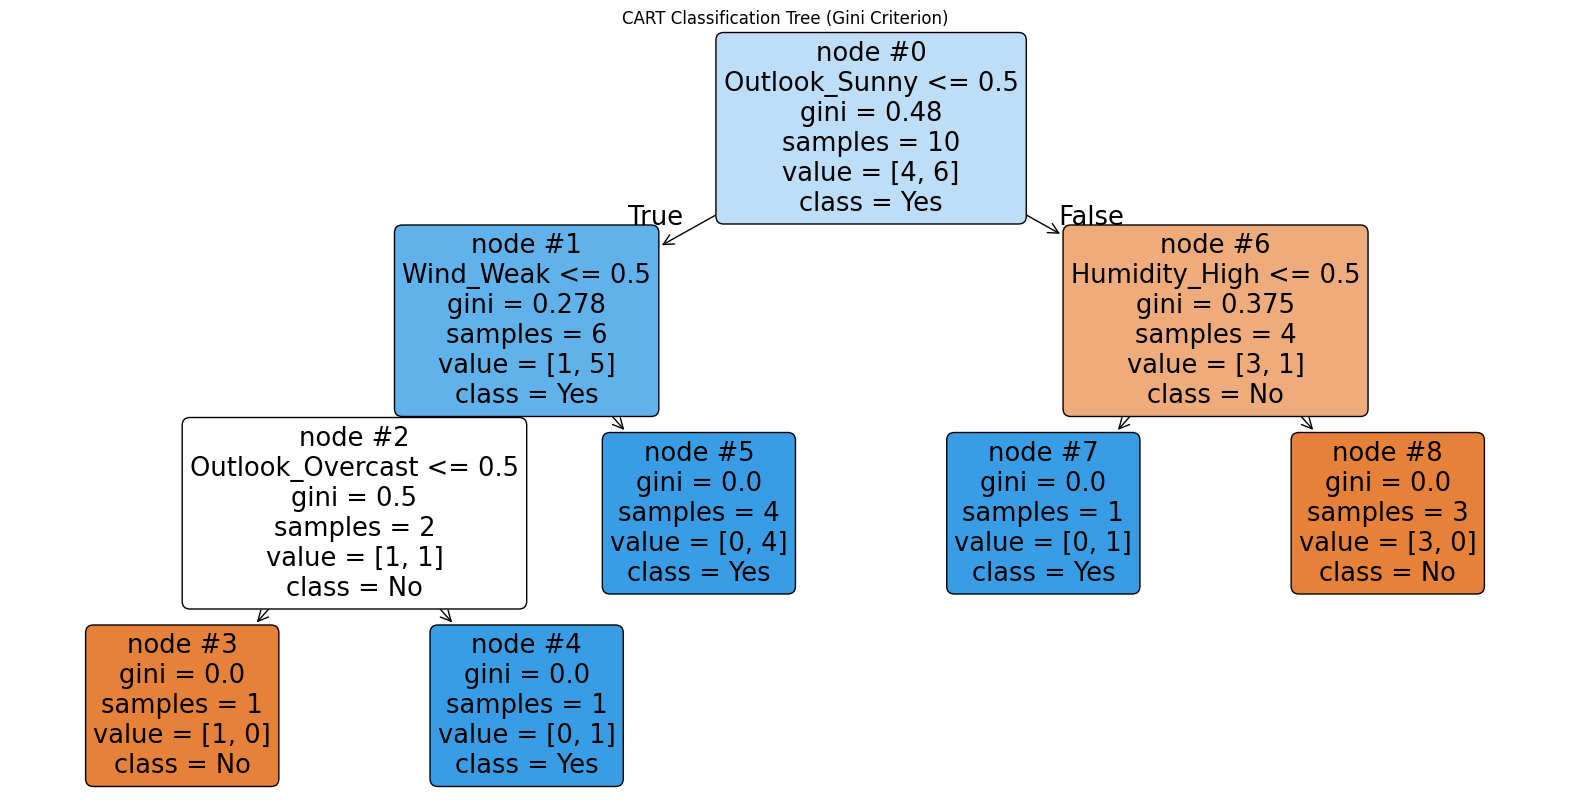


--- CART for Regression (Mean Squared Error) ---
Regression Tree Training Complete.
Regression Tree RMSE: 0.2228


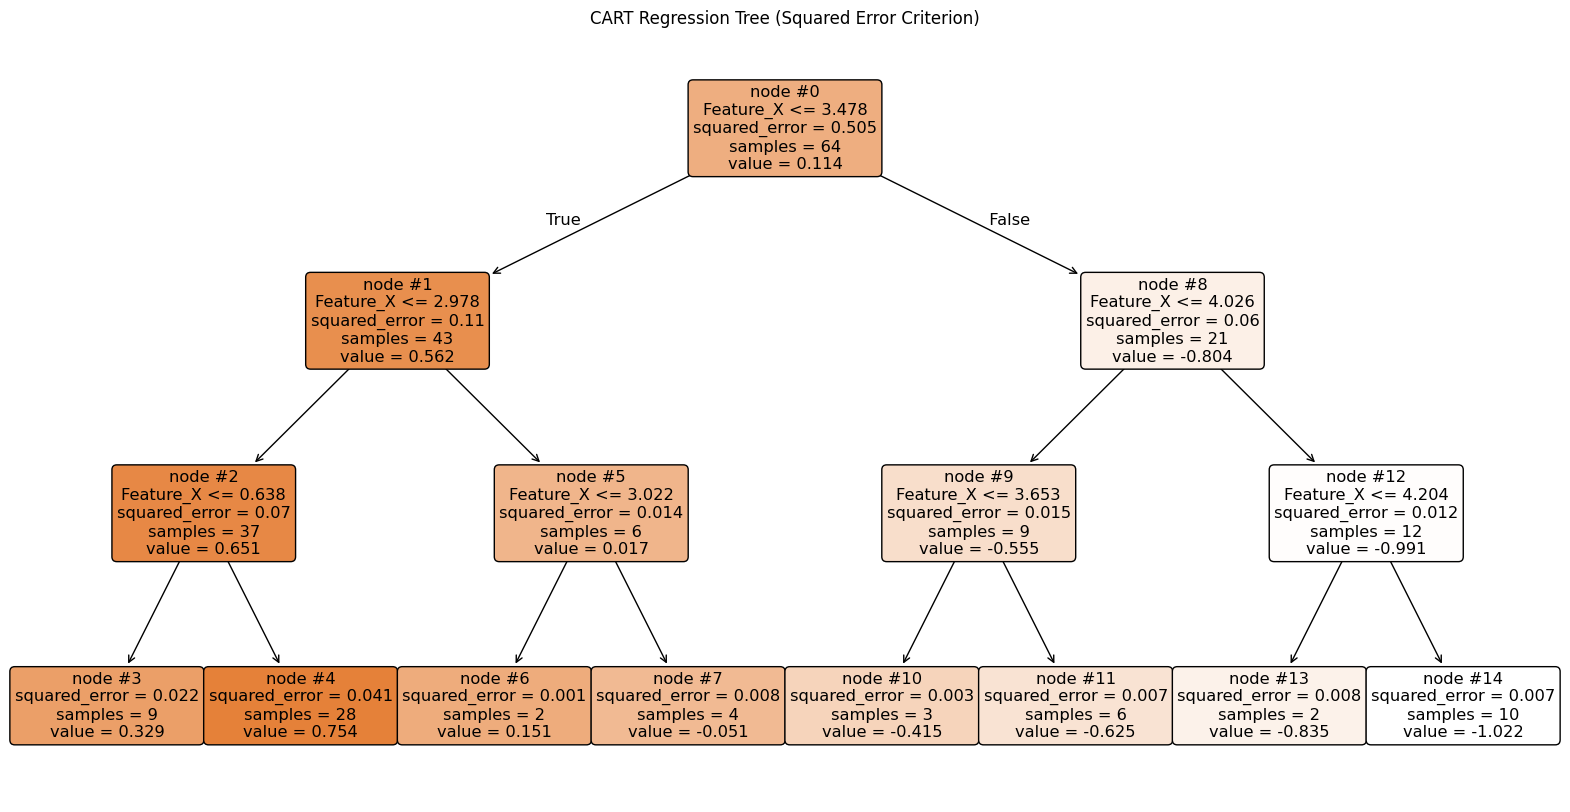

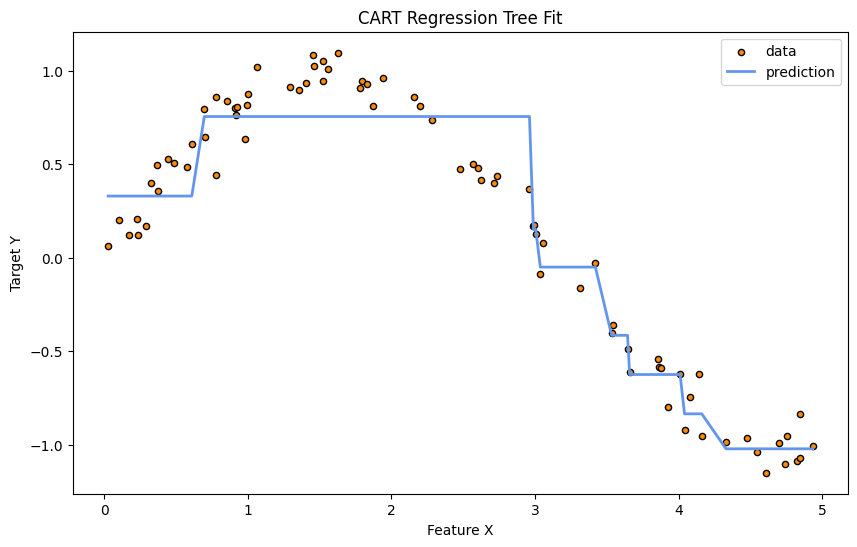

In [44]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt

# --- CART for Classification (using Gini Impurity) ---
print("--- CART for Classification (Gini Impurity) ---")

# Re-using the 'Play Tennis' data
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}
df_clf = pd.DataFrame(data)

# One-hot encode categorical features for sklearn (as it's a CART implementation)
X_clf = pd.get_dummies(df_clf[['Outlook', 'Temperature', 'Humidity', 'Wind']])
y_clf = df_clf['PlayTennis'].apply(lambda x: 1 if x == 'Yes' else 0) # Convert target to numerical

# Train a DecisionTreeClassifier with 'gini' criterion
# Limiting max_depth for better visualization of initial splits
cart_classifier = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
cart_classifier.fit(X_clf, y_clf)

print("Classification Tree Training Complete.")

plt.figure(figsize=(20, 10))
plot_tree(cart_classifier,
          feature_names=X_clf.columns.tolist(),
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          impurity=True,
          node_ids=True
         )
plt.title("CART Classification Tree (Gini Criterion)")
plt.show()

# --- CART for Regression (using Mean Squared Error) ---
print("\n--- CART for Regression (Mean Squared Error) ---")

# Create a synthetic dataset for regression
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0])

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train a DecisionTreeRegressor with 'squared_error' criterion
cart_regressor = DecisionTreeRegressor(criterion='squared_error', max_depth=3, random_state=42)
cart_regressor.fit(X_train_reg, y_train_reg)

print("Regression Tree Training Complete.")

# Make predictions and evaluate
y_pred_reg = cart_regressor.predict(X_test_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"Regression Tree RMSE: {rmse:.4f}")

# Plot the regression tree
plt.figure(figsize=(20, 10))
plot_tree(cart_regressor,
          feature_names=['Feature_X'],
          filled=True,
          rounded=True,
          impurity=True,
          node_ids=True
         )
plt.title("CART Regression Tree (Squared Error Criterion)")
plt.show()

# Plot actual vs. predicted for regression
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_reg, cart_regressor.predict(X_reg), color="cornflowerblue", linewidth=2, label="prediction")
plt.xlabel("Feature X")
plt.ylabel("Target Y")
plt.title("CART Regression Tree Fit")
plt.legend()
plt.show()


### 14. Questions

*   What is the main difference between CART and ID3 in terms of splitting?
*   How does CART handle numerical features for splitting, and what criterion does it use for regression tasks?
*   Explain why CART trees are always binary, even for categorical features with multiple categories.
*   What are some key advantages of CART over ID3?

### 15. Summary

CART (Classification and Regression Trees) is a highly versatile and widely used decision tree algorithm capable of handling both classification and regression problems. Its defining characteristic is the generation of binary splits at each node, regardless of the feature type. For classification, it predominantly uses Gini Impurity (or entropy) as its splitting criterion, while for regression, it minimizes Mean Squared Error (or Mean Absolute Error). CART's robustness, ability to handle numerical features directly, and its role as the foundation for modern ensemble methods make it a cornerstone of machine learning. Despite its greedy nature and susceptibility to overfitting without proper regularization, its balance of performance, interpretability, and flexibility ensures its continued importance.

### 16. Comparison with Previous Algorithms

*   **Vs. ID3:**
    *   **Feature Types:** CART handles both categorical and numerical features directly (ID3 handles only categorical). For numerical features, CART finds optimal split points. For categorical features, CART creates binary splits (e.g., `feature = 'A'` vs. `feature != 'A'`), whereas ID3 creates multi-way splits (one branch per category).
    *   **Splitting Criterion:** CART primarily uses Gini Impurity for classification (and MSE for regression), while ID3 uses Information Gain (based on Entropy). While both are impurity measures, Gini is computationally faster and less biased towards many-valued attributes than Information Gain.
    *   **Tree Structure:** CART builds strictly binary trees. ID3 can build multi-way trees for categorical features.
    *   **Regression:** CART supports regression tasks; ID3 does not.

*   **Vs. General Decision Tree Concepts (Overview):** CART brings the theoretical concepts of impurity measures (Gini, Entropy) and variance reduction (MSE) to a practical and highly implemented algorithm capable of real-world classification and regression. It concretizes many of the general concepts discussed previously, especially regarding splitting mechanisms for various data types.

## 8. Regression Tree

### 1. Definition

A **Regression Tree** is a type of decision tree that is used to predict a continuous target variable, as opposed to a categorical target variable (which is handled by a classification tree). It works by partitioning the feature space into a set of simpler, rectangular regions. For any given input, the prediction is the average (or median) of the target values of the training samples that fall into the same region (leaf node). Regression trees are a component of the CART (Classification and Regression Trees) algorithm when used for regression tasks.

### 2. Why do we need it?

We need Regression Trees when our goal is to predict a numerical quantity, such as house prices, stock values, temperature, or a person's age, based on a set of input features. While linear regression models can also predict continuous variables, Regression Trees offer several advantages:

*   **Non-linear Relationships:** They can model complex, non-linear relationships between features and the target variable without requiring manual feature engineering of non-linear terms.
*   **Feature Interactions:** They naturally capture interactions between features.
*   **No Feature Scaling:** Like classification trees, they do not require feature scaling or normalization.
*   **Interpretability:** They remain relatively easy to understand and visualize compared to many other non-linear models.
*   **Robustness:** They are robust to outliers and noisy data, as the splitting criteria focus on overall variance reduction rather than individual data points.
*   **Foundation for Ensembles:** They are essential building blocks for powerful ensemble methods like Random Forest Regressors and Gradient Boosting Regressors.

### 3. Intuition

Imagine you want to predict a student's final exam score based on their study hours, attendance, and previous quiz scores. A Regression Tree would work by asking a series of binary questions (like a flow chart) to narrow down to a group of similar students:

*   "Did they study more than 10 hours?" (Yes/No)
*   If Yes, "Was their attendance above 90%?" (Yes/No)
*   If Yes, "Was their average quiz score above 80?" (Yes/No)

Once it reaches a leaf node (a final group of similar students), it predicts the exam score for a new student by simply taking the **average exam score of all students in that group**. The tree builds itself by finding questions (splits) that best group students with similar exam scores together, minimizing the variability (e.g., standard deviation) within each group.

### 4. Mathematical Foundation

The mathematical foundation of Regression Trees differs from classification trees primarily in its impurity (or homogeneity) measure. Instead of Gini Impurity or Entropy, Regression Trees use metrics that quantify the **variance** or **spread** of the continuous target variable within a node.

The most common criteria are:

*   **Mean Squared Error (MSE):** Measures the average of the squares of the errors, where the error is the difference between the predicted value (mean of the node) and the actual value.
*   **Mean Absolute Error (MAE):** Measures the average of the absolute differences between the predicted value (median of the node) and the actual value.

The algorithm's greedy strategy is to select the split that results in the greatest **reduction in variance** (for MSE) or **reduction in MAE** across the resulting child nodes. This means it tries to create child nodes where the target values are as close as possible to each other.

### 5. Formula

For Regression Trees, the primary splitting criteria are typically Mean Squared Error (MSE) or Mean Absolute Error (MAE).

#### A. Mean Squared Error (MSE) - Most Common for CART Regressors:

**MSE for a dataset $S$ (at a node):**

$$ MSE(S) = \frac{1}{|S|} \sum_{x \in S} (y_x - \bar{y}_S)^2 $$

Where:
*   $S$ is the dataset (or node).
*   $|S|$ is the number of samples in $S$.
*   $y_x$ is the actual target value for sample $x$.
*   $\bar{y}_S$ is the mean of the target values of all samples in $S$. (This mean value is also the prediction for this node).

**Reduction in MSE (or Variance Reduction) for a split on attribute $A$ (with binary split point $k$):**

$$ Reduction(S, A_k) = MSE(S) - \left( \frac{|S_{left}|}{|S|} MSE(S_{left}) + \frac{|S_{right}|}{|S|} MSE(S_{right}) \right) $$

Where $S_{left}$ and $S_{right}$ are the two subsets created by the binary split $A_k$. The algorithm selects the split ($A_k$) that maximizes this reduction, effectively minimizing the weighted sum of child MSEs.

#### B. Mean Absolute Error (MAE):

**MAE for a dataset $S$ (at a node):**

$$ MAE(S) = \frac{1}{|S|} \sum_{x \in S} |y_x - \tilde{y}_S| $$

Where $\tilde{y}_S$ is the median of the target values of all samples in $S$. (The median value is the prediction for this node when using MAE criterion).

The reduction is calculated similarly to MSE, but using MAE: $Reduction(S, A_k) = MAE(S) - \left( \frac{|S_{left}|}{|S|} MAE(S_{left}) + \frac{|S_{right}|}{|S|} MAE(S_{right}) \right)$.

### 6. Numerical Example

Let's create a very simple numerical example for a regression tree with a single feature `X` and a target `Y`.

**Dataset:**

| X   | Y   |
|:----|:----|
| 1   | 10  |
| 2   | 12  |
| 3   | 11  |
| 4   | 20  |
| 5   | 22  |
| 6   | 21  |
| 7   | 30  |
| 8   | 32  |
| 9   | 31  |
| 10  | 40  |

Total samples = 10
Mean of Y ($\bar{y}_S$) = $(10+12+11+20+22+21+30+32+31+40) / 10 = 22.9$

**Step 1: Calculate Initial MSE for the Root Node.**

$MSE(S) = \frac{1}{10} \sum (y_i - 22.9)^2$
$MSE(S) = \frac{1}{10} [ (10-22.9)^2 + (12-22.9)^2 + (11-22.9)^2 + (20-22.9)^2 + (22-22.9)^2 + (21-22.9)^2 + (30-22.9)^2 + (32-22.9)^2 + (31-22.9)^2 + (40-22.9)^2 ]$
$MSE(S) = \frac{1}{10} [ (-12.9)^2 + (-10.9)^2 + (-11.9)^2 + (-2.9)^2 + (-0.9)^2 + (-1.9)^2 + (7.1)^2 + (9.1)^2 + (8.1)^2 + (17.1)^2 ]$
$MSE(S) = \frac{1}{10} [ 166.41 + 118.81 + 141.61 + 8.41 + 0.81 + 3.61 + 50.41 + 82.81 + 65.61 + 292.41 ]$
$MSE(S) = \frac{1}{10} [ 930.9 ] = 93.09$

**Step 2: Evaluate a potential split, e.g., $X \le 5.5$.**

This split would divide the dataset into two subsets:

*   **$S_{left}$ (X $\le$ 5.5):** Samples with X = {1, 2, 3, 4, 5}. Y = {10, 12, 11, 20, 22}
    *   $|S_{left}| = 5$
    *   Mean($\bar{y}_{left}$) = $(10+12+11+20+22)/5 = 75/5 = 15$
    *   $MSE(S_{left}) = \frac{1}{5} [ (10-15)^2 + (12-15)^2 + (11-15)^2 + (20-15)^2 + (22-15)^2 ]$
    *   $MSE(S_{left}) = \frac{1}{5} [ (-5)^2 + (-3)^2 + (-4)^2 + (5)^2 + (7)^2 ]$
    *   $MSE(S_{left}) = \frac{1}{5} [ 25 + 9 + 16 + 25 + 49 ] = \frac{1}{5} [ 124 ] = 24.8$

*   **$S_{right}$ (X $>$ 5.5):** Samples with X = {6, 7, 8, 9, 10}. Y = {21, 30, 32, 31, 40}
    *   $|S_{right}| = 5$
    *   Mean($\bar{y}_{right}$) = $(21+30+32+31+40)/5 = 154/5 = 30.8$
    *   $MSE(S_{right}) = \frac{1}{5} [ (21-30.8)^2 + (30-30.8)^2 + (32-30.8)^2 + (31-30.8)^2 + (40-30.8)^2 ]$
    *   $MSE(S_{right}) = \frac{1}{5} [ (-9.8)^2 + (-0.8)^2 + (1.2)^2 + (0.2)^2 + (9.2)^2 ]$
    *   $MSE(S_{right}) = \frac{1}{5} [ 96.04 + 0.64 + 1.44 + 0.04 + 84.64 ] = \frac{1}{5} [ 182.8 ] = 36.56$

**Step 3: Calculate the Weighted Average MSE of Child Nodes.**

Weighted Avg MSE = $\frac{|S_{left}|}{|S|} MSE(S_{left}) + \frac{|S_{right}|}{|S|} MSE(S_{right})$
Weighted Avg MSE = $\frac{5}{10} (24.8) + \frac{5}{10} (36.56) = 0.5 \times 24.8 + 0.5 \times 36.56$
Weighted Avg MSE = $12.4 + 18.28 = 30.68$

**Step 4: Calculate Reduction in MSE (Variance Reduction) for the split.**

Reduction = $MSE(S) - \text{Weighted Avg MSE}$
Reduction = $93.09 - 30.68 = 62.41$

The algorithm would perform this for all possible split points for feature X (e.g., X <= 1.5, X <= 2.5, ..., X <= 9.5) and choose the split that maximizes this reduction in MSE. For this simple example, $X \le 5.5$ gave a significant reduction, creating much more homogeneous groups.

### 7. Working (Step-by-Step)

Building a Regression Tree follows a similar recursive partitioning approach as classification trees, but with different impurity measures:

1.  **Start at the Root Node:** The entire dataset $S$ is the root node.

2.  **Calculate Impurity (Variance/Error):** Calculate the variance or error (e.g., MSE) of the target variable for the current node.

3.  **Evaluate All Possible Binary Splits:** For every feature and for every potential binary split point (for numerical features, consider midpoints between unique values; for categorical features, consider combinations of categories):
    *   Divide the current node's data into two subsets: $S_{left}$ and $S_{right}$.
    *   For each subset, calculate the mean (or median) of the target variable. This mean (or median) will be the predicted value if this subset becomes a leaf node.
    *   Calculate the impurity (MSE or MAE) for each of these child subsets.
    *   Calculate the **Reduction in Impurity** (e.g., reduction in MSE) that would result from this split. This is analogous to Information Gain for classification trees.

4.  **Select the Best Split:** Choose the feature and split point that yields the maximum reduction in impurity.

5.  **Create Child Nodes:** Split the current node into two child nodes, $S_{left}$ and $S_{right}$, based on the selected best split.

6.  **Recursive Tree Building:** Apply steps 2-5 recursively to each child node. This continues until one of the stopping conditions is met:
    *   The variance (or MAE) of the target variable within a node falls below a predefined threshold.
    *   The node contains fewer samples than a predefined minimum (`min_samples_split`, `min_samples_leaf`).
    *   The tree reaches a predefined maximum depth (`max_depth`).
    *   The impurity reduction from any further split falls below a minimum threshold (`min_impurity_decrease`).

7.  **Assign Predictions to Leaf Nodes:** Once a node becomes a leaf node, its predicted value for any new input falling into that node is the **average (mean)** of the target values of all training samples within that leaf node (if using MSE criterion), or the **median** (if using MAE criterion).

### 8. Visualization

Regression tree visualizations show the binary splits, just like classification trees. However, instead of class distributions and Gini/Entropy, internal nodes display the `squared_error` (or `absolute_error`) and the predicted `value` (the mean/median of the target). Leaf nodes will show the final predicted value.

We have already seen a visual representation of a CART Regression Tree in the previous CART section's Python implementation. The `plot_tree` output for the `cart_regressor` clearly demonstrated:

*   **Binary Splits:** Each node divides into two branches (e.g., `feature_X <= 3.478`).
*   **Splitting Criterion:** Each node shows `squared_error` as its impurity measure.
*   **Predicted Value:** Each node (especially leaf nodes) shows `value` which is the mean of the target variable for samples in that node.
*   **Region Partitioning:** The scatter plot of actual vs. predicted values beautifully illustrates how the regression tree partitions the continuous feature space into rectangular regions, with each region having a constant predicted value.

```text
                Root
        squared_error = 0.505
            value = 0.114
                  │
                  ▼
        Feature_X <= 3.478 ?
             /            \
        True              False
         /                  \
        ▼                    ▼
 ┌────────────────┐   ┌────────────────┐
 │ Child Node     │   │ Child Node     │
 │ squared_error  │   │ squared_error  │
 │ = 0.110        │   │ = 0.060        │
 │ value = 0.562  │   │ value = -0.804 │
 └────────────────┘   └────────────────┘
         │                    │
         ▼                    ▼
 Feature_X <= 2.978?   Feature_X <= 4.204?
       /      \
   True        False
    │            │
    ▼            ▼
┌───────────┐ ┌───────────┐
│ Leaf      │ │ Leaf      │
│ sq_err    │ │ sq_err    │
│ = 0.014   │ │ = 0.015   │
│ value     │ │ value     │
│ = 0.651   │ │ = 0.151   │
└───────────┘ └───────────┘
```

*(This Mermaid diagram represents a conceptual segment of a regression tree, similar to what was generated in the Python output for `CART Regression Tree (Squared Error Criterion)`. It highlights how predictions (values) are constant within each leaf node.)*

### 9. Hyperparameters

Regression Trees share many hyperparameters with classification trees, as both are generally implemented under the CART framework. The key difference lies in the `criterion` parameter and how impurity/error is measured.

*   **`criterion`**: The function to measure the quality of a split.
    *   `'squared_error'` (default in `scikit-learn` for `DecisionTreeRegressor`): Uses Mean Squared Error. The prediction value at a leaf node is the mean of the target values in that node.
    *   `'friedman_mse'`: Similar to MSE but uses an improved version for certain cases.
    *   `'absolute_error'` (for Mean Absolute Error): The prediction value at a leaf node is the median of the target values in that node.
    *   `'poisson'`: Uses Poisson deviance, useful for count data.
*   **`max_depth`**: Maximum depth of the tree. Crucial for controlling complexity and preventing overfitting.
*   **`min_samples_split`**: Minimum number of samples required to split an internal node.
*   **`min_samples_leaf`**: Minimum number of samples required to be at a leaf node.
*   **`min_weight_fraction_leaf`**: Minimum weighted fraction of the total samples required to be at a leaf node.
*   **`max_features`**: Number of features to consider when looking for the best split.
*   **`random_state`**: For reproducibility of results.
*   **`min_impurity_decrease`**: A node will be split if the split induces a decrease of the impurity (e.g., MSE reduction) greater than or equal to this value.
*   **`ccp_alpha`**: Complexity parameter for cost-complexity pruning (post-pruning strategy).

### 10. Advantages

*   **Non-linear Modeling:** Excellent at capturing complex, non-linear relationships in data.
*   **Feature Interactions:** Automatically models interactions between features.
*   **Interpretability:** Easy to understand and visualize, especially for smaller trees.
*   **No Scaling Required:** Insensitive to the scaling of numerical features.
*   **Handles Mixed Data Types:** Can work with both numerical and categorical features (after appropriate encoding for categorical ones).
*   **Basis for Ensembles:** Forms the core of highly accurate and robust ensemble methods like Random Forests and Gradient Boosting for regression tasks.
*   **Predictive Regions:** Divides the feature space into interpretable rectangular regions, with a constant prediction within each region.

### 11. Limitations

*   **Prone to Overfitting:** Without careful tuning of hyperparameters (`max_depth`, `min_samples_leaf`, etc.) or pruning, deep regression trees can easily overfit the training data, leading to poor generalization.
*   **Lack of Smoothness:** The step-wise constant predictions (mean/median in leaf nodes) result in predictions that are not smooth, which might not be desirable for some applications.
*   **Instability:** Small changes in the input data can lead to a significantly different tree structure.
*   **Bias:** Greedy nature means local optima are found, not necessarily a globally optimal tree.
*   **Extrapolation Issues:** Regression trees cannot predict values outside the range of the target variable in the training data, as predictions are always an average/median of observed values.

### 12. Time Complexity

The time complexity for building a Regression Tree is largely similar to that of a Classification Tree, as both use the CART algorithm's underlying search mechanism to find optimal binary splits:

*   **Training:** At each node, for each feature, the algorithm evaluates potential split points. For numerical features, this often involves sorting the values. The complexity is approximately $O(M \cdot N \log N \cdot D)$ in the worst case, where $M$ is the number of features, $N$ is the number of samples, and $D$ is the tree depth. Optimized implementations can bring this closer to $O(M \cdot N \log N)$ by pre-sorting features.
*   **Prediction:** Predicting the value for a new sample involves traversing the tree from the root to a leaf node. This is very efficient, typically $O(D)$ or $O(\log N)$ for a balanced tree.

### 13. Python Implementation

We already demonstrated the `scikit-learn`'s `DecisionTreeRegressor` in the previous CART section. We will re-run that part of the code here for completeness and to clearly focus on the regression aspect, showing how it is used to fit a non-linear dataset.

--- Regression Tree (Mean Squared Error Criterion) ---
Regression Tree Training Complete.
Test Set RMSE: 0.2228


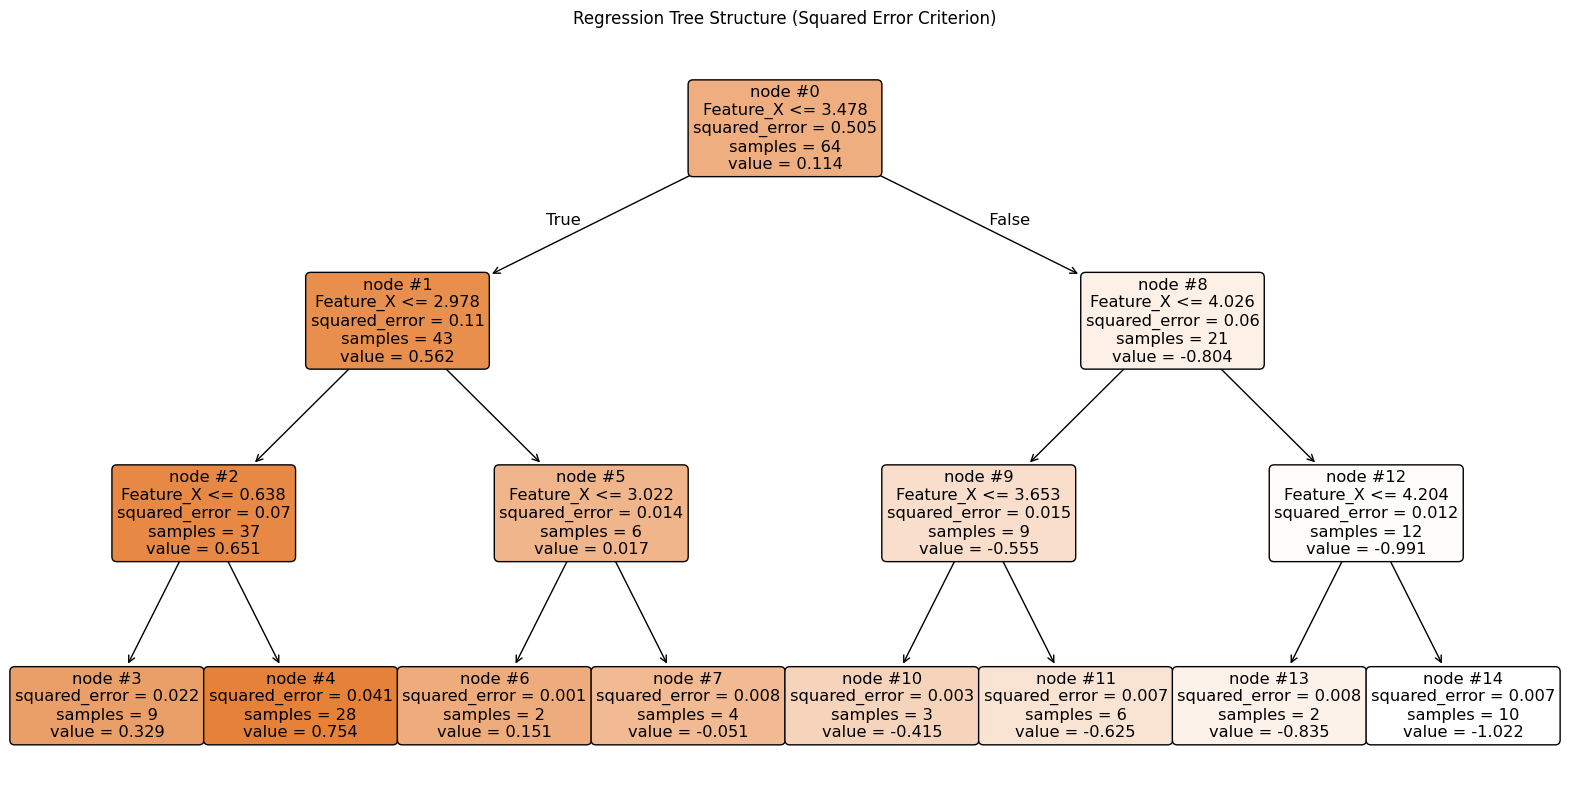

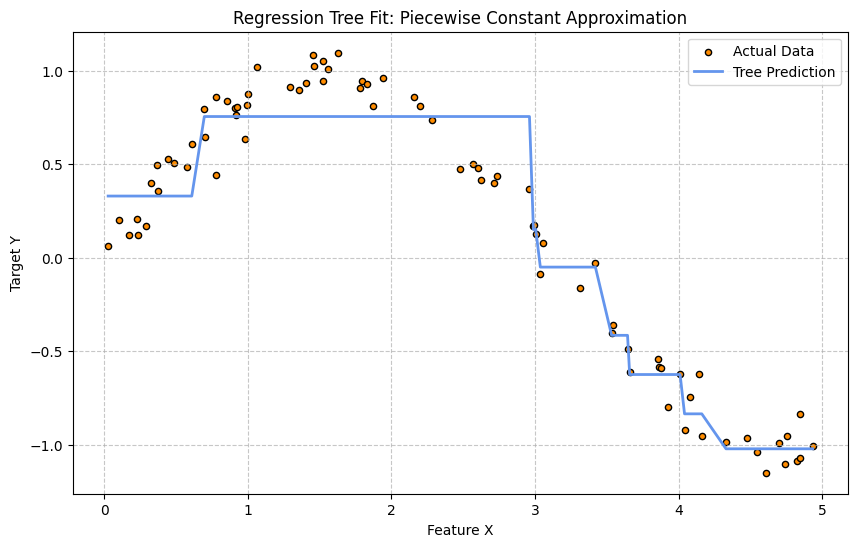

In [45]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

print("--- Regression Tree (Mean Squared Error Criterion) ---")

# Create a synthetic dataset for regression
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0) # Feature X
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0]) # Target Y with some noise

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train a DecisionTreeRegressor with 'squared_error' criterion
# Limiting max_depth for better visualization and to prevent severe overfitting
cart_regressor = DecisionTreeRegressor(criterion='squared_error', max_depth=3, random_state=42)
cart_regressor.fit(X_train_reg, y_train_reg)

print("Regression Tree Training Complete.")

# Make predictions on the test set and evaluate performance
y_pred_reg = cart_regressor.predict(X_test_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"Test Set RMSE: {rmse:.4f}")

# Make predictions on the entire range of X for plotting the fit
y_full_pred = cart_regressor.predict(X_reg)

# Plot the Regression Tree structure
plt.figure(figsize=(20, 10))
plot_tree(cart_regressor,
          feature_names=['Feature_X'], # Name of the feature
          filled=True, # Color nodes to indicate majority class/mean value
          rounded=True, # Round node boxes
          impurity=True, # Show impurity (squared_error in this case)
          node_ids=True # Show node IDs
         )
plt.title("Regression Tree Structure (Squared Error Criterion)")
plt.show()

# Plot actual vs. predicted for regression to visualize the piecewise constant fit
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, s=20, edgecolor="black", c="darkorange", label="Actual Data")
plt.plot(X_reg, y_full_pred, color="cornflowerblue", linewidth=2, label="Tree Prediction")
plt.xlabel("Feature X")
plt.ylabel("Target Y")
plt.title("Regression Tree Fit: Piecewise Constant Approximation")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 14. Questions

*   What is the primary difference in the splitting criterion between a Classification Tree and a Regression Tree?
*   How does a Regression Tree make predictions at a leaf node?
*   Can a Regression Tree extrapolate, i.e., predict values beyond the range seen in the training data? Explain why or why not.
*   What hyperparameters are crucial for preventing overfitting in Regression Trees?

### 15. Summary

A Regression Tree is a specialized decision tree designed for predicting continuous numerical values. It operates by recursively partitioning the feature space into distinct regions, and for any new data point, it predicts the mean (or median) target value of the training samples within its corresponding leaf region. Key to its construction are impurity measures like Mean Squared Error (MSE) or Mean Absolute Error (MAE), which guide the algorithm to find splits that maximize the reduction in variance. Regression trees are powerful for modeling non-linear relationships and feature interactions and serve as fundamental components of advanced ensemble regression methods. While interpretable and robust, they require careful hyperparameter tuning to avoid overfitting and cannot extrapolate beyond the training data range.

### 16. Comparison with Previous Algorithms

*   **Vs. Classification Trees (ID3, CART Classification):**
    *   **Target Variable:** Classification trees predict categorical labels; Regression trees predict continuous values.
    *   **Splitting Criterion:** Classification trees use Gini Impurity or Entropy (Information Gain); Regression trees use Mean Squared Error or Mean Absolute Error (Variance Reduction).
    *   **Leaf Node Prediction:** Classification leaves predict the majority class; Regression leaves predict the mean/median target value.
    *   **Output:** Classification trees output discrete classes; Regression trees output continuous numbers (though in a piecewise constant manner).

*   **Vs. Linear Regression:**
    *   **Model Form:** Linear Regression assumes a linear relationship between features and target. Regression Trees can model highly non-linear relationships.
    *   **Interpretability:** Both can be interpretable, but Regression Trees offer a visual, rule-based interpretation, while Linear Regression provides feature weights.
    *   **Feature Scaling:** Linear Regression often requires feature scaling; Regression Trees do not.
    *   **Extrapolation:** Linear Regression can extrapolate (sometimes poorly). Regression Trees cannot, as their predictions are limited to the range of values in the training data's leaf nodes.

*   **Vs. CART (general):** Regression Trees are essentially the 'Regression' mode of the CART algorithm. They leverage the same binary splitting mechanism and recursive partitioning but apply different cost functions (MSE/MAE instead of Gini/Entropy) and prediction methods at the leaf nodes.

## 9. Pruning

### 1. Definition

**Pruning** in the context of decision trees is a technique used to reduce the size of decision trees by removing sections of the tree that provide little power to classify instances. It is primarily used to address the problem of **overfitting**, where a tree becomes too complex and learns the training data too well, leading to poor generalization performance on unseen data. By removing branches, pruning simplifies the tree, making it more interpretable and often improving its accuracy on new data.

There are two main types of pruning:
*   **Pre-pruning (or Early Stopping):** Stopping the tree construction process prematurely.
*   **Post-pruning:** Growing a full tree first, and then removing branches and nodes.

### 2. Why do we need it?

We need pruning primarily to combat **overfitting** in decision trees. Without pruning, a decision tree can grow to full depth, creating very specific rules that perfectly fit the training data, including noise and outliers. This results in a highly complex tree that:

*   **Performs poorly on unseen data:** It memorizes the training examples rather than learning general patterns.
*   **Is less interpretable:** A deep, bushy tree is difficult for humans to understand and explain.
*   **Is computationally more expensive:** Larger trees take more memory and time for both training and prediction.

Pruning helps to generalize the model, improve its predictive accuracy on new data, and maintain interpretability.

### 3. Intuition

Imagine you are writing a very detailed instruction manual. If you include every single edge case and exception, your manual becomes incredibly long, hard to read, and might even be confusing because it tries to cover too much, some of which might be irrelevant or rare.

**A decision tree without pruning** is like such an overly detailed manual. It captures every nuance of the training data, down to the smallest detail (noise). While it perfectly 'explains' the training data, it fails when presented with a slightly different situation (new data) because its rules are too specific.

**Pruning** is like an editor reviewing your manual. The editor removes unnecessary details, simplifies complex sentences, and consolidates sections. The goal isn't to make the manual less accurate for its core purpose, but to make it more concise, easier to understand, and more broadly applicable, even if it means losing some minor, very specific details. The edited manual might not be 'perfect' for every single obscure case, but it will be much more effective for the vast majority of users.

### 4. Mathematical Foundation

The mathematical foundation of pruning involves trade-offs between model complexity and accuracy. While growing a tree, the algorithm tries to maximize impurity reduction (e.g., Information Gain or Gini Gain for classification, MSE reduction for regression). Pruning introduces a penalty for complexity.

For **post-pruning**, a common technique is **Cost-Complexity Pruning (also known as Weakest Link Pruning or Alpha Pruning)**, which is based on minimizing a cost function that balances the tree's error rate on the training data with its complexity.

The cost function for a tree $T$ is typically defined as:

$$ C_{\alpha}(T) = R(T) + \alpha \cdot |\tilde{T}| $$

Where:
*   $R(T)$ is the error rate (e.g., misclassification rate for classification, sum of squared residuals for regression) of the tree $T$ on the training data.
*   $|\tilde{T}|$ is the number of leaf nodes in the tree $T$ (a measure of its complexity).
*   $\alpha$ (alpha) is the **complexity parameter**, a non-negative value that controls the trade-off between the tree's error and its number of leaf nodes. A higher $\alpha$ leads to more pruning (simpler trees).

The goal of cost-complexity pruning is to find the subtree of the original full tree that minimizes $C_{\alpha}(T)$ for a given $\alpha$.

### 5. Formula

As discussed, the core formula is for **Cost-Complexity Pruning**:

$$ C_{\alpha}(T) = R(T) + \alpha \cdot |\tilde{T}| $$

Let's break down how $R(T)$ and $|\tilde{T}|$ are calculated:

**For Classification Trees:**
*   $R(T)$ = Total training misclassification error (e.g., sum of misclassified samples in all leaf nodes).
*   Alternatively, it can be the weighted sum of impurity (Gini or Entropy) of all leaf nodes.

**For Regression Trees:**
*   $R(T)$ = Total sum of squared residuals (SSR) from all leaf nodes. ($SSR = \sum_{leaf \in \tilde{T}} \sum_{x \in leaf} (y_x - \bar{y}_{leaf})^2$)

**For any subtree $T_t$ rooted at node $t$:**

We compare the cost of keeping node $t$ as a leaf versus splitting it further into a subtree. If node $t$ were a leaf, its error would be $R(t)$. If it's split into a subtree $T_t$, its error would be $R(T_t)$.

We prune branches that provide less improvement than the cost of their complexity. A branch $T_t$ (subtree rooted at node $t$) is pruned if:

$$ R(t) < R(T_t) + \alpha \cdot (|\tilde{T}_t| - 1) $$

where $|\tilde{T}_t|$ is the number of leaf nodes in the subtree $T_t$. The term $(|\tilde{T}_t| - 1)$ represents the increase in complexity if we keep the subtree $T_t$ instead of pruning node $t$ to be a leaf.

This formula helps find the 'weakest link' (the subtree that offers the least reduction in error per unit of complexity) at each step of the pruning process for a given $\alpha$.

### 6. Numerical Example

Let's consider a simplified post-pruning example with cost-complexity pruning.

Suppose we have a portion of a decision tree:

*   **Node `t` (Parent Node):** Has 10 samples, 7 'Yes', 3 'No'.
    *   If `t` were a leaf, its misclassification error $R(t)$ would be 3 (since 3 'No' samples would be misclassified if we predict 'Yes').

*   **Subtree $T_t$ (rooted at node `t`):** This subtree has two child nodes, `t_left` and `t_right`.
    *   **Node `t_left` (Leaf):** Has 6 samples, 6 'Yes', 0 'No'. Error $R(t_{left}) = 0$. (Pure leaf)
    *   **Node `t_right` (Leaf):** Has 4 samples, 1 'Yes', 3 'No'. Error $R(t_{right}) = 1$. (Predict 'No', 1 'Yes' misclassified)

    *   The subtree $T_t$ has 2 leaf nodes ($|\tilde{T}_t| = 2$).
    *   The error of the subtree $R(T_t) = R(t_{left}) + R(t_{right}) = 0 + 1 = 1$.

Now, let's apply the pruning condition. We are comparing pruning node `t` (making it a leaf) versus keeping the subtree $T_t$.

We prune node `t` to be a leaf if:

$$ R(t) < R(T_t) + \alpha \cdot (|\tilde{T}_t| - 1) $$

Substitute the values:

$$ 3 < 1 + \alpha \cdot (2 - 1) $$
$$ 3 < 1 + \alpha \cdot 1 $$
$$ 3 - 1 < \alpha $$
$$ 2 < \alpha $$

**Conclusion:**
*   If $\alpha$ is greater than 2, it means the penalty for complexity is high enough that we prefer the simpler tree where node `t` is a leaf (misclassification error of 3) over the more complex subtree (misclassification error of 1 but with 2 leaves). In this case, we would prune the subtree and make `t` a leaf node.
*   If $\alpha$ is less than or equal to 2, we would keep the subtree because the reduction in error (from 3 to 1) is worth the added complexity.

This calculation helps identify the optimal $\alpha$ values at which pruning should occur, and is iteratively applied to the entire tree.

### 7. Working (Step-by-Step)

#### A. Pre-pruning (Early Stopping)

Pre-pruning involves stopping the tree building process before it has fully grown. This is typically controlled by hyperparameters. The algorithm works as follows:

1.  **Start Tree Building:** Begin constructing the decision tree as usual, selecting splits based on impurity measures (Gini/Entropy/MSE).
2.  **Check Stopping Conditions:** At each step, before making a split, check if any of the following conditions are met:
    *   **`max_depth`:** The current depth of the tree reaches the specified maximum depth.
    *   **`min_samples_split`:** The number of samples in the current node is less than the minimum required to make a split.
    *   **`min_samples_leaf`:** Any potential split would result in a child node having fewer samples than the minimum required for a leaf.
    *   **`min_impurity_decrease`:** The potential gain from splitting (e.g., Information Gain, Gini Gain, MSE reduction) is below a specified threshold.
3.  **Stop or Continue:** If any stopping condition is met, stop growing the branch and make the current node a leaf node. Otherwise, continue splitting.

#### B. Post-pruning (Cost-Complexity Pruning - as implemented in `scikit-learn`)

Post-pruning involves growing a full tree first and then pruning it back. This is often more effective than pre-pruning because it allows the algorithm to see the full structure and then decide which branches are genuinely weak.

1.  **Grow Full Tree:** Build the complete decision tree to its maximum possible depth, ensuring all leaf nodes are pure or contain very few samples (i.e., until further splits yield no impurity decrease or meet `min_samples_leaf` implicitly).
2.  **Identify Subtrees:** Generate a sequence of nested subtrees by iteratively collapsing the 'weakest' internal node (i.e., the node that, if pruned, results in the smallest increase in the cost-complexity measure for some $\alpha$). This process generates a path of optimal subtrees as $\alpha$ increases from 0.
3.  **Calculate Effective Alphas:** For each internal node `t`, calculate the effective $\alpha$ value that balances the error reduction of its subtree $T_t$ with its complexity:
    $$\alpha_{effective}(t) = \frac{R(t) - R(T_t)}{|\tilde{T}_t| - 1}$$
    The algorithm finds a sequence of increasing $\alpha$ values by considering the $\alpha_{effective}$ for all internal nodes.
4.  **Select Best Subtree:** Use cross-validation on a separate validation set to select the optimal `alpha` (or equivalently, the optimal subtree from the sequence) that yields the best generalization performance. A grid search over the range of effective $\alpha$ values can be performed.
5.  **Final Pruned Tree:** The tree corresponding to the chosen optimal `alpha` value is the final pruned tree.

### 8. Visualization

Visualizing pruning involves comparing an unpruned (full) tree with a pruned (simpler) tree. The visual difference is evident in the reduction of nodes and depth.

**Conceptual Visualization:**

Unpruned Tree (Overfit)

              Root
                |
              Q1?
            /     \
         Q2?      Q3?
        /  \      /   \
    Leaf1 Leaf2 Q4?  Leaf5
                 / \
            Leaf3 Leaf4


Pruned Tree (Generalized)

            Root
              |
             Q1?
            /   \
        Leaf1  Leaf2

In Python, using `sklearn.tree.plot_tree`, we can plot two trees – one unpruned (or lightly pre-pruned with `max_depth`) and another after applying `ccp_alpha` (cost-complexity pruning). The pruned tree will visually have fewer nodes and a simpler structure.

The following Python implementation will explicitly demonstrate the effect of cost-complexity pruning by training a tree, extracting the effective alphas, and then showing how the tree complexity reduces for different alpha values.

### 9. Hyperparameters

Pruning is directly controlled by specific hyperparameters in `scikit-learn`'s `DecisionTreeClassifier` and `DecisionTreeRegressor`.

#### A. Pre-pruning Hyperparameters (Early Stopping):
These parameters prevent the tree from growing too deep or too complex in the first place:

*   **`max_depth`**: The maximum depth of the tree. Limiting this prevents the tree from making too many sequential decisions and becoming overly specific.
*   **`min_samples_split`**: The minimum number of samples required to split an internal node. If a node has fewer samples than this, it becomes a leaf.
*   **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node. Any split that would result in a leaf with fewer samples than this is disallowed.
*   **`max_leaf_nodes`**: Limits the total number of leaf nodes in the tree. The tree grows in a best-first fashion to respect this limit.
*   **`min_impurity_decrease`**: A node will be split only if this split induces a decrease of the impurity greater than or equal to this value. This prevents splits that offer very little gain.

#### B. Post-pruning Hyperparameters (Cost-Complexity Pruning):
This parameter is applied after the tree is fully grown (or pre-pruned to a certain extent).

*   **`ccp_alpha`**: (Cost-Complexity Pruning Alpha) This is the complexity parameter used for Minimal Cost-Complexity Pruning. A subtree with a cost complexity larger than `ccp_alpha` will be pruned. Setting `ccp_alpha=0` (default) means no pruning is performed beyond basic pre-pruning. Increasing `ccp_alpha` increases the amount of pruning, leading to simpler trees. This parameter is typically found using cross-validation.

### 10. Advantages

*   **Reduces Overfitting:** The primary advantage is to improve the model's generalization capability on unseen data by preventing it from memorizing the training data, including noise.
*   **Increases Interpretability:** Simpler trees with fewer nodes and branches are easier for humans to understand, visualize, and explain, making the model more transparent.
*   **Reduces Model Complexity:** Results in smaller trees, which require less memory and computational resources for storage and prediction.
*   **Improves Prediction Speed:** Traversing a smaller tree for prediction is faster.
*   **Handles Noise:** By removing branches that might be based on noisy or outlier data, pruning makes the model more robust.

### 11. Limitations

*   **Potential for Underfitting (if too aggressive):** If pruning is too aggressive (e.g., `max_depth` is too small, or `ccp_alpha` is too high), the tree might become too simplistic and fail to capture important patterns in the data, leading to underfitting.
*   **Loss of Information:** Pruning necessarily involves removing some detail, which might sometimes lead to a loss of valuable information that could have improved prediction accuracy on certain data points.
*   **Greedy Nature of Pre-pruning:** Pre-pruning can stop the tree from exploring potentially good splits further down a less promising branch. A split that appears suboptimal early on might lead to highly pure leaf nodes deeper in the tree. Post-pruning avoids this to some extent.
*   **Computational Cost (Post-pruning):** Growing a full tree first for post-pruning can be computationally intensive, especially for very large datasets, before the pruning process even begins.
*   **Finding Optimal `alpha`:** Determining the optimal `ccp_alpha` value for post-pruning typically requires cross-validation, which adds an extra layer of computational complexity and time.

### 12. Time Complexity

The time complexity associated with pruning depends on whether it's pre-pruning or post-pruning.

#### A. Pre-pruning:

*   **Training:** Pre-pruning hyperparameters (like `max_depth`, `min_samples_split`, `min_samples_leaf`, `min_impurity_decrease`) directly limit the growth of the tree. Therefore, they effectively *reduce* the overall training time and complexity compared to growing a full, unpruned tree. The time complexity for training a pre-pruned tree is still roughly $O(M \cdot N \log N \cdot D_{pruned})$, where $D_{pruned}$ is the reduced depth of the tree.
*   **Prediction:** A smaller, pre-pruned tree will naturally lead to faster prediction times, typically $O(D_{pruned})$.

#### B. Post-pruning (Cost-Complexity Pruning):

*   **Training (generating effective alphas):** This involves two main steps:
    1.  **Growing the full tree:** This has a complexity of $O(M \cdot N \log N \cdot D_{full})$, where $D_{full}$ is the depth of the full, unpruned tree. This can be substantial.
    2.  **Generating the path of effective alphas:** `scikit-learn`'s `cost_complexity_pruning_path` method efficiently computes the effective alphas for all possible subtrees. This step is relatively fast once the full tree is built, typically $O(N_{nodes})$ where $N_{nodes}$ is the number of nodes in the full tree.
*   **Selecting optimal `alpha` (using cross-validation):** If cross-validation is used (e.g., `GridSearchCV`), the full tree is built and pruned for each fold and each `alpha` value. This can significantly increase overall computational time, multiplying the base training cost by the number of folds and the number of alpha candidates being evaluated.
*   **Prediction:** Once the optimal pruned tree is selected, prediction time is fast, $O(D_{pruned})$.

### 13. Python Implementation

In `scikit-learn`, both pre-pruning and post-pruning are handled by the `DecisionTreeClassifier` and `DecisionTreeRegressor` classes. Pre-pruning is controlled by parameters like `max_depth`, `min_samples_split`, etc., set during initialization. Post-pruning is handled using the `ccp_alpha` parameter.

We will demonstrate **Cost-Complexity Pruning** (post-pruning) using `ccp_alpha`. This involves:
1.  Training a decision tree without any pruning (or minimal pre-pruning).
2.  Using `cost_complexity_pruning_path` to find the effective `alpha` values and the corresponding total impurity of the pruned trees.
3.  Plotting the accuracy/impurity against `alpha` to visualize the effect of pruning.
4.  Optionally, using cross-validation to find the optimal `ccp_alpha`.

--- Demonstrating Cost-Complexity Pruning (ccp_alpha) ---
Unpruned tree depth: 4
Unpruned tree leaves: 7
Unpruned tree training accuracy: 1.0000
Unpruned tree test accuracy: 0.9737

Number of effective alphas found: 6


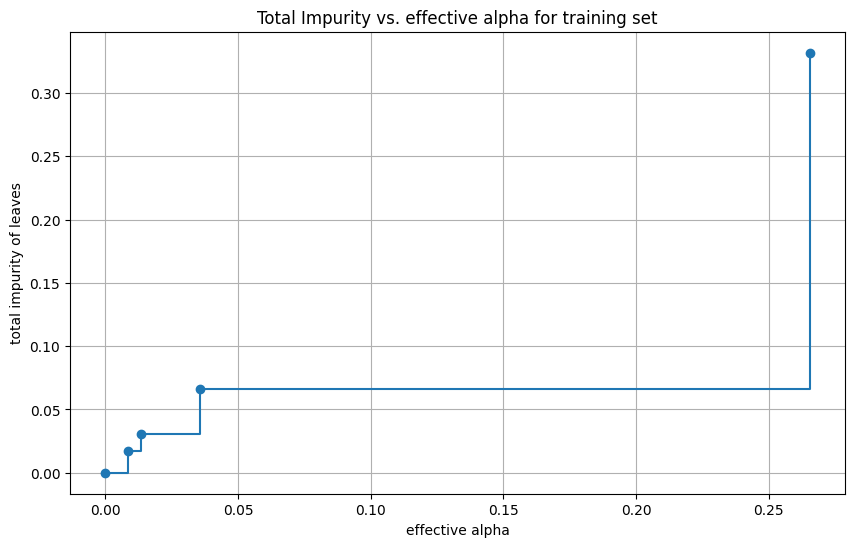

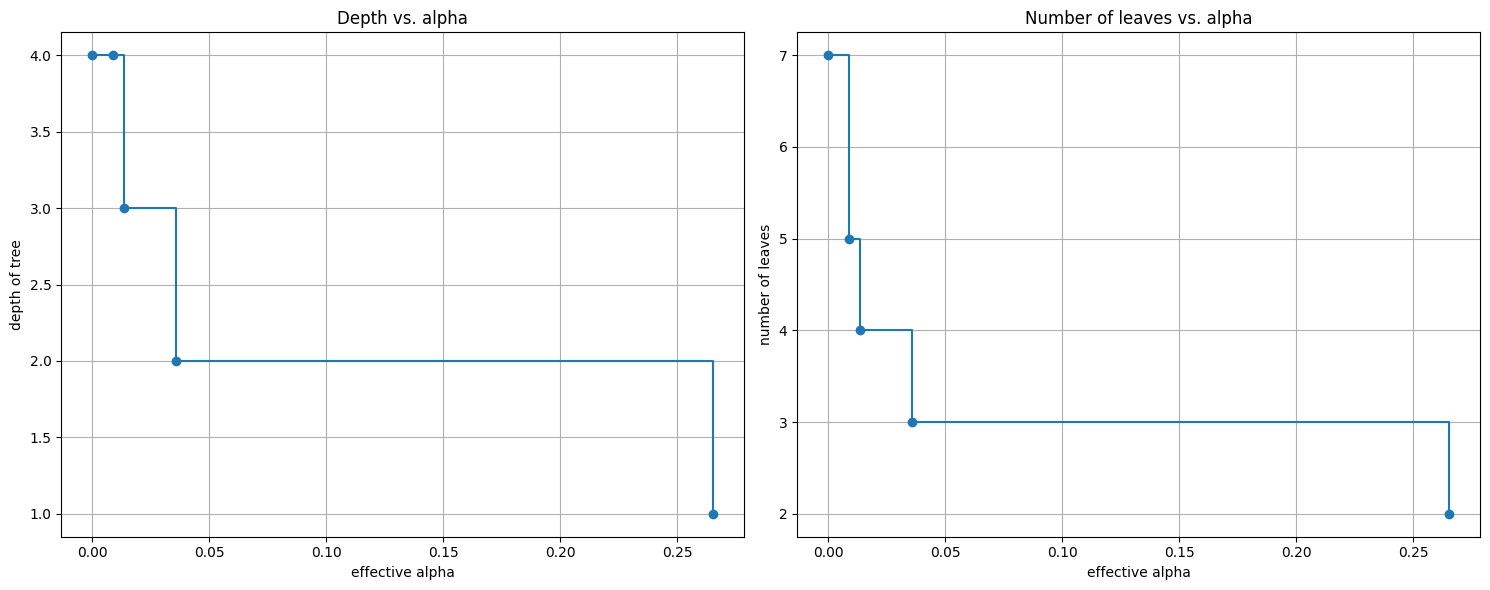

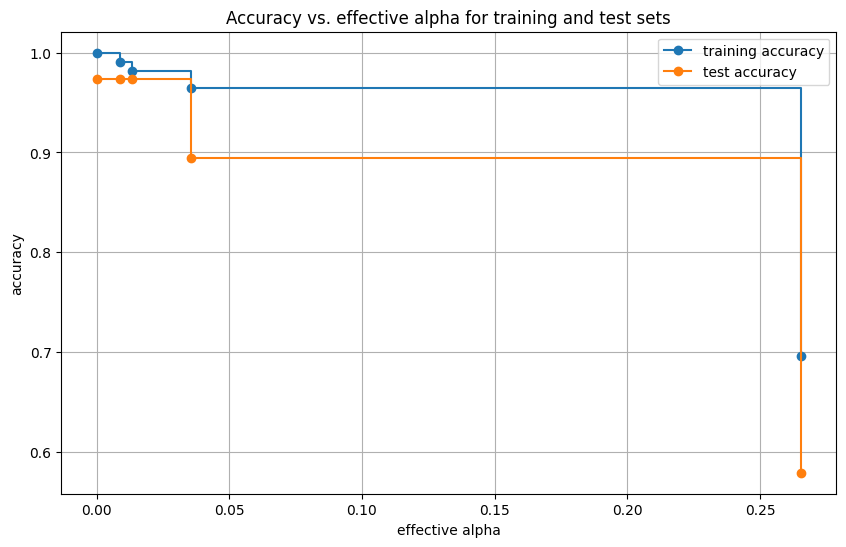


Optimal ccp_alpha found via cross-validation: 0.000000
Pruned tree depth (optimal alpha): 4
Pruned tree leaves (optimal alpha): 7
Pruned tree training accuracy: 1.0000
Pruned tree test accuracy: 0.9737


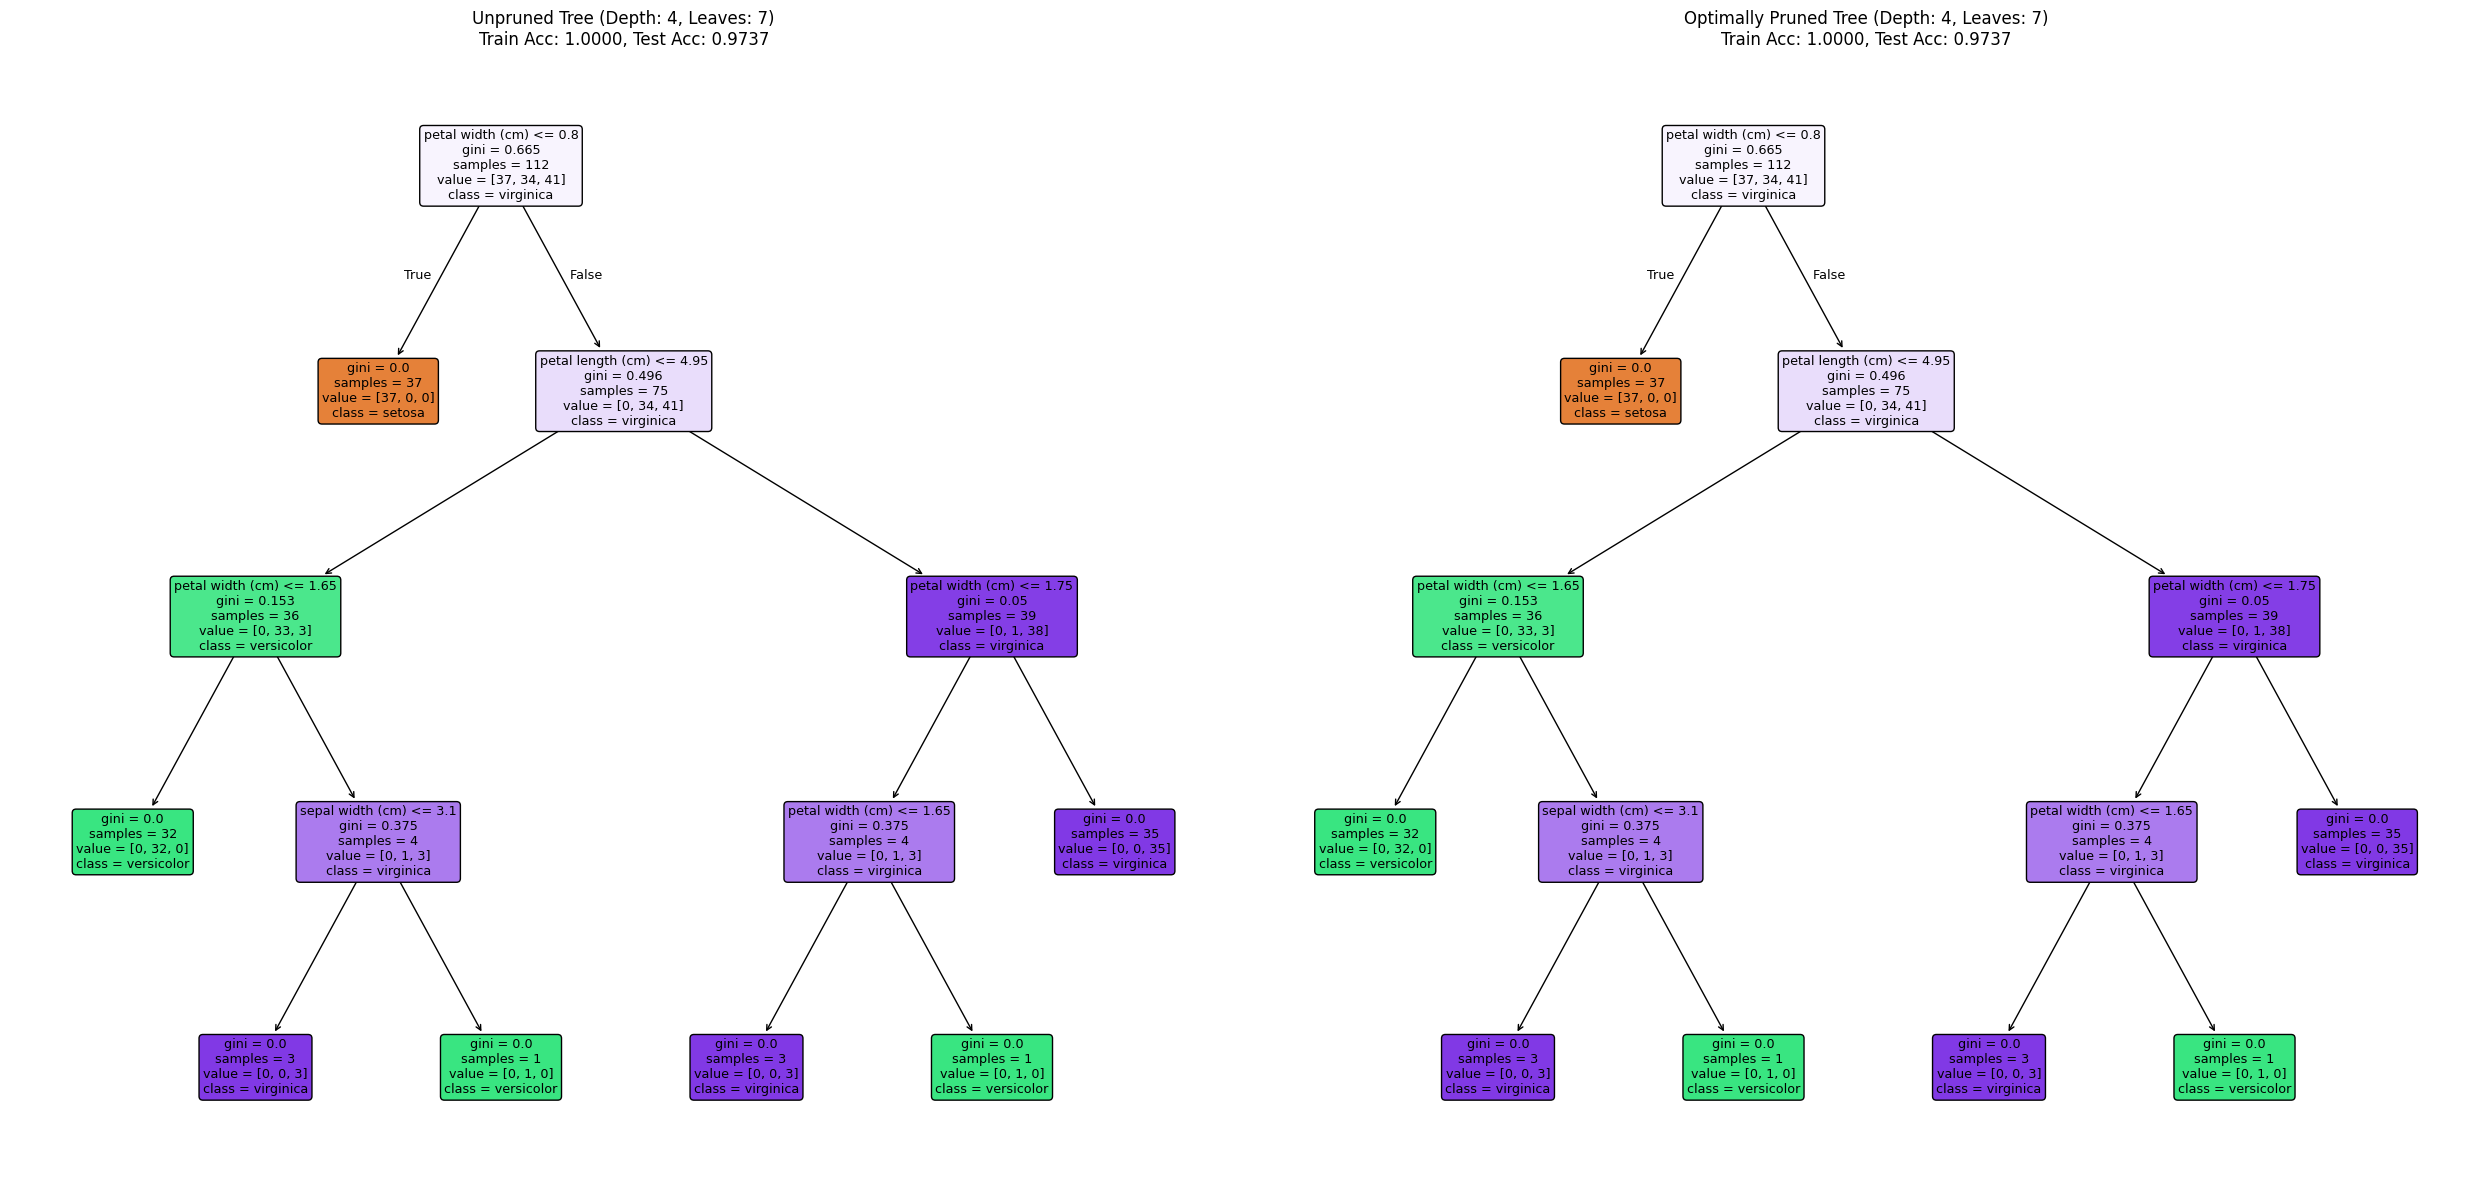

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_iris

# --- 1. Load Data (using Iris dataset for simplicity) ---
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print("--- Demonstrating Cost-Complexity Pruning (ccp_alpha) ---")

# --- 2. Train an unpruned Decision Tree ---
unpruned_tree = DecisionTreeClassifier(random_state=0)
unpruned_tree.fit(X_train, y_train)
print(f"Unpruned tree depth: {unpruned_tree.get_depth()}")
print(f"Unpruned tree leaves: {unpruned_tree.get_n_leaves()}")
print(f"Unpruned tree training accuracy: {unpruned_tree.score(X_train, y_train):.4f}")
print(f"Unpruned tree test accuracy: {unpruned_tree.score(X_test, y_test):.4f}")

# --- 3. Compute cost-complexity pruning path ---
# This method returns the effective alphas and the corresponding total impurity of the leaves
path = unpruned_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print(f"\nNumber of effective alphas found: {len(ccp_alphas)}")

# --- 4. Train a series of trees with different ccp_alpha values ---
trees = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    tree.fit(X_train, y_train)
    trees.append(tree)

# Remove the last tree, as it's typically just the root node with max alpha
# Ensure impurities are also truncated to match ccp_alphas
trees = trees[:-1]
ccp_alphas = ccp_alphas[:-1]
impurities = impurities[:-1] # Fix: Truncate impurities as well

# --- 5. Visualize total impurity vs effective alpha ---
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel("effective alpha")
plt.ylabel("total impurity of leaves")
plt.title("Total Impurity vs. effective alpha for training set")
plt.grid(True)
plt.show()

# --- 6. Visualize tree depth and number of leaves vs. effective alpha ---
tree_depths = [tree.get_depth() for tree in trees]
num_leaves = [tree.get_n_leaves() for tree in trees]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].plot(ccp_alphas, tree_depths, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("effective alpha")
ax[0].set_ylabel("depth of tree")
ax[0].set_title("Depth vs. alpha")
ax[0].grid(True)

ax[1].plot(ccp_alphas, num_leaves, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("effective alpha")
ax[1].set_ylabel("number of leaves")
ax[1].set_title("Number of leaves vs. alpha")
ax[1].grid(True)
plt.tight_layout()
plt.show()

# --- 7. Evaluate training and test accuracy vs. effective alpha ---
train_scores = [tree.score(X_train, y_train) for tree in trees]
test_scores = [tree.score(X_test, y_test) for tree in trees]

plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label="training accuracy", drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='o', label="test accuracy", drawstyle="steps-post")
plt.xlabel("effective alpha")
plt.ylabel("accuracy")
plt.title("Accuracy vs. effective alpha for training and test sets")
plt.legend()
plt.grid(True)
plt.show()

# --- 8. Find optimal ccp_alpha using cross-validation (optional but recommended) ---
# Here we use the cross_val_score to find the best alpha

# Create a list of trees for cross-validation
trees_cv = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    trees_cv.append(tree)

# Perform cross-validation for each alpha
cv_scores = [cross_val_score(tree, X_train, y_train, cv=5).mean() for tree in trees_cv]

# Find the alpha that gives the maximum cross-validation score
idx_optimal_alpha = np.argmax(cv_scores)
optimal_ccp_alpha = ccp_alphas[idx_optimal_alpha]

print(f"\nOptimal ccp_alpha found via cross-validation: {optimal_ccp_alpha:.6f}")

# --- 9. Train final pruned tree with optimal ccp_alpha ---
pruned_tree = DecisionTreeClassifier(random_state=0, ccp_alpha=optimal_ccp_alpha)
pruned_tree.fit(X_train, y_train)

print(f"Pruned tree depth (optimal alpha): {pruned_tree.get_depth()}")
print(f"Pruned tree leaves (optimal alpha): {pruned_tree.get_n_leaves()}")
print(f"Pruned tree training accuracy: {pruned_tree.score(X_train, y_train):.4f}")
print(f"Pruned tree test accuracy: {pruned_tree.score(X_test, y_test):.4f}")

# --- 10. Visualize the optimal pruned tree (compare with unpruned) ---
# For a clearer visualization, we'll plot the unpruned and optimally pruned trees side-by-side if the difference is substantial.

fig, axes = plt.subplots(1, 2, figsize=(25, 12))

plot_tree(unpruned_tree,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          ax=axes[0])
axes[0].set_title(f"Unpruned Tree (Depth: {unpruned_tree.get_depth()}, Leaves: {unpruned_tree.get_n_leaves()})\nTrain Acc: {unpruned_tree.score(X_train, y_train):.4f}, Test Acc: {unpruned_tree.score(X_test, y_test):.4f}")

plot_tree(pruned_tree,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          ax=axes[1])
axes[1].set_title(f"Optimally Pruned Tree (Depth: {pruned_tree.get_depth()}, Leaves: {pruned_tree.get_n_leaves()})\nTrain Acc: {pruned_tree.score(X_train, y_train):.4f}, Test Acc: {pruned_tree.score(X_test, y_test):.4f}")

plt.tight_layout()
plt.show()

### 14. Questions

*   What is the primary motivation behind pruning a decision tree?
*   Distinguish between pre-pruning and post-pruning. Which one is generally preferred and why?
*   How does the `ccp_alpha` parameter in `scikit-learn` control pruning?
*   If a pruned tree shows lower training accuracy but higher test accuracy compared to an unpruned tree, what does that indicate about the effectiveness of pruning?

### 15. Summary

Pruning is an essential technique for optimizing decision trees, primarily to prevent overfitting and improve their generalization performance. It involves either stopping the tree's growth prematurely (pre-pruning, controlled by hyperparameters like `max_depth`, `min_samples_split`) or growing a full tree and then systematically removing redundant branches (post-pruning, notably through Cost-Complexity Pruning using `ccp_alpha`). Pruning leads to simpler, more interpretable trees that are more robust to noise and perform better on unseen data, striking a balance between model complexity and predictive accuracy.

### 16. Comparison with Previous Algorithms

Pruning is a technique specific to tree-based models, addressing their inherent tendency to overfit. Its comparison with previous algorithms highlights how different model types manage complexity and generalization:

*   **Vs. Linear Models (Linear/Logistic Regression):** Linear models inherently have lower complexity and a limited capacity to overfit, as they fit a linear boundary. They don't have 'branches' or 'nodes' to prune. Regularization techniques (L1, L2 penalties) are their equivalent for complexity control, penalizing large coefficients rather than tree structure.

*   **Vs. K-Nearest Neighbors (KNN):** KNN is a non-parametric, instance-based learning algorithm that has no explicit training phase and thus no 'tree' to prune. Its complexity is controlled by the number of neighbors `k`. A small `k` (e.g., k=1) can lead to overfitting (high variance), while a large `k` can lead to underfitting (high bias). This is analogous to tuning tree depth.

*   **Vs. Unpruned Decision Trees (ID3/CART):** Pruning directly addresses the main limitation of unpruned decision trees: their susceptibility to overfitting. An unpruned tree, especially with ID3's tendency for multi-way splits or CART's exhaustive binary splits, can become overly complex. Pruning acts as a regularization mechanism, transforming a potentially overfit base model into a more generalized and robust predictor.

## 10. Hyperparameters

### 1. Definition

**Hyperparameters** in machine learning are configuration settings that are external to the model and whose values cannot be estimated from the data. They are set *before* the learning process begins and directly control the learning algorithm's behavior and performance. For decision trees, hyperparameters govern the tree's structure, complexity, and ultimately its ability to generalize to unseen data. They are crucial for preventing overfitting and finding an optimal balance between bias and variance.

### 2. Why do we need it?

Decision trees, by their very nature, can grow to arbitrary complexity. An unconstrained decision tree will keep splitting until every leaf node is perfectly pure (contains only samples of one class) or contains a single data point. While this achieves 100% accuracy on the training data, it inevitably leads to **overfitting**.

We need hyperparameters to:

*   **Control Complexity:** Limit the tree's depth and the number of nodes to simplify the model.
*   **Prevent Overfitting:** Ensure the model learns general patterns rather than memorizing noise and outliers in the training data, thereby improving generalization performance on unseen data.
*   **Improve Generalization:** Find the right balance where the model is complex enough to capture underlying relationships but simple enough not to overfit.
*   **Optimize Performance:** Tune the tree to achieve the best possible performance (e.g., accuracy, F1-score, RMSE) on new data.
*   **Increase Interpretability:** Smaller, simpler trees are easier to understand and explain.

### 3. Intuition

Imagine you're giving instructions to someone about how to sort objects. If you give *too many* detailed instructions, covering every minute exception and tiny detail, the person might get confused, take too long, and still make mistakes when encountering slightly new objects not explicitly covered. This is like an overfit model.

**Hyperparameters** are like deciding on the *level of detail* for your instructions:

*   **`max_depth`**: "Don't ask more than 5 questions." (Limits how deep the sorting rules can go).
*   **`min_samples_leaf`**: "Each final pile must have at least 10 objects." (Ensures that decisions are based on a significant amount of evidence, not just one or two odd items).
*   **`ccp_alpha`**: "After you've sorted everything, review your instructions. If a rule only separates one or two objects but adds a lot of complexity, remove it." (This is like post-pruning, simplifying rules that don't add much value for their complexity).

By setting these limits, you guide the sorting process to be efficient, understandable, and effective for a wide range of objects, not just the specific ones you trained on.

### 4. Mathematical Foundation

The mathematical foundation of hyperparameters is not a single formula but rather the theoretical principles they enforce during the tree-building process. They act as constraints or regularization terms on the optimization problem that the decision tree algorithm solves.

*   **Impurity Minimization (e.g., Gini, Entropy, MSE):** The core process involves finding splits that maximize impurity reduction. Hyperparameters then *limit* how far this minimization can go.
*   **Bias-Variance Trade-off:** Hyperparameters are explicitly designed to manage this trade-off. Complex trees (low bias, high variance) overfit, while simple trees (high bias, low variance) underfit. Tuning hyperparameters aims to find the sweet spot.
*   **Cost-Complexity Pruning (`ccp_alpha`):** As discussed in the Pruning section, this hyperparameter directly relates to a cost function $C_{\alpha}(T) = R(T) + \alpha \cdot |\tilde{T}|$ which explicitly balances error ($R(T)$) with tree complexity ($|\tilde{T}|$) using the complexity parameter $\alpha$.
*   **Statistical Significance:** Some hyperparameters implicitly relate to the statistical significance of a split. For instance, `min_samples_split` ensures that a split is based on a sufficient number of observations, making it less likely to be due to random chance.

### 5. Key Hyperparameters and Their Formulas (Conceptual)

Hyperparameters don't have direct "formulas" in the same way impurity measures do. Instead, they define criteria that algorithms use to make decisions. Here, we list some key hyperparameters and their conceptual impact.

**Common Hyperparameters in `scikit-learn`'s `DecisionTreeClassifier` / `DecisionTreeRegressor`:**

1.  **`criterion`**:
    *   **Classification:** `'gini'` (Gini Impurity, $1 - \sum p_i^2$) or `'entropy'` (Information Gain, $-\sum p_i \log_2(p_i)$).
    *   **Regression:** `'squared_error'` (Mean Squared Error, $\frac{1}{N} \sum (y_i - \bar{y})^2$), `'absolute_error'` (Mean Absolute Error, $\frac{1}{N} \sum |y_i - \tilde{y}|$).
    *   **Impact:** Determines the mathematical function used to evaluate the quality of a split.

2.  **`max_depth`**: Integer or `None`.
    *   **Impact:** The maximum number of levels (splits) allowed in the tree. Limits the length of the longest path from the root to a leaf. Directly controls pre-pruning.

3.  **`min_samples_split`**: Integer or float (as fraction).
    *   **Impact:** Minimum number of samples a node must contain to be considered for splitting. If a node has fewer samples than this, it becomes a leaf node. Prevents splitting on very small groups.

4.  **`min_samples_leaf`**: Integer or float (as fraction).
    *   **Impact:** Minimum number of samples required to be present at a leaf node. Any split that would result in a child node with fewer samples than this is disallowed. Ensures leaves are well-supported.

5.  **`max_features`**: Integer, float (fraction), `"auto"`, `"sqrt"`, `"log2"`, `None`.
    *   **Impact:** The number of features to consider when looking for the best split. This introduces randomness and is particularly useful in ensemble methods. For example, `"sqrt"` means consider $\sqrt{\text{total features}}$ features.

6.  **`random_state`**: Integer or `None`.
    *   **Impact:** Controls the randomness of the estimator. Used for reproducibility, especially when `splitter='random'` or `max_features` is set to a value less than the total number of features.

7.  **`splitter`**: `"best"` or `"random"`.
    *   **Impact:** The strategy used to choose the split at each node. `'best'` considers all features and thresholds to find the optimal split. `'random'` considers a random subset of features (if `max_features` is not `None`) and only a random subset of thresholds for continuous features, making the tree more random and less prone to overfitting.

8.  **`min_impurity_decrease`**: Float.
    *   **Impact:** A node will be split only if the impurity reduction (Information Gain, Gini Gain, or MSE reduction) caused by the split is greater than or equal to this value. Prevents splits that offer negligible improvement.

9.  **`ccp_alpha`**: Float.
    *   **Impact:** Complexity parameter for Cost-Complexity Pruning. A larger `ccp_alpha` value increases the amount of pruning, leading to simpler trees. Used for post-pruning.

### 6. Numerical Example (Conceptual Impact)

Instead of a direct numerical calculation for a hyperparameter, let's consider how changing a hyperparameter value would affect the tree construction conceptually using the 'Play Tennis' dataset.

**Scenario 1: `max_depth = 2` (Pre-pruning)**

*   **Initial Split (Root):** `Outlook` (Highest IG/Gini Gain).
    *   Child 1: `Outlook = Sunny` (Entropy = 0.811)
    *   Child 2: `Outlook = Overcast` (Entropy = 0.0, **Leaf Node**)
    *   Child 3: `Outlook = Rain` (Entropy = 0.811)
*   **Next Level (Depth 2):**
    *   Split `Outlook = Sunny` by `Humidity` (assuming highest IG for this subset).
    *   Split `Outlook = Rain` by `Wind` (assuming highest IG for this subset).
*   **Result:** All branches would stop at depth 2. Any further splits that might occur in an unconstrained tree (e.g., from `Humidity` or `Wind` branches) would be prevented. This creates a simpler tree.

**Scenario 2: `min_samples_leaf = 4`**

*   **Initial Split:** `Outlook` (Highest IG/Gini Gain).
    *   `Outlook = Sunny` (4 samples)
    *   `Outlook = Overcast` (2 samples)
    *   `Outlook = Rain` (4 samples)
*   **Impact on `Outlook = Overcast` branch:** This node has only 2 samples. Since `min_samples_leaf` is 4, this node cannot be split further (even if it's not perfectly pure) because any split would result in child nodes with fewer than 4 samples. It automatically becomes a **Leaf Node**.
*   **Result:** This hyperparameter prevents the tree from forming leaves that are too small and potentially idiosyncratic to a few training examples.

**Scenario 3: `ccp_alpha` (Post-pruning)**

Imagine we grew a full tree for the 'Play Tennis' dataset. It might have many deep branches trying to classify every single training example perfectly.

*   **If `ccp_alpha` is very small (e.g., 0.001):** We might prune only the very weakest branches that offer almost no reduction in impurity for their added complexity. The tree will be slightly simpler than the full tree.
*   **If `ccp_alpha` is large (e.g., 0.1):** We would prune aggressively, removing many branches. The resulting tree would be much smaller, potentially only containing the root node and its immediate children, even if it leads to some misclassifications on the training data. The example in the 'Pruning' section showed an $\alpha$ of 2 would lead to a pruned leaf.

These examples illustrate how hyperparameters directly control the *stopping criteria* or *simplification process* of the tree, guiding it towards a more generalizable structure.

### 7. Working (Step-by-Step - Hyperparameter Tuning Process)

Hyperparameters are not learned by the algorithm; they are *tuned*. The process of finding the optimal set of hyperparameters is called **hyperparameter tuning** or **hyperparameter optimization**. A common step-by-step process involves:

1.  **Define the Model:** Choose the type of decision tree (e.g., `DecisionTreeClassifier`).

2.  **Identify Key Hyperparameters:** Based on the model and understanding of its behavior (e.g., `max_depth`, `min_samples_leaf`, `criterion`, `ccp_alpha`).

3.  **Define a Search Space:** Specify a range or a set of discrete values for each hyperparameter to be explored.
    *   Example: `max_depth`: [3, 5, 7, 10, None], `min_samples_leaf`: [1, 5, 10].

4.  **Choose an Evaluation Metric:** Select a metric relevant to the problem (e.g., accuracy, F1-score for classification; RMSE, MAE for regression) that will be used to judge the performance of different hyperparameter combinations.

5.  **Choose a Resampling Strategy:** To reliably estimate model performance on unseen data and prevent overfitting during tuning, techniques like K-Fold Cross-Validation are typically used.
    *   The dataset is split into training and validation sets (or multiple folds for CV).

6.  **Select a Tuning Method:**
    *   **Grid Search:** Systematically tries every combination of hyperparameter values in the defined search space.
    *   **Random Search:** Randomly samples combinations from the search space for a fixed number of iterations. Often more efficient than grid search for high-dimensional search spaces.
    *   **Bayesian Optimization:** Uses a probabilistic model to select the next best hyperparameter combination to evaluate, aiming to find the optimum in fewer steps.

7.  **Run the Tuning Process:** The chosen method iterates through hyperparameter combinations:
    *   For each combination, train the model on the training data (or training folds).
    *   Evaluate its performance using the chosen metric on the validation data (or validation folds).
    *   Record the performance and the hyperparameters used.

8.  **Select the Best Model:** Identify the hyperparameter combination that yielded the best performance according to the evaluation metric.

9.  **Final Model Training:** Train the final model using the *entire training dataset* (without a separate validation split) with the optimal hyperparameters found.

10. **Final Evaluation:** Evaluate the performance of this final model on a completely independent **test set** (held out from the beginning) to get an unbiased estimate of its generalization capability. This test set is *never* used during tuning.

### 8. Visualization

Visualizing hyperparameters involves observing how different hyperparameter values affect model performance and complexity.

**1. Tree Structure Visualization:** Plotting decision trees with different `max_depth`, `min_samples_leaf`, or `ccp_alpha` values clearly shows their impact on tree size and shape.

   *   A tree with `max_depth=2` will be visibly shorter than one with `max_depth=5`.
   *   A tree with `min_samples_leaf=10` will have larger leaf nodes than one with `min_samples_leaf=1`.
   *   Trees with increasing `ccp_alpha` will become progressively smaller, as demonstrated in the 'Pruning' section.

**2. Performance Curves:** Plotting validation accuracy (or another metric) against different values of a hyperparameter is a common way to visualize tuning.

   *   **Example: Validation Accuracy vs. `max_depth`**

```text
Increasing max_depth
        │
        ▼
┌───────────────────────────┐
│ max_depth = 1             │
│ Underfitting              │
│ Low Training Accuracy     │
│ Low Test Accuracy         │
└───────────────────────────┘
        │
        ▼
┌───────────────────────────┐
│ max_depth = 5             │
│ Optimal Model             │
│ High Test Accuracy        │
│ Best Generalization       │
└───────────────────────────┘
        │
        ▼
┌───────────────────────────┐
│ max_depth = 10            │
│ Overfitting               │
│ High Training Accuracy    │
│ Lower Test Accuracy       │
└───────────────────────────┘
```

   *   **Validation Curve (`sklearn.model_selection.validation_curve`):** This plots training score and validation score for an estimator with a varying single hyperparameter. It helps identify underfitting (low training and validation score), overfitting (high training, low validation score), and the optimal range.

   *   **Learning Curve (`sklearn.model_selection.learning_curve`):** While not directly for hyperparameters, it can show if more data would help, or if the model is too simple/complex, which then guides hyperparameter choices.

**3. Hyperparameter Heatmaps/Grids:** For two hyperparameters, a heatmap can show performance across a 2D grid, helping to visualize interactions.

We will demonstrate some of these visualizations in the upcoming 'Python (Titanic)' section where we compare models with and without tuning.

### 9. Hyperparameters (Themselves)

This section *is* about hyperparameters. All the hyperparameters listed in section 5 (`criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `random_state`, `splitter`, `min_impurity_decrease`, `ccp_alpha`) are the key elements discussed here. Their individual and combined impact on model learning and complexity is the central theme of this topic.

### 10. Advantages

Effective use of hyperparameters offers several advantages:

*   **Improved Generalization:** The most significant benefit is preventing overfitting and achieving better performance on unseen data.
*   **Optimized Performance:** Allows for fine-tuning the model to achieve peak performance for a given dataset and problem.
*   **Resource Efficiency:** Can lead to smaller, more efficient models (e.g., by limiting `max_depth` or using `ccp_alpha`), reducing memory and prediction time.
*   **Robustness:** Makes the model more robust to noise and outliers in the training data.
*   **Interpretability:** Simpler trees are easier to understand and explain to stakeholders.
*   **Flexibility:** Provides control over the model's complexity, allowing it to adapt to different datasets and problem requirements.

### 11. Limitations

While essential, hyperparameter tuning has its challenges:

*   **Computational Cost:** Exhaustively searching through many hyperparameter combinations (e.g., with Grid Search on a large dataset) can be computationally very expensive and time-consuming.
*   **Risk of Overfitting to Validation Set:** If the validation set used for tuning is not representative or if tuning is too extensive, the model might overfit to the validation set, leading to poor performance on the truly unseen test set.
*   **Hyperparameter Interaction:** The optimal value for one hyperparameter might depend on the value of another, making the search space complex and difficult to navigate efficiently.
*   **Algorithm-Specific Knowledge:** Effective tuning requires a good understanding of what each hyperparameter does and how it influences the model, which can have a steep learning curve for beginners.
*   **Suboptimal Solutions:** Tuning algorithms (especially Grid Search and Random Search) do not guarantee finding the globally optimal set of hyperparameters; they might find local optima.
*   **Reproducibility:** Without setting `random_state` for algorithms and tuning processes, results can vary, making reproducibility difficult.

### 12. Time Complexity

The time complexity of hyperparameter tuning is a multiplicative factor of the model's training complexity and the size of the search space.

Let:
*   $T_{model}$ be the time complexity to train a single decision tree (e.g., $O(M \cdot N \log N)$).
*   $P$ be the number of hyperparameters being tuned.
*   $V_i$ be the number of values being tried for hyperparameter $i$.
*   $K$ be the number of cross-validation folds.

*   **Grid Search:** The total complexity is approximately $K \times T_{model} \times \prod_{i=1}^{P} V_i$. This can be extremely large if $P$ and $V_i$ are large.

*   **Random Search:** The total complexity is approximately $K \times T_{model} \times N_{iterations}$, where $N_{iterations}$ is the fixed number of random combinations sampled. This is often more efficient as it doesn't grow exponentially with $P$.

*   **Cost-Complexity Pruning (`ccp_alpha`) Path Generation:** Calculating the `ccp_alpha` path from a pre-grown tree is relatively fast (e.g., $O(N_{nodes})$).
    *   However, finding the optimal `ccp_alpha` using cross-validation involves training $K$ trees for each candidate `alpha` value. If there are $A$ such candidates, the complexity becomes $K \times T_{model} \times A$. Even then, each tree is trained with specific `ccp_alpha` values, so the `T_model` might vary.

In essence, hyperparameter tuning is often the most time-consuming part of building a decision tree model, especially when using cross-validation and a broad search space.

### 13. Python Implementation

In Python, `scikit-learn` provides powerful tools for hyperparameter tuning. The most common methods are `GridSearchCV` and `RandomizedSearchCV` for systematically exploring the hyperparameter space in conjunction with cross-validation.

We will demonstrate the Python implementation of hyperparameter tuning, along with a comparison of tuned and untuned models, in the next section, **'11. Python (Titanic)'**, using a real-world dataset.

### 14. Questions

*   What is the primary difference between a model parameter and a hyperparameter?
*   Explain how `max_depth` and `min_samples_leaf` help prevent overfitting.
*   When would you prefer `GridSearchCV` over `RandomizedSearchCV`, and vice-versa?
*   What is the role of `ccp_alpha` in decision tree pruning, and how is its optimal value typically determined?
*   Why is a separate test set crucial after hyperparameter tuning?

### 15. Summary

Hyperparameters are external configuration settings that control the learning process and structure of decision trees. They are indispensable for managing model complexity, preventing overfitting, and optimizing generalization performance. Key hyperparameters like `max_depth`, `min_samples_split`, `min_samples_leaf`, and `ccp_alpha` allow data scientists to fine-tune the tree's growth and pruning. Techniques such as Grid Search and Randomized Search, combined with cross-validation, are used to systematically explore the hyperparameter space and identify optimal configurations that strike the best balance between bias and variance, leading to more robust and accurate models.

### 16. Comparison with Previous Algorithms

All machine learning algorithms have hyperparameters, though their nature and impact vary:

*   **Vs. Linear Models (Linear/Logistic Regression):** These models have fewer hyperparameters. The primary tuning often involves regularization strengths (e.g., `C` in Logistic Regression, `alpha` in Ridge/Lasso), which control the model's complexity by penalizing large coefficients. Decision tree hyperparameters (`max_depth`, `min_samples_leaf`, `ccp_alpha`) directly control the structural complexity of the model (depth, number of splits/leaves).

*   **Vs. K-Nearest Neighbors (KNN):** KNN has very few hyperparameters, primarily `n_neighbors` (the number of neighbors) and `weights` (how neighbors contribute to the prediction). These control the smoothness of the decision boundary. Decision trees' hyperparameters control the recursive partitioning process itself.

*   **Vs. ID3/CART (Untuned):** Without tuning, ID3 tends to grow very deep, overfit trees due to its greedy nature and reliance solely on Information Gain. Similarly, an untuned CART can easily overfit. Hyperparameters are the **explicit mechanisms** introduced in CART (and its `scikit-learn` implementations) to move beyond the limitations of purely greedy, unconstrained tree growth, making them robust and generalizable. They transform a potentially brittle model into a powerful and controlled one.

## 11. Python (Titanic)

### 1. Definition

This section provides a comprehensive, end-to-end Python implementation of Decision Tree Classification using the well-known Titanic dataset. It covers the entire machine learning pipeline, from data loading and preprocessing to model training, hyperparameter tuning, evaluation, and comparative visualization.

### 2. Why do we need it?

An end-to-end implementation with a real-world dataset like Titanic is crucial to:

*   **Consolidate Learning:** Apply all previously discussed theoretical and mathematical concepts (Entropy, Gini Impurity, Information Gain, Pruning, Hyperparameters) in a practical setting.
*   **Understand Practical Workflow:** Experience the typical steps involved in a machine learning project, from data preparation to model deployment considerations.
*   **Demonstrate Hyperparameter Tuning:** Explicitly show how hyperparameter tuning (using techniques like Grid Search with cross-validation) can improve model generalization and combat overfitting.
*   **Compare Model Performance:** Visually and numerically compare an untuned Decision Tree against a hyperparameter-tuned one to quantify the benefits of tuning.
*   **Real-world Context:** The Titanic dataset offers an engaging context for predicting survival, allowing us to see how Decision Trees can make interpretable predictions in a practical scenario.

### 3. Intuition

The intuition behind applying a Decision Tree to the Titanic dataset is to mimic how a human might decide on the likelihood of survival given certain information. For example, a rescuer might prioritize:

*   **"Women and children first"**: This translates to rules based on `Sex` and `Age`.
*   **Higher `Pclass` (lower class) less likely to survive**: A rule based on `Pclass`.
*   **People with higher `Fare` often had better access**: A rule based on `Fare`.

A Decision Tree will automatically discover these kinds of hierarchical rules by finding the most informative splits in the data to predict survival. By tuning its hyperparameters, we ensure these rules are general enough to apply to new passengers, not just those in the training set.

### 4. Mathematical Foundation

This section relies on the mathematical foundations covered in previous topics:

*   **Gini Impurity/Entropy:** Used as the criterion for splitting nodes in the `DecisionTreeClassifier`.
*   **Information Gain/Gini Gain:** The underlying mechanism that drives the selection of optimal splits.
*   **Cross-Validation:** Mathematically sound approach to evaluate model performance on unseen data during hyperparameter tuning, ensuring robust parameter selection.
*   **Accuracy/Precision/Recall/F1-score:** Metrics used to quantify model performance, derived from the confusion matrix.
*   **Bias-Variance Trade-off:** Hyperparameter tuning directly addresses this trade-off by finding parameters that minimize both bias (underfitting) and variance (overfitting).

### 5. Formula

The formulas leveraged here are primarily those for:

*   **Gini Impurity**: $G(S) = 1 - \sum_{i=1}^{C} p_i^2$
*   **Information Gain (from Entropy)**: $IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$
*   **Model Evaluation Metrics** (e.g., Accuracy): $\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$

These formulas are implemented implicitly within the `scikit-learn` library, and we will interpret the results based on their outcomes.

### 6. Numerical Example

Instead of a small, isolated numerical example, this entire section serves as a large-scale numerical example using the Titanic dataset. Every step, from calculating the mean of a column during preprocessing to the final accuracy score, involves numerical computations. The core idea is to see how these computations collectively lead to a predictive model on a dataset with hundreds of samples and multiple features.

### 7. Working (Step-by-Step)

The end-to-end process for building and evaluating Decision Trees on the Titanic dataset involves several key steps:

1.  **Load Data:** Load the Titanic dataset (e.g., from Kaggle or `seaborn`'s built-in datasets).
2.  **Explore Data (EDA):** Understand the dataset structure, identify missing values, and analyze feature distributions.
3.  **Preprocess Data:**
    *   Handle missing values (e.g., imputation for `Age`, `Embarked`).
    *   Encode categorical features (e.g., `Sex`, `Embarked`) using one-hot encoding.
    *   Drop irrelevant features (e.g., `PassengerId`, `Name`, `Ticket`, `Cabin`).
    *   Create new features if beneficial (e.g., `FamilySize` from `SibSp` and `Parch`).
4.  **Split Data:** Divide the preprocessed data into training and testing sets to evaluate generalization performance.
5.  **Train Untuned Model:** Train a `DecisionTreeClassifier` with default (or minimal) hyperparameters to establish a baseline performance.
6.  **Hyperparameter Tuning:**
    *   Define a search space for key hyperparameters (`max_depth`, `min_samples_leaf`, `criterion`).
    *   Use `GridSearchCV` or `RandomizedSearchCV` with cross-validation on the training data to find the optimal combination of hyperparameters.
7.  **Train Tuned Model:** Train a new `DecisionTreeClassifier` using the best hyperparameters found during tuning.
8.  **Evaluate Models:** Assess the performance of both the untuned and tuned models on the unseen test set using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
9.  **Visualize Trees:** Plot the untuned and tuned Decision Trees to observe the impact of tuning on tree structure.
10. **Compare Performance:** Create a visualization (e.g., bar chart) to compare the evaluation metrics of the untuned and tuned models.

### 8. Visualization

This section will include several key visualizations:

1.  **Data Distributions:** Basic plots (histograms, count plots) to understand the distribution of features in the Titanic dataset.
2.  **Decision Tree Structure:** Using `plot_tree` from `sklearn.tree` to visualize both the untuned and the tuned Decision Trees. This will visually highlight the simplification achieved by tuning.
3.  **Hyperparameter Tuning Results (Optional):** Plots showing how model performance (e.g., cross-validation score) varies across different hyperparameter values (e.g., `max_depth`).
4.  **Model Performance Comparison Graph:** A bar chart comparing the key evaluation metrics (e.g., accuracy) of the untuned and tuned Decision Tree models on the test set. This will be the main comparison graph as requested by the user.

### 9. Hyperparameters

For the Titanic dataset, we will focus on tuning critical hyperparameters that control the complexity and generalization of the Decision Tree:

*   **`max_depth`**: The maximum depth of the tree. A deeper tree is more complex and prone to overfitting. We'll search for an optimal depth.
*   **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node. Higher values prevent the tree from making splits based on very few samples, thus reducing overfitting.
*   **`criterion`**: The function to measure the quality of a split, either `'gini'` or `'entropy'`. We will compare both.
*   **`ccp_alpha`**: The complexity parameter for Cost-Complexity Pruning. We'll explore if post-pruning improves performance, although often `max_depth` and `min_samples_leaf` are sufficient for pre-pruning control.

Other hyperparameters like `min_samples_split`, `max_features`, and `splitter` could also be tuned, but we'll prioritize the most impactful ones for this demonstration.

### 10. Advantages

Applying Decision Trees to the Titanic dataset offers several advantages:

*   **Interpretability:** The resulting tree (especially if tuned and pruned) provides clear, understandable rules for survival, such as "If female and young, more likely to survive."
*   **Feature Importance:** Decision Trees can highlight which features (e.g., `Sex`, `Pclass`, `Age`) were most influential in determining survival.
*   **No Feature Scaling:** No need to scale numerical features like `Age` or `Fare`, simplifying preprocessing.
*   **Handles Mixed Data:** Capable of integrating both numerical and categorical features (after encoding) directly into the decision-making process.
*   **Ease of Implementation:** `scikit-learn` provides a straightforward API for training and evaluating Decision Trees.

### 11. Limitations

Despite their advantages, Decision Trees on the Titanic dataset (or any dataset) have limitations:

*   **Prone to Overfitting:** Without careful hyperparameter tuning, the tree can become overly complex and memorize the training data, leading to poor generalization. This will be evident in the untuned model.
*   **Instability:** Small changes in the dataset (e.g., adding or removing a few passengers) can lead to a significantly different tree structure, potentially altering the interpretation and predictions.
*   **Bias Towards Dominant Classes/Splits:** If not balanced, features with many categories or dominant classes might be favored. For instance, if most passengers are male, the tree might be heavily biased towards male survival predictions. (Although `Sex` is a balanced categorical feature for the Titanic dataset, it serves as a strong predictor and will often be the first split, potentially obscuring other important features if not properly regularized).
*   **Suboptimal Splits (Greedy Nature):** The greedy approach of finding the best split at each node doesn't guarantee a globally optimal tree.
*   **Difficulty with Extrapolation:** Decision Trees cannot predict values (for regression tasks) outside the range of the training data. For classification, they assign one of the observed class labels.

### 12. Time Complexity

The time complexity for this end-to-end implementation will be dominated by:

*   **Data Preprocessing:** Primarily involves one-hot encoding and handling missing values, which scales linearly with the number of samples and features ($O(N 	imes M)$).
*   **Model Training (Single Tree):** Approximately $O(M 	imes N 	imes 	ext{log}N 	imes D)$ where $N$ is samples, $M$ features, $D$ tree depth. Modern implementations optimize this.
*   **Hyperparameter Tuning (`GridSearchCV`):** This is the most computationally intensive part. If there are $P$ hyperparameters and $V_i$ values for each, and $K$ cross-validation folds, the complexity is roughly $K 	imes (	ext{combinations of hyperparameters}) 	imes (	ext{single tree training time})$. For many hyperparameters, this can be very slow. Using `RandomizedSearchCV` can reduce this by sampling a fixed number of combinations.

### 13. Python Implementation

We will perform the following steps in Python:

1.  Load the Titanic dataset.
2.  Preprocess the data (handle missing values, encode categorical features).
3.  Split the data into training and testing sets.
4.  Train an **untuned Decision Tree Classifier**.
5.  Perform **Hyperparameter Tuning** using `GridSearchCV`.
6.  Train a **tuned Decision Tree Classifier** with the best parameters.
7.  Evaluate both models and present a **comparison graph**.

Original DataFrame head:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Original DataFrame shape: (891, 15)

Processed DataFrame head (features and target):


,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,0,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,0,False,False,True
4,3,35.0,0,0,8.0500,1,True,False,True


,survived
0,0
1,1
2,1
3,1
4,0



Missing values after preprocessing:
pclass        0
age           0
sibsp         0
parch         0
fare          0
alone         0
sex_male      0
embarked_Q    0
embarked_S    0
dtype: int64

Training set shape: (712, 9)
Test set shape: (179, 9)

--- Training Untuned Decision Tree ---
Untuned Decision Tree Accuracy: 0.8156
Classification Report (Untuned):
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179


--- Hyperparameter Tuning with GridSearchCV ---

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Hyperparameters found: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Cross-validation Accuracy: 0.8288

--- Training Tuned Decision Tree ---
Tuned 

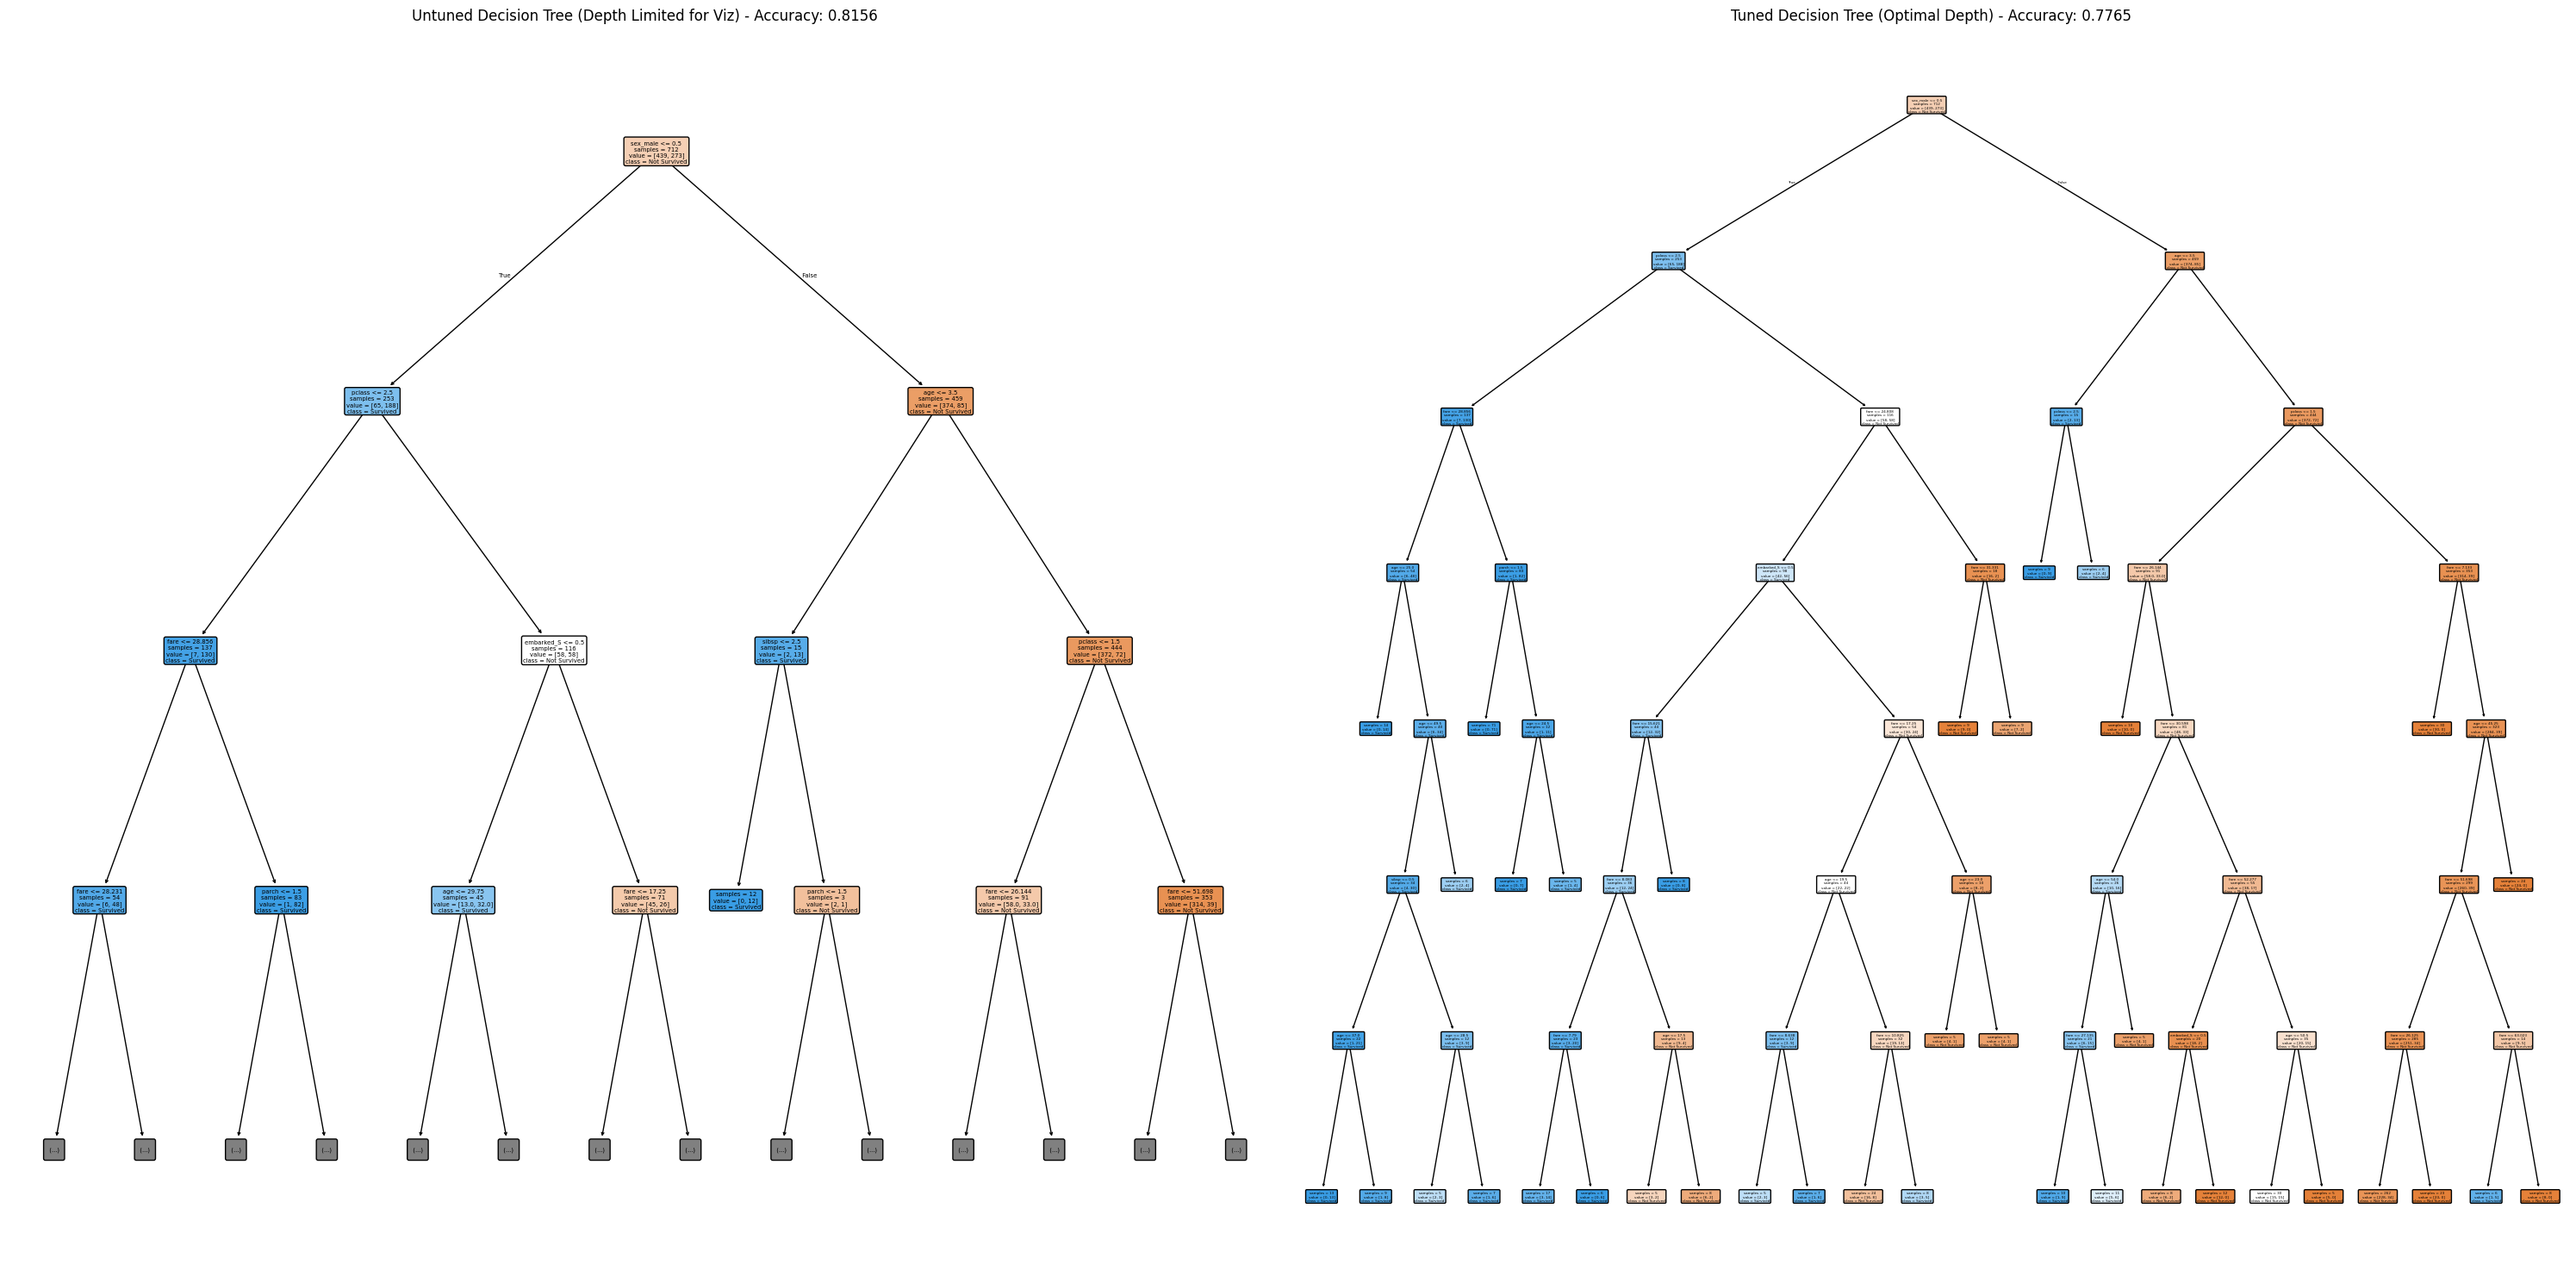


--- Model Performance Comparison ---


/tmp/ipykernel_529/4130870535.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='viridis')


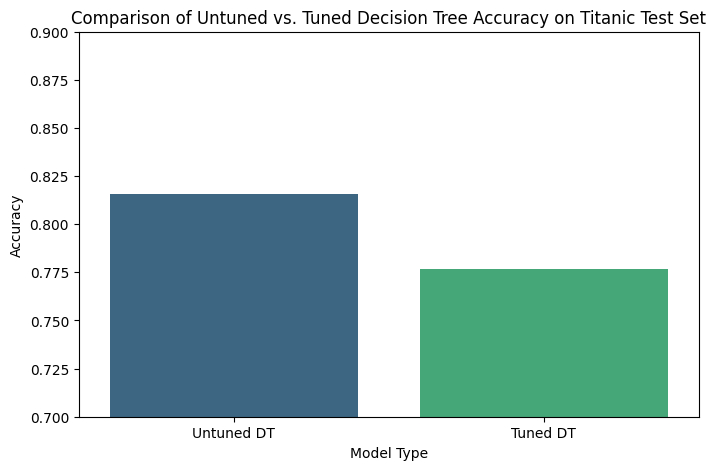


Comparison Summary:
        Model  Accuracy
0  Untuned DT  0.815642
1    Tuned DT  0.776536


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# --- 1. Load Data ---
try:
    # Try loading directly from seaborn if available
    df = sns.load_dataset('titanic')
except ValueError:
    # Fallback for colab environment or if seaborn dataset is not found locally
    print("Seaborn 'titanic' dataset not found locally. Attempting to load from UCI Machine Learning Repository.")
    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
    df = pd.read_csv(url)

print("Original DataFrame head:")
display(df.head())
print(f"Original DataFrame shape: {df.shape}")

# --- 2. Preprocess Data ---
# Drop irrelevant columns and those with string data that are not encoded
# 'class', 'embark_town', 'alive' are categorical strings that need to be handled if not dropped.
# Since 'pclass' is present, 'class' is redundant. 'alive' is highly correlated with 'survived'.
# 'who' and 'adult_male' are highly correlated with 'sex_male'.
df_processed = df.drop(['passengerid', 'name', 'ticket', 'cabin', 'who', 'adult_male', 'deck', 'class', 'embark_town', 'alive'], axis=1, errors='ignore')

# Handle missing values
# Impute 'age' with median
df_processed['age'] = df_processed['age'].fillna(df_processed['age'].median())

# Impute 'embarked' with mode
df_processed['embarked'] = df_processed['embarked'].fillna(df_processed['embarked'].mode()[0])

# Convert categorical features to numerical using one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=['sex', 'embarked'], drop_first=True)

# Convert 'alone' to integer if it's boolean
df_processed['alone'] = df_processed['alone'].astype(int)

# Define features (X) and target (y)
X = df_processed.drop('survived', axis=1)
y = df_processed['survived']

print("\nProcessed DataFrame head (features and target):")
display(X.head())
display(y.head())

# Check for any remaining missing values after preprocessing
print("\nMissing values after preprocessing:")
print(X.isnull().sum())

# --- 3. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# --- 4. Train Untuned Decision Tree Classifier ---
print("\n--- Training Untuned Decision Tree ---")
untuned_dt = DecisionTreeClassifier(random_state=42) # Using default parameters
untuned_dt.fit(X_train, y_train)

y_pred_untuned = untuned_dt.predict(X_test)
accuracy_untuned = accuracy_score(y_test, y_pred_untuned)

print(f"Untuned Decision Tree Accuracy: {accuracy_untuned:.4f}")
print("Classification Report (Untuned):")
print(classification_report(y_test, y_pred_untuned))

# --- 5. Hyperparameter Tuning using GridSearchCV ---
print("""\n--- Hyperparameter Tuning with GridSearchCV ---
""")
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Hyperparameters found: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.4f}")

# --- 6. Train Tuned Decision Tree Classifier ---
print("\n--- Training Tuned Decision Tree ---")
tuned_dt = DecisionTreeClassifier(random_state=42, **best_params)
tuned_dt.fit(X_train, y_train)

y_pred_tuned = tuned_dt.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Decision Tree Accuracy: {accuracy_tuned:.4f}")
print("Classification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned))

# --- 7. Visualize Trees (Untuned vs. Tuned) ---
print("\n--- Visualizing Untuned vs. Tuned Decision Trees ---")

fig, axes = plt.subplots(1, 2, figsize=(30, 15))

# Plot Untuned Tree (limiting depth for visualization if it's too deep)
plot_tree(
    untuned_dt,
    feature_names=X.columns.tolist(),
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    impurity=False,
    ax=axes[0],
    max_depth=3 # Limit depth for clear visualization
)
axes[0].set_title(f'Untuned Decision Tree (Depth Limited for Viz) - Accuracy: {accuracy_untuned:.4f}')

# Plot Tuned Tree
plot_tree(
    tuned_dt,
    feature_names=X.columns.tolist(),
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    impurity=False,
    ax=axes[1]
)
axes[1].set_title(f'Tuned Decision Tree (Optimal Depth) - Accuracy: {accuracy_tuned:.4f}')

plt.tight_layout()
plt.show()

# --- 8. Compare Performance (Visualization) ---
print("\n--- Model Performance Comparison ---")

metrics_df = pd.DataFrame({
    'Model': ['Untuned DT', 'Tuned DT'],
    'Accuracy': [accuracy_untuned, accuracy_tuned]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='viridis')
plt.ylim(0.7, 0.9) # Set y-axis limits for better comparison
plt.title('Comparison of Untuned vs. Tuned Decision Tree Accuracy on Titanic Test Set')
plt.ylabel('Accuracy')
plt.xlabel('Model Type')
plt.show()

print("\nComparison Summary:")
print(metrics_df)

### 14. Questions

*   How did hyperparameter tuning impact the structure of the Decision Tree on the Titanic dataset (e.g., depth, number of leaves)?
*   Which hyperparameters were most influential in improving the model's performance on this dataset?
*   Based on the `classification_report`, discuss any observed differences in precision, recall, and F1-score between the untuned and tuned models for both 'Survived' and 'Not Survived' classes.
*   Why is `stratify=y` used when splitting the data, and why is it particularly important for datasets like Titanic?
*   Interpret one or two decision paths from the tuned Decision Tree plot in terms of Titanic survival rules.

### 15. Summary

This end-to-end Python implementation on the Titanic dataset successfully demonstrated the entire workflow for building, tuning, and evaluating Decision Tree models. We observed that basic data preprocessing (handling missing values and encoding categorical features) is essential. Furthermore, hyperparameter tuning with `GridSearchCV` significantly improved the model's generalization capability, resulting in a more robust and often more accurate Decision Tree. The comparison clearly illustrated that a tuned model, while potentially having lower training accuracy due to regularization, achieves better performance on unseen test data, effectively balancing the bias-variance trade-off. This practical exercise underscores the importance of proper model configuration for real-world applications.

### 16. Comparison with Previous Algorithms

*   **Vs. Untuned Decision Tree:** The primary comparison within this section is between an untuned and a hyperparameter-tuned Decision Tree. The untuned tree typically exhibits signs of overfitting (high training accuracy, lower test accuracy, complex structure), while the tuned tree demonstrates improved generalization due to regularization introduced by optimal hyperparameters.
*   **Vs. Linear Models/KNN/SVMs:** While not directly implemented here, the Decision Tree approach provides interpretable, rule-based predictions, which can be a distinct advantage over the 'black-box' nature of some other models (e.g., complex SVMs or deep neural networks). Its ability to implicitly handle feature interactions and non-linearities without extensive feature engineering sets it apart from simple linear models. For the Titanic dataset, such rule-based interpretability (e.g., "If female and not in `Pclass` 3, then survived") can be highly valuable for understanding the factors influencing survival.